# 사용자 가입 분석 (Acquisition)

- 중·고등학생을 주요 타깃으로 하는 서비스의 특성상, 활성화(`Activation`)와 리텐션(`Retention`)이 양호하더라도 **진급 및 졸업에 따른 구조적인 사용자 이탈**이 불가피합니다.

- 따라서 자연 이탈로 인한 사용자 감소를 상쇄하고 지속적인 성장을 이어가기 위해서는 **안정적인 신규 사용자 획득(`Acquisition`)**이 중요한 과제라고 판단했습니다.

- 본 분석에서는 **신규 사용자의 가입 시점, 특성, 지역 및 가입 패턴 등을 다양한 관점에서 탐색**하고, 이를 바탕으로 **향후 사용자 획득 단계에서 어떤 부분에 집중할 필요가 있는지 파악하는 것**을 목표로 합니다.

## 0. 라이브러리 호출 및 환경 세팅

### 0-1. 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

### 0-2. 시각화 공통 환경 세팅

In [2]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

### 0-3. 함수 정의

In [3]:
def plot_monthly_signups(data, title):
    data = data.sort_values('signup_month').copy()
    data['monthly_change'] = data['unique_users'].diff()

    fig, ax = plt.subplots(figsize=(16, 6))

    # 라인그래프 생성
    sns.lineplot(
        data=data,
        x='signup_month',
        y='unique_users',
        marker='o',
        linewidth=2.5,
        color='#3182bd',
        ax=ax,
    )

    # 표시된 월별 가입자 수의 중앙값
    median_users = data['unique_users'].median()
    ax.axhline(
        y=median_users,
        color='darkorange',
        linestyle='--',
        linewidth=1.5,
        label=f'중앙값: {median_users:,.0f}명',
    )
    ax.legend(loc='upper right')

    # 각 데이터 포인트에 숫자 레이블 표시
    for row in data.itertuples(index=False):
        x, y, change = (
            row.signup_month,
            row.unique_users,
            row.monthly_change,
        )
        # 중앙값 이상인 월의 가입자 수 강조
        is_above_median = y >= median_users
        ax.annotate(
            f'{int(y):,}명',
            (x, y),
            xytext=(0, 23),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            fontweight='bold' if is_above_median else 'normal',
            bbox=(
                dict(
                    boxstyle='round,pad=0.25',
                    facecolor='#FFF3CD',
                    edgecolor='darkorange',
                    linewidth=0.8,
                )
                if is_above_median else None
            ),
        )

        # 전월 대비 증감량
        if pd.isna(change):
            label, color = '비교 없음', 'gray'
        elif change > 0:
            label, color = f'+{int(change):,}명', 'red'
        elif change < 0:
            label, color = f'{int(change):,}명', 'blue'
        else:
            label, color = '0명', 'gray'

        ax.annotate(
            label,
            (x, y),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color,
        )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입 월', fontsize=11)
    ax.set_ylabel('가입 유저 수(명)', fontsize=11)

    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylim(0, data['unique_users'].max() * 1.25)

    fig.tight_layout()
    plt.show()

In [4]:
def plot_area_signups(data, label_col, title):
    fig, ax = plt.subplots(
        figsize=(12, max(5, len(data) * 0.4))
    )

    bars = ax.barh(
        data[label_col],
        data['가입자 수'],
        color='#3182bd',
    )

    ax.bar_label(
        bars,
        labels=[
            f'{count:,.0f}명 ({share:.2f}%)'
            for count, share in zip(data['가입자 수'], data['비중(%)'])
        ],
        padding=5,
        fontsize=9,
    )

    ax.invert_yaxis()
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel('가입자 수(명)')
    ax.set_ylabel('')
    ax.set_xlim(0, data['가입자 수'].max() * 1.35)

    fig.tight_layout()
    plt.show()


In [5]:
def summarize_group_burst(group, window_hours=24):
    times = group['signup_date'].sort_values().reset_index(drop=True)
    window = pd.Timedelta(hours=window_hours)
    right = 0
    best_left = 0
    best_count = 0

    for left in range(len(times)):
        while right < len(times) and times.iloc[right] < times.iloc[left] + window:
            right += 1
        count = right - left
        if count > best_count:
            best_left = left
            best_count = count

    start = times.iloc[best_left]
    return {
        '가입자 수': len(times),
        '최대 구간 가입자 수': best_count,
        '가입 집중도(%)': best_count / len(times) * 100,
        '집중 구간 시작': start,
        '집중 구간 종료(미포함)': start + window,
        '그룹 최초 가입': times.iloc[0],
        '그룹 최종 가입': times.iloc[-1],
    }

In [6]:
def analyze_signup_bursts(data, entity_col, min_users, window_hours):
    # 1. 필요한 컬럼 선택 및 결측·중복 정리
    signups = (
        data[['user_id', entity_col, 'signup_date']]
        .dropna(subset=['user_id', entity_col, 'signup_date'])
        .sort_values('signup_date')
        .drop_duplicates([entity_col, 'user_id'], keep='first')
        .copy()
    )

    # 시간 변환 없이 기존 datetime 사용
    if not pd.api.types.is_datetime64_any_dtype(signups['signup_date'].dtype):
        raise TypeError('signup_date가 datetime 형식인지 확인해 주세요.')

    # 2. 최소 인원 이상인 집단만 선택
    sizes = signups.groupby(entity_col)['user_id'].nunique()
    eligible_ids = sizes[sizes >= min_users].index

    eligible_signups = signups[
        signups[entity_col].isin(eligible_ids)
    ]

    # 3. 기존 함수를 각 집단에 적용
    records = []

    for entity_id, members in eligible_signups.groupby(entity_col):
        records.append({
            entity_col: entity_id,
            **summarize_group_burst(
                members,
                window_hours=window_hours,
            ),
        })

    # 4. 결과표 생성
    columns = [
        entity_col,
        '가입자 수',
        '최대 구간 가입자 수',
        '가입 집중도(%)',
        '집중 구간 시작',
        '집중 구간 종료(미포함)',
        '그룹 최초 가입',
        '그룹 최종 가입',
    ]

    summary = (
        pd.DataFrame(records, columns=columns)
        .rename(columns={
            '그룹 최초 가입': '최초 가입',
            '그룹 최종 가입': '최종 가입',
        })
        .sort_values(
            ['가입 집중도(%)', '최대 구간 가입자 수'],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    coverage = pd.DataFrame({
        '구분': ['전체 유효 집단', '분석 대상 집단', '최소 인원 미달 집단'],
        '집단 수': [
            len(sizes),
            len(eligible_ids),
            len(sizes) - len(eligible_ids),
        ],
    })

    return summary, coverage

In [7]:
def summarize_burst_distribution(
    data,
    entity_label='학교',
    window_hours=72,
):
    labels = [
        f'{start}~{start + 10}% 미만'
        for start in range(0, 90, 10)
    ] + ['90~100%']

    count_col = f'{entity_label} 수'
    share_col = f'{entity_label} 비중(%)'

    distribution = (
        pd.cut(
            data['가입 집중도(%)'],
            bins=list(range(0, 100, 10)) + [float('inf')],
            labels=labels,
            right=False,
        )
        .value_counts(sort=False)
        .rename_axis(f'{window_hours}시간 가입 집중도 구간')
        .reset_index(name=count_col)
    )

    distribution[share_col] = (
        (distribution[count_col] / len(data) * 100).round(2)
        if len(data) else float('nan')
    )

    return distribution

### 0-4. 데이터 호출

In [8]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [9]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

   user_id                      signup_date  group_id  grade  school_id  \
0   854579 2023-04-29 14:58:10.258013+00:00      5384      1       5635   
1   860264 2023-04-30 13:57:44.499021+00:00      6687      1       5257   
2   860491 2023-04-30 14:12:42.390512+00:00      2842      1       2588   
3   877440 2023-05-03 14:51:51.083512+00:00      2658      1       2599   
4   949655 2023-05-07 07:22:57.503677+00:00     18574      1       4496   

       address school_type  
0      경기도 가평군           H  
1  경기도 성남시 분당구           H  
2    서울특별시 강남구           H  
3    서울특별시 강남구           H  
4      경기도 화성시           H  


In [10]:
# 데이터 규모
print(f'분석 데이터 규모 {df.shape}')
print(df['user_id'].nunique())

분석 데이터 규모 (676984, 7)
676984


## 1. 월별 가입자 추이 분석

- **분석 대상:** 전체 가입자 676,984명

- 전체 사용자의 **가입 일시를 기준으로 월별 신규 가입자 수의 추이와 변화 패턴**을 확인합니다.

In [11]:
# datetime 변환 후 YYYY-MM 포맷으로 추출
df['signup_month'] = pd.to_datetime(df['signup_date']).dt.strftime('%Y-%m')

# 연월별 유니크 가입자 수 집계
monthly_summary = df.groupby(by='signup_month')['user_id'].nunique().reset_index(name='unique_users')
# 실제 전월과 비교하도록 누락된 월도 포함하고 시간순으로 정렬
monthly_summary = (
    monthly_summary.set_index('signup_month')
    .reindex(
        pd.period_range(
            monthly_summary['signup_month'].min(),
            monthly_summary['signup_month'].max(),
            freq='M',
        ).astype(str),
        fill_value=0,
    )
    .rename_axis('signup_month')
    .reset_index()
)

print(monthly_summary.head())

  signup_month  unique_users
0      2023-03            22
1      2023-04         19030
2      2023-05        635478
3      2023-06         16732
4      2023-07          1832


findfont: Failed to find font weight bold, now using 400.


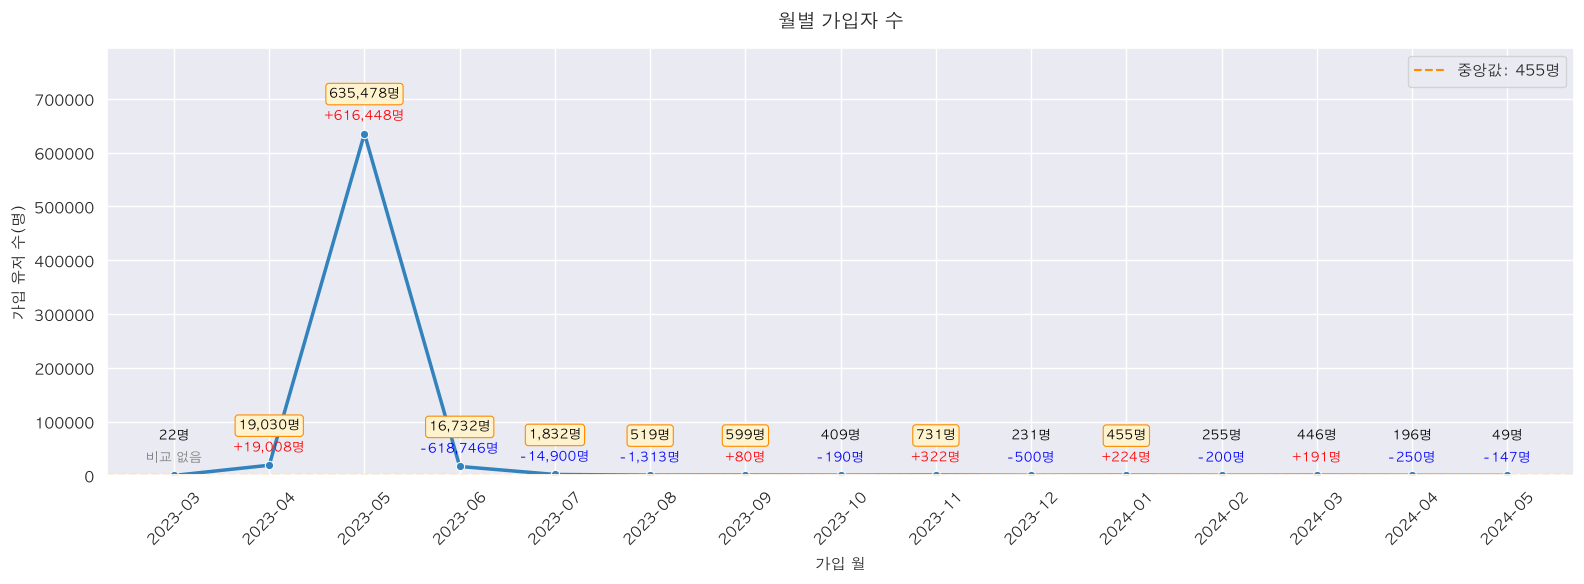

In [12]:
plot_monthly_signups(monthly_summary, '월별 가입자 수')

💡 차트 설명
- **직전 표시 월 대비:** 직전 표시 월과 비교한 가입자 수 증감
  - 🔴 **빨강:** 직전 표시 월 대비 가입자 수 증가
  - 🔵 **파랑:** 직전 표시 월 대비 가입자 수 감소
- 🟨 **노란색 박스:** 전체 기간의 월별 가입자 수 **중앙값 이상을 기록한 월**

---

- **5월 가입자 수가 매우 큰 폭으로 증가**했으나, 6월에 급격히 감소하며 증가세가 일시적인 현상에 그쳤습니다.

- 5월의 급격한 증가로 인해 **다른 월의 가입자 추이가 상대적으로 명확하게 드러나지 않아**, 5월 데이터를 제외한 후 월별 추이를 재확인을 진행합니다.

In [13]:
# 5월 제외 후 추이 재확인용 데이터
monthly_summary_ex_may = monthly_summary[
    ~monthly_summary['signup_month'].str.endswith('23-05')
].reset_index(drop=True)

print(monthly_summary_ex_may)

   signup_month  unique_users
0       2023-03            22
1       2023-04         19030
2       2023-06         16732
3       2023-07          1832
4       2023-08           519
5       2023-09           599
6       2023-10           409
7       2023-11           731
8       2023-12           231
9       2024-01           455
10      2024-02           255
11      2024-03           446
12      2024-04           196
13      2024-05            49


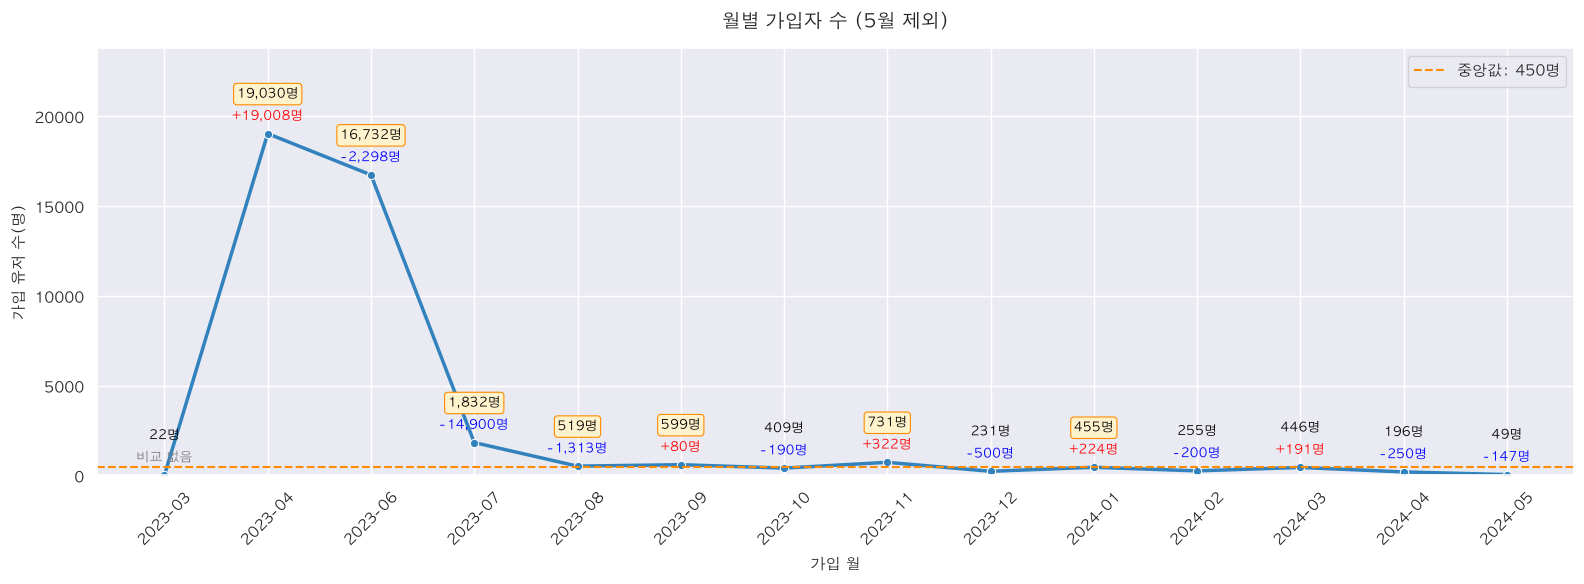

In [14]:
plot_monthly_signups(monthly_summary_ex_may, '월별 가입자 수 (5월 제외)')

💡 차트 설명
- **직전 표시 월 대비:** 직전 표시 월과 비교한 가입자 수 증감
  - 🔴 **빨강:** 직전 표시 월 대비 가입자 수 증가
  - 🔵 **파랑:** 직전 표시 월 대비 가입자 수 감소
- 🟨 **노란색 박스:** 전체 기간의 월별 가입자 수 **중앙값 이상을 기록한 월**

---

#### 월별 가입자 추이 확인
사용자 유입 측면에서 긍정적인 흐름을 보인 시점은 크게 세 가지 기준으로 구분할 수 있습니다.

* (1) **가입자 수가 다른 월 대비 두드러지게 높은 시기**: 2023년 4월, 5월, 6월<br>
* (2) **전월 대비 가입자 수가 증가한 달**: 2023년 4월, 5월, 9월, 11월 / 2024년 1월, 3월<br>
* (3) **가입자 수가 전체 기간 중앙값 이상인 달**: 2023년 4월~9월, 11월 / 2024년 1월<br>

#### 학사 일정과의 연관성 확인

**(2) 전월 대비 가입자 수가 증가한 시점**에 초점을 맞춰, 해당 시기의 증가가 **학사일정과 연관성이 있는지 확인**하고자 합니다.<br>

**(1), (3) 기준을 우선적으로 고려하지 않는 이유는 다음과 같습니다.**
- 서비스 출시 초기에는 초기 유입 효과로 인해 가입자 수가 일시적으로 크게 증가한 패턴이 포함되어 있습니다.
  - 서비스 출시 초기라고 판단한 근거는 `accounts_user` 전처리 수행 시 확인할 수 있던 내용으로, 서비스 내 가장 첫번째인 관리자 유저의 최초 계정 생성 시점이 '2023-03-29 03:44:14.047130+00:00'
- 이후에는 가입자 수가 장기적으로 감소하는 흐름을 보이고 있어, 단순히 가입자 규모가 크거나 중앙값 이상인 시점을 기준으로 비교할 경우 **초기 효과와 전체적인 감소 추세의 영향을 함께 받을 가능성**이 있습니다.
- 따라서 절대적인 가입자 규모보다는 **직전 월 대비 실제 유입이 증가한 시점**을 기준으로 학사일정과의 연관성을 탐색합니다.

#### 학사일정

- 학교의 학년도는 법령에 따라 **3월 1일부터 다음 해 2월 말까지**로 정해져 있으나, 세부적인 학기·수업일수·휴업일 등은 학교별로 차이가 있을 수 있습니다.

> **「초·중등교육법」 제24조(수업 등)**
>
> ① 학교의 학년도는 3월 1일부터 시작하여 다음 해 2월 말일까지로 한다.  
> ④ 학교의 학기·수업일수·학급편성·휴업일과 반의 편성·운영, 그 밖에 수업에 필요한 사항은 대통령령으로 정한다.

- 따라서 모든 학교에 동일한 세부 학사일정을 적용하기에는 한계가 있으므로, 본 분석에서는 **일반적인 중·고등학교의 학사일정을 참고하여 월별 가입자 추이와 비교**합니다.

- 아래 학사일정은 **가입자 추이와 학사일정 간의 전반적인 흐름을 탐색하기 위한 참고 자료**로, AI를 활용해 일반적인 중·고등학교의 학사일정을 정리하였습니다. 실제 일정은 학교별로 차이가 있을 수 있습니다.

| 시기 | 주요 학사일정 |
|---|---|
| **3월 초** | 입학식·시업식, 새 학년 시작 |
| **3~4월** | 정규수업, 학급·동아리 활동 시작 |
| **4월 말~5월 초** | 1학기 중간고사 |
| **5월** | 중간고사 이후 수업, 체육대회·체험활동 등 |
| **6월 말~7월 초** | 1학기 기말고사 |
| **7월 중·하순~8월 중·하순** | 여름방학 및 개학 |
| **8월 중·하순~9월** | 2학기 수업 시작 |
| **9월 말~10월** | 2학기 중간고사 |
| **10~11월** | 정규수업, 수학여행·체험활동 등 |
| **11월** | 대학수학능력시험 |
| **12월** | 2학기 기말고사, 학년말 활동 |
| **12월 말~2월** | 겨울방학, 종업·졸업, 학년말 방학 |

#### 💡 가입자 증가 시점과 학사일정 비교

전월 대비 가입자 수가 증가한 시점을 일반적인 학사일정과 비교하면 다음과 같습니다.

| 가입 증가 시점 | 일반적인 학사일정 | 해석 |
|---|---|---|
| **2023년 4월** | 정규수업 및 학급·동아리 활동 시작 | 새 학년 시작 이후 교내 관계 및 활동이 형성되는 시기 |
| **2023년 5월** | 중간고사 종료, 체육대회·체험활동 등 | 시험 이후 교내 활동이 활발해지는 시기 |
| **2023년 9월** | 2학기 수업 시작 | 2학기 개학 이후 학교생활이 다시 시작되는 시기 |
| **2023년 11월** | 정규수업 및 교내·체험활동 | 2학기 중간고사 이후 학교생활이 이어지는 시기 |
| **2024년 1월** | 겨울방학 및 학년말 기간 | 일반적인 학기 중 활동과는 거리가 있는 시기 |
| **2024년 3월** | 입학·개학 및 새 학년 시작 | 새로운 학급과 교우관계가 형성되는 시기 |

가입자가 증가한 6개 시점 중 **4월·5월·9월·11월·3월은 학기 시작 또는 학기 중 학교생활이 이루어지는 시기**라는 공통점을 확인할 수 있습니다.

특히 **3월·4월과 9월처럼 새로운 학기 또는 학년이 시작되는 시점 전후에 가입자 증가가 나타난 점**은 주목할 만합니다.

반면 **2024년 1월은 겨울방학 기간임에도 가입자가 증가**하여 학사일정만으로 모든 증가 시점을 설명하기에는 한계가 있습니다.

따라서 현재 단계에서는 **학교생활이 활발해지는 시점과 신규 가입자 증가 사이에 일정한 연관성이 나타날 가능성**을 확인할 수 있으나, 학사일정이 가입 증가의 직접적인 원인이라고 판단하기보다는 추가적인 요인과 함께 살펴볼 필요가 있습니다.

## 2. 가입자 구성 분석

In [15]:
school_summary = (
    df.groupby('school_type')['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

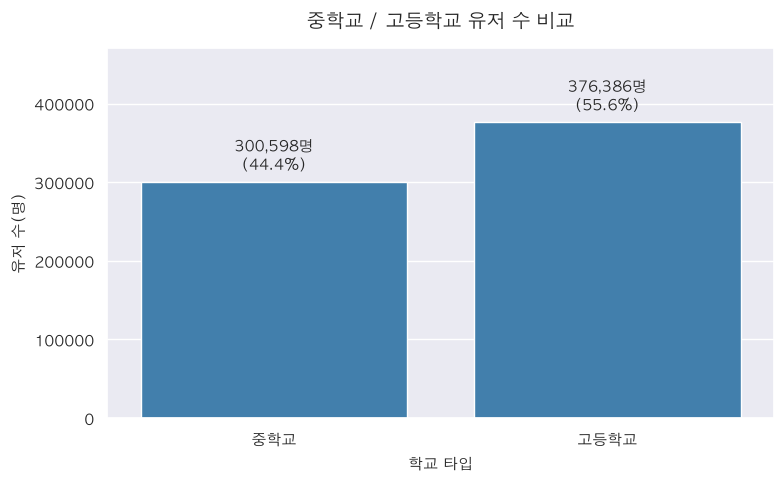

In [16]:
plt.figure(figsize=(8, 5))

# 막대그래프
ax = sns.barplot(
    data=school_summary,
    x='school_type',
    y='unique_users',
    order=['M', 'H'],
    color='#3182bd'
)

ax.set_xticks([0, 1], labels=['중학교', '고등학교'])

# 그래프에 표시된 학교급 전체 가입자 수 기준
total_users = school_summary['unique_users'].sum()

# 막대 위에 숫자 표시
for p in ax.patches:
    height = p.get_height()
    share = height / total_users * 100 if total_users else 0
    ax.annotate(
        f'{int(height):,}명\n({share:.1f}%)',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
    )

plt.title('중학교 / 고등학교 유저 수 비교', fontsize=14, pad=15)
plt.xlabel('학교 타입', fontsize=11)
plt.ylabel('유저 수(명)', fontsize=11)

# 위쪽 숫자가 잘리지 않도록 여유 공간
plt.ylim(0, school_summary['unique_users'].max() * 1.25)

plt.tight_layout()
plt.show()

In [17]:
# 학교급·학년별 고유 가입자 수 집계
school_grade_summary = (
    df.groupby(['school_type', 'grade'])['user_id']
      .nunique()
      .reset_index(name='unique_users')
)

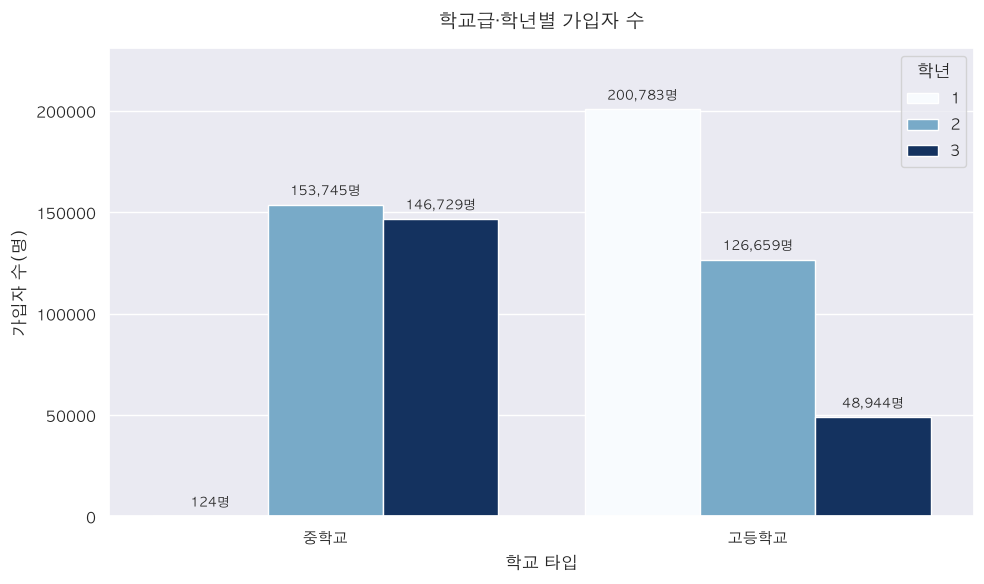

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=school_grade_summary,
    x='school_type',
    y='unique_users',
    hue='grade',
    order=['M', 'H'],
    palette='Blues',
    ax=ax,
)

ax.set_xticks([0, 1], labels=['중학교', '고등학교'])

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:,.0f}명' for value in container.datavalues],
        padding=4,
        fontsize=9,
    )

ax.set_title('학교급·학년별 가입자 수', fontsize=14, pad=15)
ax.set_xlabel('학교 타입')
ax.set_ylabel('가입자 수(명)')
ax.legend(title='학년')
ax.set_ylim(0, school_grade_summary['unique_users'].max() * 1.15)

fig.tight_layout()
plt.show()


#### 💡 학교급 및 학년별 가입자 분포

- 서비스 가입자는 **중학생 44.4%(300,598명)**, **고등학생 55.6%(376,386명)**으로 구성되어 있어, 특정 학교급에 크게 편중되지 않고 중·고등학생 모두 고르게 이용하는 형태를 보입니다.

- 다만 학년별로 세분화하면 **중학교 2학년부터 고등학교 2학년까지의 가입자가 전체 가입자의 대부분을 차지**하고 있으며, 특히 **고등학교 1학년(200,783명)**의 가입자 수가 가장 많습니다.

- 이를 통해 서비스의 **핵심 사용자층은 중학교 2학년~고등학교 2학년 구간**에 형성되어 있음을 확인할 수 있습니다.

## 3. 학교 위치 별 유저 수 비교

In [19]:
# 학교 소재지 기준: 주소 공백 정리 및 지역 구분
area_df = df.copy()

address = (
    area_df['address']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)

parts = address.str.split(n=2, expand=True)

area_df['시도'] = parts[0].fillna('미상')
area_df['시군구'] = parts.reindex(columns=[1])[1].fillna('미기재')

# 시·도별 고유 가입자 수
region_summary = (
    area_df.groupby('시도')['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 시·도 + 시·군·구별 고유 가입자 수
city_summary = (
    area_df.groupby(['시도', '시군구'])['user_id']
    .nunique()
    .reset_index(name='가입자 수')
    .sort_values('가입자 수', ascending=False)
)

# 전체 고유 가입자 대비 지역별 비중
total_users = area_df['user_id'].nunique()

region_summary['비중(%)'] = (
    region_summary['가입자 수'] / total_users * 100
).round(2)

city_summary['비중(%)'] = (
    city_summary['가입자 수'] / total_users * 100
).round(2)

# display(region_summary)
# display(city_summary)


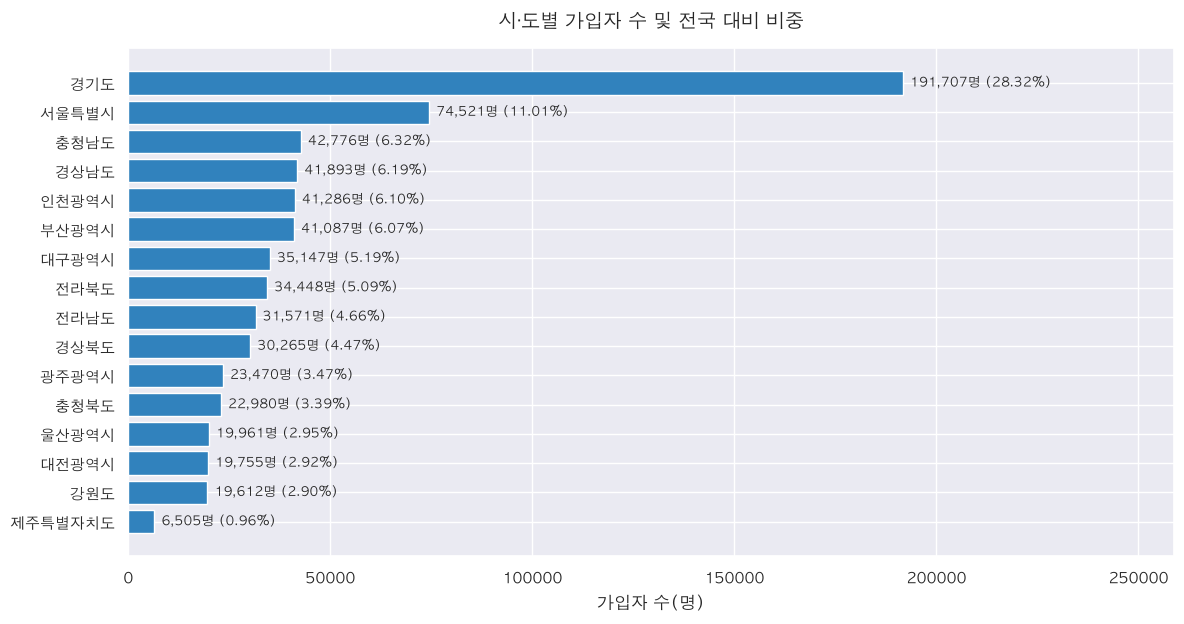

In [20]:
plot_area_signups(
    region_summary.sort_values('가입자 수', ascending=False),
    '시도',
    '시·도별 가입자 수 및 전국 대비 비중',
)

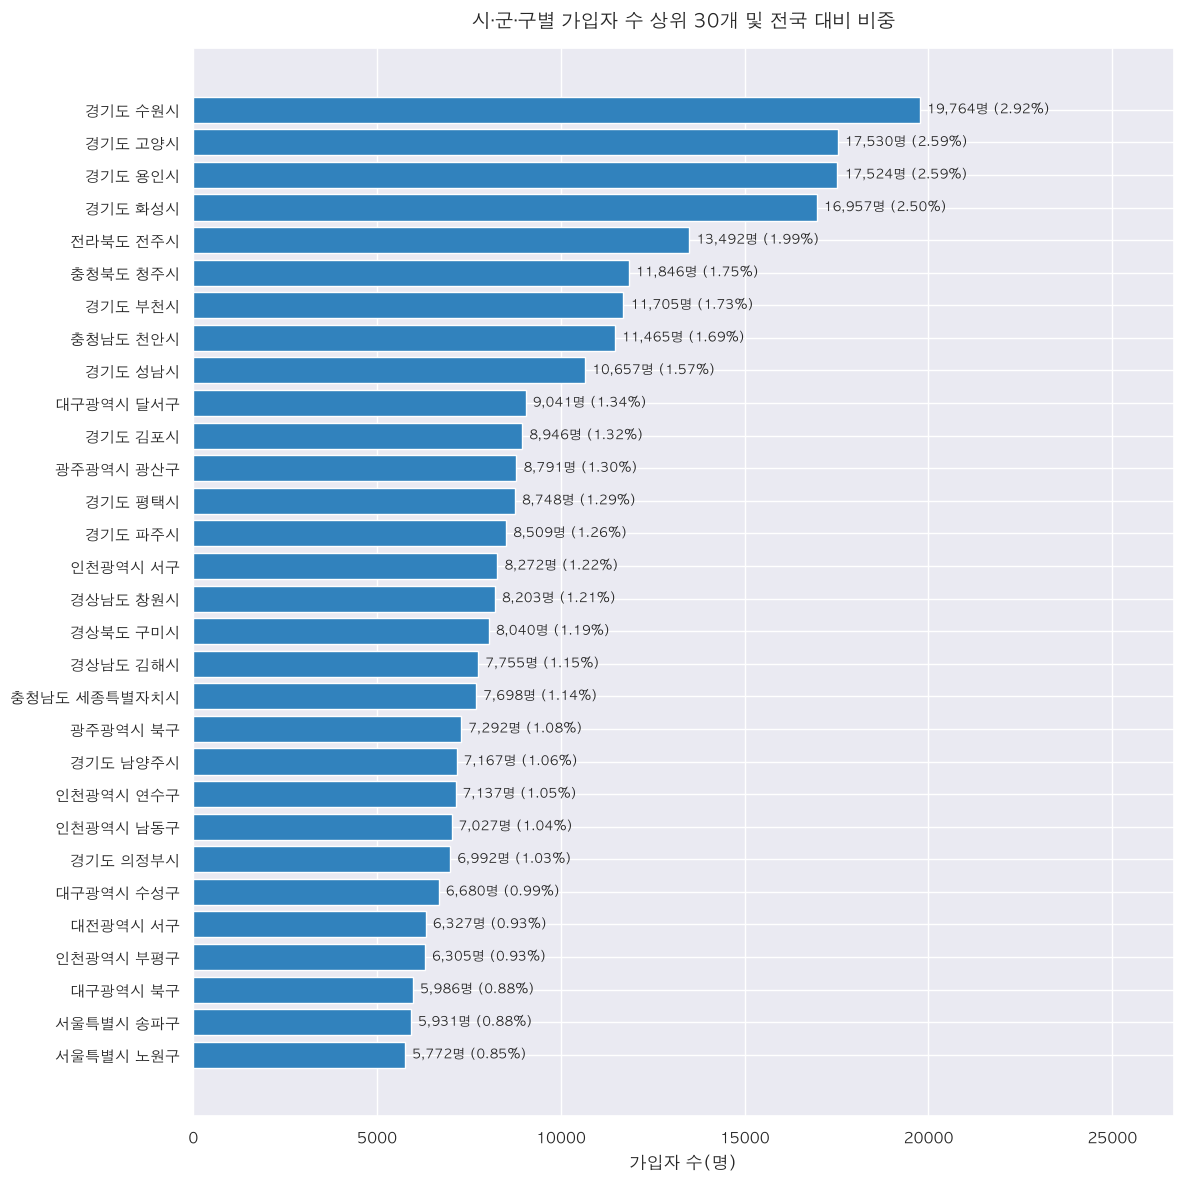

In [21]:
city_top30 = (
    city_summary.nlargest(30, '가입자 수')
    .copy()
)

city_top30['지역'] = city_top30['시도'] + ' ' + city_top30['시군구']

plot_area_signups(
    city_top30,
    '지역',
    '시·군·구별 가입자 수 상위 30개 및 전국 대비 비중',
)

#### 💡 학교 위치별 가입자 분포

- **경기도**는 전체 가입자의 약 **28%**를 차지하며, 가장 많은 가입자가 분포한 지역입니다.

- 그다음으로 **서울(약 11%)**이 높은 비중을 차지하며, 충청남도, 경상남도, 인천, 부산, 대구 순으로 이어집니다.

- 다만 **시·군·구 단위로 세분화하면 다른 양상**을 확인할 수 있습니다. 서울은 광역 단위에서는 두 번째로 가입자가 많지만, 개별 행정구는 가입자 수 기준 상위권에서 상대적으로 적게 나타납니다.

- 이를 통해 서울은 **특정 행정구에 가입자가 집중되기보다는 여러 행정구에 비교적 분산되어 있을 가능성**을 생각해볼 수 있습니다.

### 지역별 가입자 편차 비교

In [22]:
# 전체 시·군·구별 가입자 수의 평균과 중앙값
# 시·도별 평균의 평균이 아니라, city_summary 전체 행을 기준으로 계산합니다.
overall_area_summary = pd.DataFrame([{
    '기준': '전체 시·군·구 (현재 집계 기준)',
    '시군구수': len(city_summary),
    '평균': city_summary['가입자 수'].mean(),
    '중앙값': city_summary['가입자 수'].median(),
}])

display(
    overall_area_summary.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}'}
    )
)

# 시·도 내 시·군·구별 가입자 수의 표준편차가 작은 순서
# 현재 집계에 포함된 지역 기준이며, 가입자가 없는 미관측 지역은 포함하지 않습니다.
region_dispersion = (
    city_summary.groupby('시도')['가입자 수']
    .agg(
        시군구수='size',
        평균='mean',
        중앙값='median',
        표준편차=lambda values: values.std(ddof=0),
    )
    .reset_index()
)

# 비교 대상이 하나뿐인 지역은 순위를 매기지 않습니다.
comparable = region_dispersion['시군구수'].ge(2)
region_dispersion.loc[~comparable, '표준편차'] = float('nan')
region_dispersion['순위'] = (
    region_dispersion['표준편차'].rank(method='min').astype('Int64')
)
region_dispersion = (
    region_dispersion.sort_values(['표준편차', '시도'], na_position='last')
    [['순위', '시도', '시군구수', '평균', '중앙값', '표준편차']]
    .reset_index(drop=True)
)

display(
    region_dispersion.style.format(
        {'평균': '{:,.1f}', '중앙값': '{:,.1f}', '표준편차': '{:,.1f}'},
        na_rep='비교 제외',
    )
)



,기준,시군구수,평균,중앙값
0,전체 시·군·구 (현재 집계 기준),229,"2,956.3","1,943.0"


,순위,시도,시군구수,평균,중앙값,표준편차
0,1,울산광역시,5,"3,992.2","3,800.0",684.5
1,2,서울특별시,25,"2,980.8","2,592.0","1,309.4"
2,3,강원도,18,"1,089.6",530.5,"1,415.4"
3,4,전라남도,22,"1,435.0",671.0,"1,580.1"
4,5,대전광역시,5,"3,951.0","3,236.0","1,595.6"
5,6,부산광역시,16,"2,567.9","1,934.0","1,602.5"
6,7,경상북도,23,"1,315.9",525.0,"1,725.4"
7,8,제주특별자치도,2,"3,252.5","3,252.5","2,384.5"
8,9,대구광역시,8,"4,393.4","3,851.5","2,469.7"
9,10,경상남도,18,"2,327.4","1,208.0","2,513.1"


#### 💡 지역별 가입자 분포 및 편차

- 시·도별 **시·군·구 가입자 수의 표준편차**를 비교한 결과, 서울은 오름차순 기준 **두 번째로 낮은 표준편차**를 기록했습니다. 이를 통해 서울의 가입자가 특정 행정구에 집중되기보다는 **지역별로 비교적 고르게 분포되어 있다는 앞선 가설을 확인**할 수 있었습니다.

- 또한 서울은 개별 행정구의 가입자 수가 두드러지게 높지는 않지만, **다수의 행정구에서 비교적 고르게 가입자를 확보하면서 전체 가입자 수 기준 2위**를 기록한 것으로 볼 수 있습니다.

- 반면 **경기도는 시·군·구별 가입자 수의 편차가 상대적으로 크게 나타났습니다.** 즉, 일부 지역에 가입자가 집중되는 경향이 존재하지만, 동시에 **다수의 행정구역에서 많은 가입자를 확보하면서 전체 가입자 수 기준 가장 높은 비중(약 28%)**을 차지한 것으로 보입니다.

## 4. 집단 가입 패턴 및 확산 속도 분석

동일 학급 내 사용자들의 가입 시점을 비교하여, **특정 시간 내 가입이 집중되는 집단 가입 패턴이 존재하는지 확인**합니다.

### 분석 가정

- 학급(`group_id`) 변경을 위해서는 학생증 등의 증빙 절차가 필요하므로, **사용자의 학급 정보가 빈번하게 변경되기 어려운 구조**라고 판단했습니다.
- 이에 따라 현재 기록된 `group_id`가 **가입 당시에도 동일했다고 가정**하여 분석을 진행합니다.
- 또한 기획서상 연도 변경 시점의 학급 변경 Flow를 확인하기 어려워, **학년 변경 등에 따른 `group_id` 변동 가능성은 본 분석에서 고려하지 않습니다.**

### 4-1. 학급별 집단 가입 패턴 확인

#### 분석 기준

- **고유 가입자가 4명 이상인 그룹**을 분석 대상으로 설정합니다.
- 각 그룹에서 연속된 **24시간 내 최대 가입자 수**와 **가입 집중도**를 계산합니다.
- **가입 집중도**는 해당 그룹의 전체 관측 가입자 중 특정 24시간 내 가입한 사용자의 비율을 의미하며, **실제 학급 정원 대비 가입률은 아닙니다.**
- 24시간 구간은 **시작 시각 이상, 종료 시각 미만**을 기준으로 하며, 최대 가입자 수가 동일한 구간이 여러 개 존재할 경우 **가장 이른 구간을 선택**합니다.

> **해석 시 유의사항**  
> `4명 이상`과 `24시간`은 집단 가입 패턴을 탐색하기 위해 설정한 기준입니다. 따라서 특정 시간 내 가입이 집중되었다는 결과만으로 **친구 초대, 입소문 등의 구체적인 유입 원인을 확정하지 않습니다.**

In [23]:
group_burst_summary, group_coverage = analyze_signup_bursts(
    df,
    entity_col='group_id',
    min_users=4,
    window_hours=24,
)

display(group_coverage)
display(group_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,80891
1,분석 대상 집단,56956
2,최소 인원 미달 집단,23935


,group_id,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,43124,24,24,100.0,2023-05-11 01:12:49.669935+00:00,2023-05-12 01:12:49.669935+00:00,2023-05-11 01:12:49.669935+00:00,2023-05-12 00:57:01.749899+00:00
1,38756,22,22,100.0,2023-05-17 01:11:49.634726+00:00,2023-05-18 01:11:49.634726+00:00,2023-05-17 01:11:49.634726+00:00,2023-05-17 11:06:57.134108+00:00
2,41875,22,22,100.0,2023-05-10 11:32:11.607936+00:00,2023-05-11 11:32:11.607936+00:00,2023-05-10 11:32:11.607936+00:00,2023-05-11 09:36:33.179702+00:00
3,52751,21,21,100.0,2023-05-13 03:44:50.520752+00:00,2023-05-14 03:44:50.520752+00:00,2023-05-13 03:44:50.520752+00:00,2023-05-13 16:23:17.516385+00:00
4,11500,20,20,100.0,2023-05-06 11:26:30.975532+00:00,2023-05-07 11:26:30.975532+00:00,2023-05-06 11:26:30.975532+00:00,2023-05-07 08:18:16.258602+00:00


In [24]:
group_distribution = summarize_burst_distribution(
    group_burst_summary,
    entity_label='학급',
    window_hours=24,
)

display(group_distribution)

,24시간 가입 집중도 구간,학급 수,학급 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,486,0.85
2,20~30% 미만,5894,10.35
3,30~40% 미만,9817,17.24
4,40~50% 미만,10912,19.16
5,50~60% 미만,12647,22.20
6,60~70% 미만,7592,13.33
7,70~80% 미만,4972,8.73
8,80~90% 미만,3082,5.41
9,90~100%,1554,2.73


#### 💡 집단 가입 집중도 분석

- 가입 집중도는 **40~60% 구간에 가장 많은 그룹이 분포**하며, 특히 **50~60% 구간이 22.20%로 가장 높은 비중**을 차지합니다.

- 전체 그룹의 약 **71.6%가 가입 집중도 40% 이상**, 약 **52.4%가 50% 이상**으로 나타났습니다. 즉, 상당수 그룹에서 **관측된 가입자의 절반가량이 특정 24시간 내 집중적으로 가입하는 패턴**을 확인할 수 있습니다.

- 특히 가입 집중도가 **70% 이상인 그룹도 약 16.9%** 존재하여, 일부 그룹에서는 구성원의 상당수가 짧은 시간 내 연속적으로 가입하는 강한 집단 가입 패턴이 나타납니다.

- 이를 통해 서비스 가입이 사용자별로 독립적으로 발생하기보다는, **동일 학급 내에서 특정 시점을 중심으로 가입이 집중되는 경향이 존재할 가능성**을 확인할 수 있습니다.

### 4-2. 학교별 집단 가입 패턴 확인

#### 분석 기준

- **고유 가입자가 40명 이상인 학교**을 분석 대상으로 설정합니다.
- 각 그룹에서 연속된 **72시간 내 최대 가입자 수**와 **가입 집중도**를 계산합니다.
- **가입 집중도**는 해당 그룹의 전체 관측 가입자 중 특정 72시간 내 가입한 사용자의 비율을 의미하며, **실제 학급 정원 대비 가입률은 아닙니다.**
- 72시간 구간은 **시작 시각 이상, 종료 시각 미만**을 기준으로 하며, 최대 가입자 수가 동일한 구간이 여러 개 존재할 경우 **가장 이른 구간을 선택**합니다.

> **해석 시 유의사항**  
> `40명 이상`과 `72시간`은 집단 가입 패턴을 탐색하기 위해 설정한 기준입니다. 따라서 특정 시간 내 가입이 집중되었다는 결과만으로 **친구 초대, 입소문 등의 구체적인 유입 원인을 확정하지 않습니다.**

In [25]:
school_burst_summary, school_coverage = analyze_signup_bursts(
    df,
    entity_col='school_id',
    min_users=40,
    window_hours=72,
)

display(school_coverage)
display(school_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,5548
1,분석 대상 집단,3896
2,최소 인원 미달 집단,1652


,school_id,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,3706,53,53,100.000000,2023-05-29 10:40:47.752915+00:00,2023-06-01 10:40:47.752915+00:00,2023-05-29 10:40:47.752915+00:00,2023-05-30 22:31:36.762446+00:00
1,1891,69,68,98.550725,2023-05-06 02:10:46.685623+00:00,2023-05-09 02:10:46.685623+00:00,2023-05-06 02:10:46.685623+00:00,2023-05-19 12:38:55.364632+00:00
2,5957,136,132,97.058824,2023-05-15 15:26:40.338277+00:00,2023-05-18 15:26:40.338277+00:00,2023-05-13 04:24:46.791535+00:00,2023-05-23 22:10:54.245575+00:00
3,4403,132,128,96.969697,2023-05-09 14:12:00.305554+00:00,2023-05-12 14:12:00.305554+00:00,2023-05-05 08:13:21.316376+00:00,2023-05-13 15:02:37.269468+00:00
4,878,200,193,96.500000,2023-05-16 12:53:40.293467+00:00,2023-05-19 12:53:40.293467+00:00,2023-05-07 03:20:55.877691+00:00,2024-03-31 15:25:42.102031+00:00


In [26]:
school_distribution = summarize_burst_distribution(
    school_burst_summary,
    entity_label='학교',
    window_hours=72,
)

display(school_distribution)

,72시간 가입 집중도 구간,학교 수,학교 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,3,0.08
2,20~30% 미만,152,3.90
3,30~40% 미만,478,12.27
4,40~50% 미만,706,18.12
5,50~60% 미만,781,20.05
6,60~70% 미만,772,19.82
7,70~80% 미만,651,16.71
8,80~90% 미만,313,8.03
9,90~100%,40,1.03


#### 💡 학교 단위 72시간 가입 집중도 분석

- 학교별 가입 집중도는 **50~60% 구간이 20.05%로 가장 높은 비중**을 차지하며, 60~70%(19.82%), 40~50%(18.12%), 70~80%(16.71%) 순으로 나타났습니다.

- 전체 학교의 약 **65.6%에서 관측 가입자의 절반 이상이 특정 72시간 내 가입**한 것으로 나타났으며, 약 **45.6%는 60% 이상의 가입자가 72시간 내 집중적으로 가입**했습니다.

- 특히 가입 집중도가 **70% 이상인 학교도 약 25.8%**로 나타나, 일부 학교에서는 가입자의 상당수가 짧은 기간 내 집중적으로 유입되는 패턴을 확인할 수 있습니다.

- 반면 가입 집중도가 **30% 미만인 학교는 약 4.0%**에 불과하여, 가입이 장기간에 걸쳐 분산되기보다는 **특정 시기를 중심으로 집중되는 학교가 상대적으로 많은 형태**를 보입니다.

- 이를 통해 개별 사용자의 가입이 독립적으로 발생하는 것뿐만 아니라, **학교 단위에서도 일정 기간 내 가입이 집중되는 확산 패턴이 존재할 가능성**을 확인할 수 있습니다.

### 4-3. 도시(시군구)별 집단 가입 패턴 확인

In [27]:
city_data = area_df.copy()
city_data['지역'] = city_data['시도'] + ' ' + city_data['시군구']

city_burst_summary, city_coverage = analyze_signup_bursts(
    city_data,
    entity_col='지역',
    min_users=40,
    window_hours=72,
)

display(city_coverage)
display(city_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,229
1,분석 대상 집단,226
2,최소 인원 미달 집단,3


,지역,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,경상남도 함양군,657,536,81.582953,2023-05-21 10:41:05.424898+00:00,2023-05-24 10:41:05.424898+00:00,2023-05-06 14:00:12.914564+00:00,2023-06-19 22:28:03.028131+00:00
1,전라북도 순창군,535,435,81.308411,2023-05-22 10:15:04.989666+00:00,2023-05-25 10:15:04.989666+00:00,2023-05-03 13:00:30.512301+00:00,2023-12-26 12:29:44.452839+00:00
2,울산광역시 동구,3434,2559,74.519511,2023-05-06 12:03:45.789199+00:00,2023-05-09 12:03:45.789199+00:00,2023-04-26 12:02:06.601496+00:00,2024-03-30 13:25:20.197416+00:00
3,경기도 연천군,521,375,71.976967,2023-05-09 12:01:11.900879+00:00,2023-05-12 12:01:11.900879+00:00,2023-05-04 03:41:50.253075+00:00,2024-04-24 12:40:41.958836+00:00
4,전라남도 화순군,1291,867,67.157242,2023-05-20 02:02:46.100655+00:00,2023-05-23 02:02:46.100655+00:00,2023-04-20 15:48:09.816573+00:00,2024-03-09 14:47:38.220253+00:00


In [28]:
city_distribution = summarize_burst_distribution(
    city_burst_summary,
    entity_label='도시',
    window_hours=72,
)

display(city_distribution)

,72시간 가입 집중도 구간,도시 수,도시 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,10,4.42
2,20~30% 미만,59,26.11
3,30~40% 미만,66,29.20
4,40~50% 미만,49,21.68
5,50~60% 미만,29,12.83
6,60~70% 미만,9,3.98
7,70~80% 미만,2,0.88
8,80~90% 미만,2,0.88
9,90~100%,0,0.00


### 4-4. 지역(시도)별 집단 가입 패턴 확인

In [29]:
region_burst_summary, region_coverage = analyze_signup_bursts(
    area_df,
    entity_col='시도',
    min_users=40,
    window_hours=72,
)

display(region_coverage)
display(region_burst_summary.head(5))

,구분,집단 수
0,전체 유효 집단,16
1,분석 대상 집단,16
2,최소 인원 미달 집단,0


,시도,가입자 수,최대 구간 가입자 수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),최초 가입,최종 가입
0,충청북도,22980,8179,35.591819,2023-05-06 00:46:25.019348+00:00,2023-05-09 00:46:25.019348+00:00,2023-04-04 03:19:12.336682+00:00,2024-05-06 13:48:40.161236+00:00
1,경기도,191707,67319,35.115567,2023-05-06 12:22:55.615616+00:00,2023-05-09 12:22:55.615616+00:00,2023-03-31 09:05:51.903699+00:00,2024-05-07 11:57:29.459197+00:00
2,광주광역시,23470,7858,33.481040,2023-05-13 10:22:50.955585+00:00,2023-05-16 10:22:50.955585+00:00,2023-04-20 13:46:23.302662+00:00,2024-05-03 12:29:46.469304+00:00
3,울산광역시,19961,6093,30.524523,2023-05-09 10:47:37.070973+00:00,2023-05-12 10:47:37.070973+00:00,2023-04-21 09:27:54.389241+00:00,2024-04-11 15:41:09.267276+00:00
4,인천광역시,41286,11939,28.917793,2023-05-11 06:26:56.825331+00:00,2023-05-14 06:26:56.825331+00:00,2023-04-11 02:15:46.781874+00:00,2024-04-28 14:40:07.345830+00:00


In [30]:
region_distribution = summarize_burst_distribution(
    region_burst_summary,
    entity_label='지역',
    window_hours=72,
)

display(region_distribution)

,72시간 가입 집중도 구간,지역 수,지역 비중(%)
0,0~10% 미만,0,0.00
1,10~20% 미만,1,6.25
2,20~30% 미만,11,68.75
3,30~40% 미만,4,25.00
4,40~50% 미만,0,0.00
5,50~60% 미만,0,0.00
6,60~70% 미만,0,0.00
7,70~80% 미만,0,0.00
8,80~90% 미만,0,0.00
9,90~100%,0,0.00


### 4-5. 인접학교 간 집단가입 시간 차

In [31]:
nearby_sql = f"""
    SELECT school_id, nearby_school_id
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_nearbyschool`
"""

nearby_raw = client.query(nearby_sql).to_dataframe()

nearby_valid = (
    nearby_raw
    .dropna(subset=['school_id', 'nearby_school_id'])
    .copy()
)

# 자기 자신과 연결된 관계 제외
nearby_valid = nearby_valid[
    nearby_valid['school_id'].ne(nearby_valid['nearby_school_id'])
]

# A→B, B→A를 동일한 학교 쌍으로 정리
nearby_pairs = pd.DataFrame({
    'school_a': nearby_valid[
        ['school_id', 'nearby_school_id']
    ].min(axis=1),
    'school_b': nearby_valid[
        ['school_id', 'nearby_school_id']
    ].max(axis=1),
}).drop_duplicates().reset_index(drop=True)

print(f'원본 관계: {len(nearby_raw):,}행')
print(f'중복 제거 후 인접 학교 쌍: {len(nearby_pairs):,}개')

원본 관계: 66,696행
중복 제거 후 인접 학교 쌍: 33,348개


In [32]:
school_stats = school_burst_summary[[
    'school_id',
    '가입자 수',
    '가입 집중도(%)',
    '집중 구간 시작',
    '집중 구간 종료(미포함)',
]].copy()

# 기존 결과가 실제로 40명 이상·72시간 조건인지 확인
if school_stats['school_id'].duplicated().any():
    raise ValueError('학교별 집중도 결과에 중복 school_id가 있습니다.')

if school_stats['가입자 수'].lt(40).any():
    raise ValueError('학교 가입자 40명 이상 조건을 확인해 주세요.')

window_lengths = (
    school_stats['집중 구간 종료(미포함)']
    - school_stats['집중 구간 시작']
)
if not window_lengths.eq(pd.Timedelta(hours=72)).all():
    raise ValueError('school_burst_summary가 72시간 기준인지 확인해 주세요.')


def attach_school_stats(pairs, stats, suffix):
    renamed = stats.rename(columns={
        'school_id': f'school_{suffix}',
        '가입자 수': f'{suffix}_가입자 수',
        '가입 집중도(%)': f'{suffix}_집중도(%)',
        '집중 구간 시작': f'{suffix}_시작',
        '집중 구간 종료(미포함)': f'{suffix}_종료',
    })

    return pairs.merge(
        renamed,
        on=f'school_{suffix}',
        how='inner',
        validate='many_to_one',
    )


pair_comparison = attach_school_stats(nearby_pairs, school_stats, 'a')
pair_comparison = attach_school_stats(pair_comparison, school_stats, 'b')

display(pd.DataFrame({
    '구분': ['전체 인접 학교 쌍', '분석 대상 학교 쌍', '한쪽 이상 분석 대상 아님'],
    '학교 쌍 수': [
        len(nearby_pairs),
        len(pair_comparison),
        len(nearby_pairs) - len(pair_comparison),
    ],
}))

,구분,학교 쌍 수
0,전체 인접 학교 쌍,33348
1,분석 대상 학교 쌍,16890
2,한쪽 이상 분석 대상 아님,16458


In [33]:
pair_comparison['집중 시작 시차(시간)'] = (
    (pair_comparison['a_시작'] - pair_comparison['b_시작'])
    .abs()
    .dt.total_seconds()
    / 3600
)

# 두 구간 중 늦은 시작과 이른 종료를 이용
overlap_start = pair_comparison['a_시작'].where(
    pair_comparison['a_시작'].ge(pair_comparison['b_시작']),
    pair_comparison['b_시작'],
)

overlap_end = pair_comparison['a_종료'].where(
    pair_comparison['a_종료'].le(pair_comparison['b_종료']),
    pair_comparison['b_종료'],
)

pair_comparison['집중 구간 중첩(시간)'] = (
    (overlap_end - overlap_start)
    .dt.total_seconds()
    .div(3600)
    .clip(lower=0)
)

In [34]:
school_events = (
    df[['user_id', 'school_id', 'signup_date']]
    .dropna(subset=['user_id', 'school_id', 'signup_date'])
    .sort_values('signup_date')
    .drop_duplicates(['school_id', 'user_id'], keep='first')
)

school_times = {
    school_id: pd.DatetimeIndex(group['signup_date']).sort_values()
    for school_id, group in school_events.groupby('school_id')
}

# 집중도 결과와 현재 df의 학교별 가입자 수가 일치하는지 확인
for _, school in school_stats.iterrows():
    times = school_times.get(school['school_id'])
    if times is None or len(times) != school['가입자 수']:
        raise ValueError(
            'df와 school_burst_summary의 대상 데이터가 다릅니다. '
            '학교 집중도를 다시 계산해 주세요.'
        )


def signup_share_in_window(times, start, end):
    left = times.searchsorted(start, side='left')
    right = times.searchsorted(end, side='left')
    return (right - left) / len(times) * 100


a_during_b = []
b_during_a = []

for _, pair in pair_comparison.iterrows():
    a_during_b.append(signup_share_in_window(
        school_times[pair['school_a']],
        pair['b_시작'],
        pair['b_종료'],
    ))

    b_during_a.append(signup_share_in_window(
        school_times[pair['school_b']],
        pair['a_시작'],
        pair['a_종료'],
    ))

pair_comparison['B 집중 구간 내 A 가입 비중(%)'] = a_during_b
pair_comparison['A 집중 구간 내 B 가입 비중(%)'] = b_during_a

pair_comparison = (
    pair_comparison
    .sort_values(
        ['집중 구간 중첩(시간)', '집중 시작 시차(시간)'],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(pair_comparison.head(5))

,school_a,school_b,a_가입자 수,a_집중도(%),a_시작,a_종료,b_가입자 수,b_집중도(%),b_시작,b_종료,집중 시작 시차(시간),집중 구간 중첩(시간),B 집중 구간 내 A 가입 비중(%),A 집중 구간 내 B 가입 비중(%)
0,1757,1758,165,69.696970,2023-05-07 07:59:38.027097+00:00,2023-05-10 07:59:38.027097+00:00,175,72.571429,2023-05-07 07:59:37.840859+00:00,2023-05-10 07:59:37.840859+00:00,0.000052,71.999948,69.696970,72.000000
1,5657,5846,43,55.813953,2023-05-23 14:34:16.537873+00:00,2023-05-26 14:34:16.537873+00:00,88,75.000000,2023-05-23 14:34:17.618879+00:00,2023-05-26 14:34:17.618879+00:00,0.000300,71.999700,53.488372,75.000000
2,3467,3483,344,63.081395,2023-05-11 14:29:02.428926+00:00,2023-05-14 14:29:02.428926+00:00,308,66.558442,2023-05-11 14:29:04.232887+00:00,2023-05-14 14:29:04.232887+00:00,0.000501,71.999499,62.790698,66.558442
3,5789,5796,228,63.157895,2023-05-22 06:56:33.698352+00:00,2023-05-25 06:56:33.698352+00:00,261,55.938697,2023-05-22 06:56:41.168159+00:00,2023-05-25 06:56:41.168159+00:00,0.002075,71.997925,62.719298,55.938697
4,5207,5219,174,60.344828,2023-05-06 07:32:41.805105+00:00,2023-05-09 07:32:41.805105+00:00,118,46.610169,2023-05-06 07:32:33.745123+00:00,2023-05-09 07:32:33.745123+00:00,0.002239,71.997761,60.344828,45.762712


,집중 시작 시차,학교 쌍 수,학교 쌍 비중(%)
0,24시간 미만,5800,34.34
1,24~72시간 미만,4694,27.79
2,72~168시간 미만,3489,20.66
3,168시간 이상,2907,17.21


,분석 학교 쌍 수,집중 시작 시차 중앙값(시간),집중 구간이 겹치는 쌍 비중(%)
0,16890,46.73,62.13


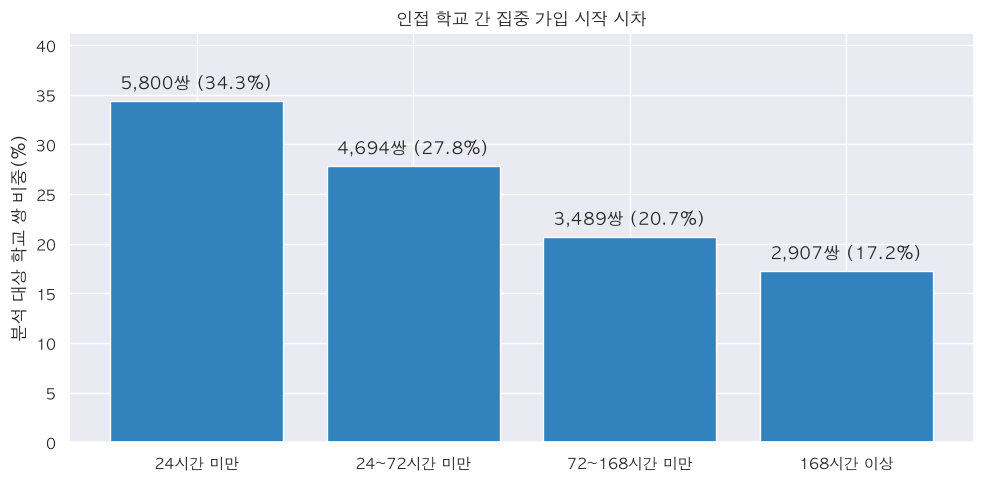

In [35]:
gap_labels = [
    '24시간 미만',
    '24~72시간 미만',
    '72~168시간 미만',
    '168시간 이상',
]

gap_distribution = (
    pd.cut(
        pair_comparison['집중 시작 시차(시간)'],
        bins=[0, 24, 72, 168, float('inf')],
        labels=gap_labels,
        right=False,
    )
    .value_counts(sort=False)
    .rename_axis('집중 시작 시차')
    .reset_index(name='학교 쌍 수')
)

pair_count = len(pair_comparison)

gap_distribution['학교 쌍 비중(%)'] = (
    (gap_distribution['학교 쌍 수'] / pair_count * 100).round(2)
    if pair_count else float('nan')
)

display(gap_distribution)

if pair_count:
    display(pd.DataFrame([{
        '분석 학교 쌍 수': pair_count,
        '집중 시작 시차 중앙값(시간)':
            pair_comparison['집중 시작 시차(시간)'].median(),
        '집중 구간이 겹치는 쌍 비중(%)':
            pair_comparison['집중 구간 중첩(시간)'].gt(0).mean() * 100,
    }]).round(2))

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(
        gap_distribution['집중 시작 시차'].astype(str),
        gap_distribution['학교 쌍 비중(%)'],
        color='#3182bd',
    )
    ax.bar_label(
        bars,
        labels=[
            f'{count:,}쌍 ({share:.1f}%)'
            for count, share in zip(
                gap_distribution['학교 쌍 수'],
                gap_distribution['학교 쌍 비중(%)'],
            )
        ],
        padding=5,
    )

    ax.set_title('인접 학교 간 집중 가입 시작 시차')
    ax.set_ylabel('분석 대상 학교 쌍 비중(%)')
    ax.set_ylim(
        0,
        gap_distribution['학교 쌍 비중(%)'].max() * 1.2,
    )

    fig.tight_layout()
    plt.show()

## 5. 가입자 별 결제 규모 파악

In [36]:
# 전처리 수행 대상 테이블 호출
sql2 = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_paymenthistory` AS p
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.stg_acquisition_user` AS u
    ON p.user_id = u.user_id
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.product_price` AS pp
    ON p.productId = pp.product_id
"""

# 판다스 데이터프레임으로 변환
df2 = client.query(sql2).to_dataframe()

print(df2.head())

      id  productId phone_type                created_at  user_id  user_id_1  \
0  51125  heart.777          I 2023-05-21 16:34:22+00:00   898830     898830   
1  51126  heart.200          I 2023-05-21 16:34:38+00:00   898830     898830   
2   7543  heart.777          I 2023-05-14 10:09:58+00:00   995741     995741   
3  15578  heart.777          A 2023-05-15 08:46:39+00:00  1256569    1256569   
4  26561  heart.200          A 2023-05-16 14:26:04+00:00  1256569    1256569   

                       signup_date  group_id  grade  school_id      address  \
0 2023-05-06 08:23:22.254940+00:00     13979      1       5187  경기도 수원시 권선구   
1 2023-05-06 08:23:22.254940+00:00     13979      1       5187  경기도 수원시 권선구   
2 2023-05-08 07:37:40.000194+00:00      2451      2       4932  경기도 안양시 만안구   
3 2023-05-14 09:52:09.899717+00:00     39528      2       1747     울산광역시 북구   
4 2023-05-14 09:52:09.899717+00:00     39528      2       1747     울산광역시 북구   

  school_type product_id  price  
0         

## 학교급별 결제 금액 차이

In [37]:
df2.groupby('school_type')['price'].sum().reset_index(name='결제금액')

,school_type,결제금액
0,H,132220700
1,M,69076100


In [38]:
# 지역별 결제 규모: 학교 소재지 및 상품 가격 기준
# 동일 결제 ID가 조인으로 증식했는지 확인
if df2['id'].duplicated().any():
    raise ValueError(
        '같은 결제 ID가 여러 행에 존재합니다. '
        '사용자·상품 가격 테이블의 조인 중복을 확인해 주세요.'
    )

# 기존 전처리 기준: 동일 유저·동일 시각은 최초 ID 한 건만 인정
payment_area = (
    df2.sort_values('id')
    .drop_duplicates(['user_id', 'created_at'], keep='first')
    .copy()
)

# ARPU 분모는 미결제자를 포함한 전체 가입자이며, 지역은 동일한 사용자 기준으로 연결
payment_user_base = df[['user_id', 'address']].drop_duplicates().copy()
if payment_user_base['user_id'].duplicated().any():
    raise ValueError('동일 유저에 여러 주소가 연결되어 있습니다. 지역 귀속 기준을 확인해 주세요.')

address = (
    payment_user_base['address'].astype('string').str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)
parts = address.str.split(n=2, expand=True).reindex(columns=[0, 1])
payment_user_base['시도'] = parts[0].fillna('미상')
payment_user_base['시군구'] = parts[1].fillna('미기재')

payment_area = payment_area.merge(
    payment_user_base[['user_id', '시도', '시군구']],
    on='user_id', how='left', validate='many_to_one', indicator=True,
)
if payment_area['_merge'].ne('both').any():
    raise ValueError('전체 가입자 데이터에 없는 결제자가 있습니다. df와 df2의 대상 범위를 확인해 주세요.')
payment_area = payment_area.drop(columns='_merge')

# 분모는 df2에 연결된 결제의 중복 정리 후 총금액
# INNER JOIN 미연결 결제는 포함되지 않으며, 환불 반영 순매출과 구분합니다.
total_payment = payment_area['price'].sum()

# 조회된 누적 결제금액 / 전체 가입자 기준이며, 월간 활성 사용자 기준 ARPU가 아닙니다.
def summarize_area_payment(data, group_cols):
    user_counts = (
        payment_user_base.groupby(group_cols)['user_id']
        .nunique().reset_index(name='가입자수')
    )
    payments = (
        data.groupby(group_cols)
        .agg(
            결제금액=('price', 'sum'),
            결제건수=('id', 'nunique'),
            결제자수=('user_id', 'nunique'),
        )
        .reset_index()
    )
    # 결제 이력이 없는 지역도 포함
    summary = user_counts.merge(
        payments, on=group_cols, how='left', validate='one_to_one'
    )
    payment_cols = ['결제금액', '결제건수', '결제자수']
    summary[payment_cols] = summary[payment_cols].fillna(0)
    summary[['결제건수', '결제자수']] = summary[['결제건수', '결제자수']].astype(int)

    summary['결제금액 비중(%)'] = (
        (summary['결제금액'] / total_payment * 100).round(2)
        if total_payment > 0 else float('nan')
    )
    summary['ARPU'] = (
        summary['결제금액'] / summary['가입자수'].replace(0, float('nan'))
    ).round(2)
    summary['ARPPU'] = (
        summary['결제금액'] / summary['결제자수'].replace(0, float('nan'))
    ).round(2)
    summary['결제 전환율(%)'] = (
        summary['결제자수']
        / summary['가입자수'].replace(0, float('nan'))
        * 100
    ).round(2)
    return summary.sort_values('결제금액', ascending=False).reset_index(drop=True)


region_payment_summary = summarize_area_payment(payment_area, ['시도'])
city_payment_summary = summarize_area_payment(payment_area, ['시도', '시군구'])

display(region_payment_summary)
display(city_payment_summary)


,시도,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU,결제 전환율(%)
0,경기도,191707,44335100,21189,14002,22.14,231.26,3166.34,7.30
1,전라남도,31571,17720100,8059,4448,8.85,561.28,3983.84,14.09
2,경상남도,41893,16223100,7759,4640,8.1,387.25,3496.36,11.08
3,서울특별시,74521,14301800,6722,4472,7.14,191.92,3198.08,6.00
4,전라북도,34448,13304900,6281,3885,6.64,386.23,3424.68,11.28
5,경상북도,30265,12085700,5733,3431,6.04,399.33,3522.5,11.34
6,충청남도,42776,11875300,5557,3441,5.93,277.62,3451.12,8.04
7,부산광역시,41087,11795600,5494,3514,5.89,287.09,3356.74,8.55
8,인천광역시,41286,11104000,5320,3430,5.55,268.95,3237.32,8.31
9,대구광역시,35147,9972800,4752,3033,4.98,283.75,3288.1,8.63


,시도,시군구,가입자수,결제금액,결제건수,결제자수,결제금액 비중(%),ARPU,ARPPU,결제 전환율(%)
0,전라북도,전주시,13492,4923900,2341,1450,2.46,364.95,3395.79,10.75
1,경기도,수원시,19764,3715900,1841,1289,1.86,188.01,2882.78,6.52
2,경기도,고양시,17530,3595600,1674,1140,1.8,205.11,3154.04,6.50
3,광주광역시,광산구,8791,3429700,1613,988,1.71,390.14,3471.36,11.24
4,경기도,화성시,16957,3289000,1590,1066,1.64,193.96,3085.37,6.29
...,...,...,...,...,...,...,...,...,...,...
224,충청북도,보은군,49,1900,1,1,0.0,38.78,1900.0,2.04
225,전라남도,구례군,20,1900,1,1,0.0,95.0,1900.0,5.00
226,강원도,양양군,67,1900,1,1,0.0,28.36,1900.0,1.49
227,경상남도,의령군,56,0,0,0,0.0,0.0,<NA>,0.00


#### 💡 지역별 결제 특성 분석

##### 시·도 단위

- **경기도**는 가입자 191,707명, 결제금액 약 **4,433만 원(전체의 22.14%)**으로 가장 큰 결제 규모를 기록했습니다. 다만 결제 전환율은 **7.30%**, ARPU는 약 **231원**으로 상대적으로 높지 않아, 높은 결제금액은 **사용자당 높은 결제 가치보다는 압도적인 가입자 규모의 영향**이 큰 것으로 보입니다.

- **전라남도**는 가입자 수가 31,571명으로 경기도·서울 등에 비해 적지만, 결제 전환율 **14.09%**, ARPU 약 **561원**, ARPPU 약 **3,984원**으로 모두 높은 수준을 기록했습니다. 즉, **사용자 규모 대비 결제 전환과 사용자 가치가 모두 높은 지역**으로 볼 수 있습니다.

- **서울특별시**는 가입자 74,521명으로 사용자 규모가 큰 지역이지만, 결제 전환율은 **6.00%**, ARPU는 약 **192원**으로 낮게 나타났습니다. 이를 통해 **많은 사용자를 확보한 것이 반드시 높은 결제 성과로 이어지는 것은 아님**을 확인할 수 있습니다.

- 전체적으로 지역별 가입자 규모와 결제 성과가 반드시 비례하지 않으며, **① 가입자 규모, ② 결제 전환율, ③ 결제자당 결제금액(ARPPU)**을 함께 고려할 필요가 있습니다.

##### 시·군·구 단위

- 결제금액 기준으로는 **전주시(약 492만 원)**가 가장 높은 결제 규모를 기록했으며, 수원시, 고양시, 광산구, 화성시가 뒤를 이었습니다.

- 전주시는 가입자 13,492명으로 수원시(19,764명)보다 가입자 규모가 작음에도, **결제금액·ARPU·ARPPU·결제 전환율 모두 수원시보다 높게 나타났습니다.** 이를 통해 단순한 사용자 규모뿐만 아니라 **사용자의 결제 전환과 결제 가치가 전체 결제금액에 영향을 미치고 있음**을 확인할 수 있습니다.

- 한편 결제 전환율 상위 지역에서는 **함양군(26.03%), 곡성군(25.05%), 보성군(23.56%), 고흥군(22.84%), 영양군(22.16%)** 등이 나타났습니다. 다만 해당 지역은 가입자 규모가 약 200~700명 수준으로 작아, **소수 사용자의 결제 여부에 따라 전환율이 크게 변동할 가능성**이 있습니다.

- ARPU와 ARPPU 역시 일부 소규모 지역에서 매우 높게 나타나므로, 해당 수치만으로 지역의 결제 성과를 평가하기보다는 **가입자 및 결제자 규모를 함께 고려하여 해석할 필요가 있습니다.**

# 1차 분석 정리

* 서비스의 주요 가입자층은 중학교 2학년부터 고등학교 2학년이며, 경기도와 서울에서 큰 가입자 기반을 확보했습니다.
* 경기도의 가입자 수는 서울의 약 2.6배이며, 수원·고양·용인·화성 등에서 큰 가입자 규모가 나타납니다. 반면 서울은 관측된 행정구별 가입자 수의 편차가 상대적으로 작아, 특정 구에 집중되기보다 비교적 고르게 분포하는 모습을 보입니다.
* 또한 학급·학교 내부에서 가입 시점이 집중되고, 분석 대상 인접 학교 사이에서도 집중 가입 구간이 겹치는 현상을 확인했습니다. 다만 이러한 현상이 발생한 원인(마케팅 등)이나 실제 전파 경로는 확인하지 못했습니다.
* 결제 측면에서는 전남 등 일부 지역에서 관측 결제 전환율과 결제자당 구매금액이 높게 나타나, 추가 검토할 가치가 있습니다.
* 이를 바탕으로 새 학기와 시험 종료 전후를 마케팅 실험 후보 시점으로 선정하고, 경기·서울과 관측 결제 성과가 높은 지역을 함께 비교하여 사용자 획득 비용, 가입 후 리텐션, 동일 관찰 기간의 결제 성과를 종합적으로 평가해 지역별 마케팅 전략과 예산 배분을 결정하는 것이 적절합니다.

# 집중 가입과 결제

In [39]:
df2['created_at'].max()

Timestamp('2024-05-08 14:12:45+0000', tz='UTC')

In [40]:
PAYMENT_WINDOW_DAYS = 30

# 반드시 실제 결제 데이터 수집 종료 경계로 설정하세요.
# 해당 시각 미만까지 결제가 수집되었다는 의미입니다.
# 가입 시각과 동일한 시간대를 사용하세요.
PAYMENT_OBSERVATION_END = '2024-05-08 14:12:45+0000'

if PAYMENT_OBSERVATION_END is None:
    raise ValueError('확인된 결제 데이터 수집 종료 경계를 입력해 주세요.')

# 학교별 분석 결과 검증
school_stats = school_burst_summary[
    [
        'school_id', '가입자 수', '가입 집중도(%)',
        '집중 구간 시작', '집중 구간 종료(미포함)',
    ]
].copy()

if school_stats['school_id'].duplicated().any():
    raise ValueError('학교별 집중도 결과에 중복 학교가 있습니다.')

if not (
    school_stats['집중 구간 종료(미포함)']
    - school_stats['집중 구간 시작']
).eq(pd.Timedelta(hours=72)).all():
    raise ValueError('학교 집중도가 72시간 기준인지 확인해 주세요.')

# 가입자당 한 행
users = (
    df[['user_id', 'school_id', 'school_type', 'signup_date']]
    .dropna(subset=['user_id', 'school_id', 'signup_date'])
    .drop_duplicates()
    .copy()
)

if users['user_id'].duplicated().any():
    raise ValueError('한 유저에 여러 가입일 또는 학교 정보가 있습니다.')

# 가입 후 30일을 온전히 관찰할 수 있는 유저
users['window_end'] = (
    users['signup_date'] + pd.Timedelta(days=PAYMENT_WINDOW_DAYS)
)

eligible_users = users.loc[
    users['window_end'].le(PAYMENT_OBSERVATION_END)
].copy()

# 조인 증식 확인 후, 기존 결제 중복 처리 기준 적용
payments = df2[['id', 'user_id', 'created_at', 'price']].copy()

if payments['id'].duplicated().any():
    raise ValueError('결제 ID가 중복됩니다. df2의 조인 관계를 확인해 주세요.')

if payments[['id', 'user_id', 'created_at', 'price']].isna().any().any():
    raise ValueError('결제 계산에 필요한 값에 결측치가 있습니다.')

payments = (
    payments.sort_values('id')
    .drop_duplicates(['user_id', 'created_at'], keep='first')
)

print(f'전체 유효 가입자: {len(users):,}명')
print(f'30일 관찰 가능 가입자: {len(eligible_users):,}명')

전체 유효 가입자: 676,984명
30일 관찰 가능 가입자: 676,796명


In [41]:
matched_payments = payments.merge(
    eligible_users[['user_id', 'signup_date', 'window_end']],
    on='user_id',
    how='inner',
    validate='many_to_one',
)

payments_30d = matched_payments.loc[
    matched_payments['created_at'].ge(matched_payments['signup_date'])
    & matched_payments['created_at'].lt(matched_payments['window_end'])
]

user_payments = (
    payments_30d.groupby('user_id')
    .agg(
        결제건수_30일=('id', 'nunique'),
        결제금액_30일=('price', 'sum'),
    )
    .reset_index()
)

user_outcomes = eligible_users.merge(
    user_payments,
    on='user_id',
    how='left',
    validate='one_to_one',
)

payment_cols = ['결제건수_30일', '결제금액_30일']
user_outcomes[payment_cols] = user_outcomes[payment_cols].fillna(0)
user_outcomes['결제여부_30일'] = user_outcomes['결제건수_30일'].gt(0)

In [42]:
school_outcomes = (
    user_outcomes.groupby('school_id')
    .agg(
        관찰가능가입자수=('user_id', 'nunique'),
        결제자수_30일=('결제여부_30일', 'sum'),
        결제금액_30일=('결제금액_30일', 'sum'),
    )
    .reset_index()
)

school_payment_comparison = (
    school_stats.rename(columns={'가입자 수': '학교전체가입자수'})
    .merge(
        school_outcomes,
        on='school_id',
        how='left',
        validate='one_to_one',
    )
)

count_cols = ['관찰가능가입자수', '결제자수_30일', '결제금액_30일']
school_payment_comparison[count_cols] = (
    school_payment_comparison[count_cols].fillna(0)
)

school_payment_comparison['30일 관찰 가능 비중(%)'] = (
    school_payment_comparison['관찰가능가입자수']
    / school_payment_comparison['학교전체가입자수'] * 100
)

# 관찰 대상이 없는 학교는 성과 비교에서 제외
school_payment_comparison = school_payment_comparison.loc[
    school_payment_comparison['관찰가능가입자수'].gt(0)
].copy()


def add_payment_metrics(table):
    result = table.copy()

    users_count = result['관찰가능가입자수'].replace(0, float('nan'))
    payer_count = result['결제자수_30일'].replace(0, float('nan'))

    result['30일 결제 전환율(%)'] = (
        result['결제자수_30일'] / users_count * 100
    )
    result['30일 ARPU'] = result['결제금액_30일'] / users_count
    result['30일 ARPPU'] = result['결제금액_30일'] / payer_count

    return result


school_payment_comparison = add_payment_metrics(
    school_payment_comparison
)

display(school_payment_comparison.round(2))

/var/folders/yd/3llw30vx5k3241gyl8_mwl_w0000gn/T/ipykernel_24823/3827210595.py:56: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(school_payment_comparison.round(2))


,school_id,학교전체가입자수,가입 집중도(%),집중 구간 시작,집중 구간 종료(미포함),관찰가능가입자수,결제자수_30일,결제금액_30일,30일 관찰 가능 비중(%),30일 결제 전환율(%),30일 ARPU,30일 ARPPU
0,3706,53,100.00,2023-05-29 10:40:47.752915+00:00,2023-06-01 10:40:47.752915+00:00,53,7,17800,100.0,13.21,335.85,2542.86
1,1891,69,98.55,2023-05-06 02:10:46.685623+00:00,2023-05-09 02:10:46.685623+00:00,69,3,10400,100.0,4.35,150.72,3466.67
2,5957,136,97.06,2023-05-15 15:26:40.338277+00:00,2023-05-18 15:26:40.338277+00:00,136,31,131600,100.0,22.79,967.65,4245.16
3,4403,132,96.97,2023-05-09 14:12:00.305554+00:00,2023-05-12 14:12:00.305554+00:00,132,5,9500,100.0,3.79,71.97,1900.0
4,878,200,96.50,2023-05-16 12:53:40.293467+00:00,2023-05-19 12:53:40.293467+00:00,200,40,133700,100.0,20.00,668.5,3342.5
...,...,...,...,...,...,...,...,...,...,...,...,...
3891,329,60,20.00,2023-05-05 04:52:41.707262+00:00,2023-05-08 04:52:41.707262+00:00,60,10,21700,100.0,16.67,361.67,2170.0
3892,621,45,20.00,2023-05-19 13:41:40.607683+00:00,2023-05-22 13:41:40.607683+00:00,45,2,3800,100.0,4.44,84.44,1900.0
3893,1888,117,19.66,2023-05-02 07:28:30.879840+00:00,2023-05-05 07:28:30.879840+00:00,117,5,25800,100.0,4.27,220.51,5160.0
3894,1535,144,19.44,2023-05-07 09:57:40.120897+00:00,2023-05-10 09:57:40.120897+00:00,144,10,35300,100.0,6.94,245.14,3530.0


In [43]:
school_payment_comparison['집중도 구간'] = pd.cut(
    school_payment_comparison['가입 집중도(%)'],
    bins=[0, 40, 60, 80, float('inf')],
    labels=['40% 미만', '40~60% 미만', '60~80% 미만', '80% 이상'],
    right=False,
)

concentration_payment_summary = (
    school_payment_comparison
    .groupby('집중도 구간', observed=False)
    .agg(
        학교수=('school_id', 'nunique'),
        관찰가능가입자수=('관찰가능가입자수', 'sum'),
        결제자수_30일=('결제자수_30일', 'sum'),
        결제금액_30일=('결제금액_30일', 'sum'),
    )
    .reset_index()
)

concentration_payment_summary = add_payment_metrics(
    concentration_payment_summary
)

display(concentration_payment_summary.round(2))

,집중도 구간,학교수,관찰가능가입자수,결제자수_30일,결제금액_30일,30일 결제 전환율(%),30일 ARPU,30일 ARPPU
0,40% 미만,633,83567,7284,23918800,8.72,286.22,3283.75
1,40~60% 미만,1487,235815,21196,71990400,8.99,305.28,3396.41
2,60~80% 미만,1423,272489,22099,74645700,8.11,273.94,3377.79
3,80% 이상,353,63367,4663,15442700,7.36,243.7,3311.75


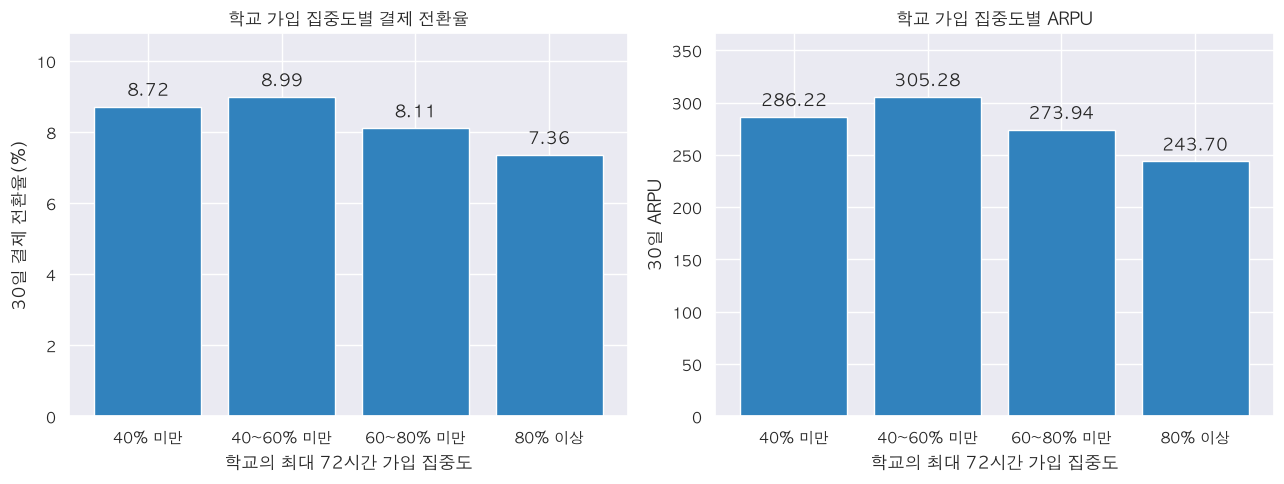

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in [
    (axes[0], '30일 결제 전환율(%)', '학교 가입 집중도별 결제 전환율'),
    (axes[1], '30일 ARPU', '학교 가입 집중도별 ARPU'),
]:
    values = concentration_payment_summary[metric]

    bars = ax.bar(
        concentration_payment_summary['집중도 구간'].astype(str),
        values,
        color='#3182bd',
    )

    ax.bar_label(
        bars,
        labels=[
            f'{value:,.2f}' if pd.notna(value) else ''
            for value in values
        ],
        padding=4,
    )

    ax.set_title(title)
    ax.set_xlabel('학교의 최대 72시간 가입 집중도')
    ax.set_ylabel(metric)
    ax.margins(y=0.2)

fig.tight_layout()
plt.show()

# 학교급 나눠서 추가

In [45]:
school_types = (
    df[['school_id', 'school_type']]
    .dropna(subset=['school_id'])
    .drop_duplicates()
)

if school_types['school_id'].duplicated().any():
    raise ValueError('같은 학교에 여러 school_type이 연결되어 있습니다.')

school_payment_by_type = school_payment_comparison.merge(
    school_types,
    on='school_id',
    how='left',
    validate='one_to_one',
)

school_payment_by_type['학교급'] = (
    school_payment_by_type['school_type']
    .map({'M': '중학교', 'H': '고등학교'})
    .fillna('미상')
)

In [46]:
type_concentration_summary = (
    school_payment_by_type
    .groupby(['학교급', '집중도 구간'], observed=True)
    .agg(
        학교수=('school_id', 'nunique'),
        관찰가능가입자수=('관찰가능가입자수', 'sum'),
        결제자수_30일=('결제자수_30일', 'sum'),
        결제금액_30일=('결제금액_30일', 'sum'),
    )
    .reset_index()
)

# 앞서 정의한 함수 재사용
type_concentration_summary = add_payment_metrics(
    type_concentration_summary
)

for school_type in ['중학교', '고등학교', '미상']:
    result = type_concentration_summary.loc[
        type_concentration_summary['학교급'].eq(school_type)
    ]

    if not result.empty:
        print(school_type)
        display(result.round(2))

중학교


,학교급,집중도 구간,학교수,관찰가능가입자수,결제자수_30일,결제금액_30일,30일 결제 전환율(%),30일 ARPU,30일 ARPPU
4,중학교,40% 미만,225,24132,1851,6081600,7.67,252.01,3285.58
5,중학교,40~60% 미만,676,97176,7047,23624100,7.25,243.11,3352.36
6,중학교,60~80% 미만,728,128022,8253,27063000,6.45,211.39,3279.17
7,중학교,80% 이상,226,35599,2041,6077000,5.73,170.71,2977.46


고등학교


,학교급,집중도 구간,학교수,관찰가능가입자수,결제자수_30일,결제금액_30일,30일 결제 전환율(%),30일 ARPU,30일 ARPPU
0,고등학교,40% 미만,408,59435,5433,17837200,9.14,300.11,3283.12
1,고등학교,40~60% 미만,811,138639,14149,48366300,10.21,348.87,3418.35
2,고등학교,60~80% 미만,695,144467,13846,47582700,9.58,329.37,3436.57
3,고등학교,80% 이상,127,27768,2622,9365700,9.44,337.28,3571.97


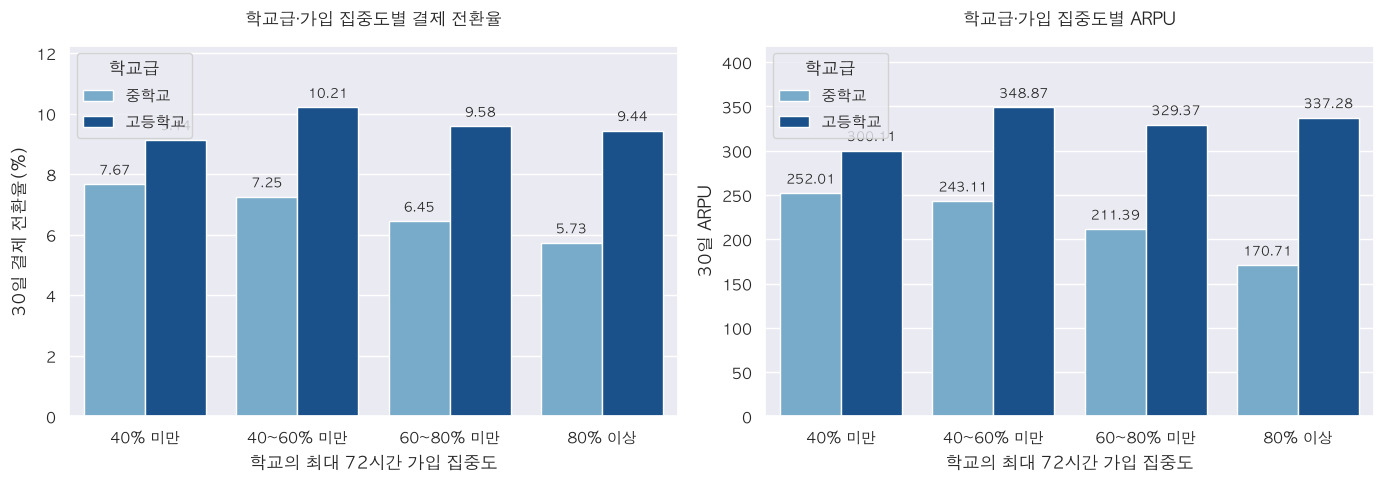

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

concentration_order = [
    '40% 미만',
    '40~60% 미만',
    '60~80% 미만',
    '80% 이상',
]

plot_data = type_concentration_summary.loc[
    type_concentration_summary['학교급'].isin(['중학교', '고등학교'])
]

for ax, metric, title in [
    (axes[0], '30일 결제 전환율(%)', '학교급·가입 집중도별 결제 전환율'),
    (axes[1], '30일 ARPU', '학교급·가입 집중도별 ARPU'),
]:
    sns.barplot(
        data=plot_data,
        x='집중도 구간',
        y=metric,
        hue='학교급',
        order=concentration_order,
        hue_order=['중학교', '고등학교'],
        palette=['#6baed6', '#08519c'],
        errorbar=None,
        ax=ax,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f'{value:,.2f}' if pd.notna(value) else ''
                for value in container.datavalues
            ],
            padding=4,
            fontsize=9,
        )

    ax.set_title(title, pad=15)
    ax.set_xlabel('학교의 최대 72시간 가입 집중도')
    ax.set_ylabel(metric)
    ax.legend(title='학교급')
    ax.margins(y=0.2)

fig.tight_layout()
plt.show()

학교급별로 구분한 결과, 중학교에서는 가입 집중도가 높을수록 30일 결제 전환율과 ARPU가 낮아지는 관계가 관찰되었다. 반면 고등학교는 40~60% 구간에서 가장 높은 성과를 보였으나, 높은 집중도 구간에서도 상대적으로 높은 결제 성과를 유지했다. 따라서 가입 집중도와 결제 성과의 관계는 학교급에 따라 다르게 나타나며, 전체 학교를 합산한 결과만으로 해석하기 어렵다.

# 유저 가입이 이루어지는 임계치 확인

* 혼자 단편적으로 쓸 수 있는 앱이 아니기 떄문에, 특정 수의 유저가 가입되어서 서비스를 안정적으로 운영이 가능한 시점에 유저 가입이 지속적으로 안정 될것으로 생각됩니다.
* 따라서 날짜별로 누적 유저 수를 확인하여, 변화가 급격한 시점이 유저 가입 폭발의 임계치로 추정해볼 수 있습니다.

In [48]:
# 기존 가입 시각과 시간대 유지
signup_steps = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .sort_values(['group_id', 'signup_date'], kind='stable')
    .drop_duplicates(['group_id', 'user_id'], keep='first')
    .copy()
)

# 각 학급의 몇 번째 가입자인지 계산
signup_steps['가입 순번'] = (
    signup_steps.groupby('group_id').cumcount() + 1
)

# 직전 가입자와의 시간 차이
signup_steps['경과시간(시간)'] = (
    signup_steps.groupby('group_id')['signup_date']
    .diff()
    .dt.total_seconds()
    .div(3600)
)

# 두 번째 가입부터 15번째 가입까지
observed_steps = signup_steps.loc[
    signup_steps['가입 순번'].between(2, 15)
]

step_summary = (
    observed_steps.groupby('가입 순번')
    .agg(
        관측학급수=('group_id', 'nunique'),
        평균경과시간=('경과시간(시간)', 'mean'),
        중앙경과시간=('경과시간(시간)', 'median'),
    )
    .reindex(range(2, 16))
    .rename_axis('도달 인원')
    .reset_index()
)

step_summary['관측학급수'] = (
    step_summary['관측학급수'].fillna(0).astype(int)
)

step_summary['가입 단계'] = step_summary['도달 인원'].map(
    lambda n: f'{n - 1}→{n}명'
)

display(
    step_summary[
        ['가입 단계', '관측학급수', '평균경과시간', '중앙경과시간']
    ].round(2)
)

,가입 단계,관측학급수,평균경과시간,중앙경과시간
0,1→2명,68560,77.09,17.02
1,2→3명,61881,46.44,6.15
2,3→4명,56956,37.02,4.07
3,4→5명,52810,33.54,3.53
4,5→6명,48975,32.98,3.48
5,6→7명,45279,32.49,3.69
6,7→8명,41511,38.54,4.24
7,8→9명,37555,43.77,4.63
8,9→10명,33615,47.54,5.51
9,10→11명,29476,57.74,6.66


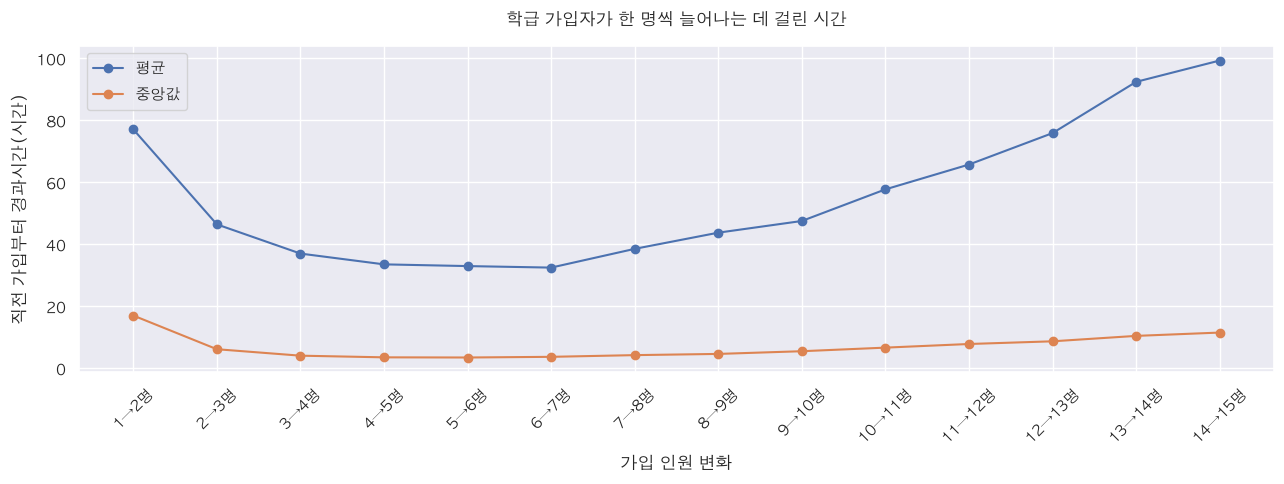

In [49]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    step_summary['가입 단계'],
    step_summary['평균경과시간'],
    marker='o',
    label='평균',
)

ax.plot(
    step_summary['가입 단계'],
    step_summary['중앙경과시간'],
    marker='o',
    label='중앙값',
)

ax.set_title('학급 가입자가 한 명씩 늘어나는 데 걸린 시간', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('직전 가입부터 경과시간(시간)')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

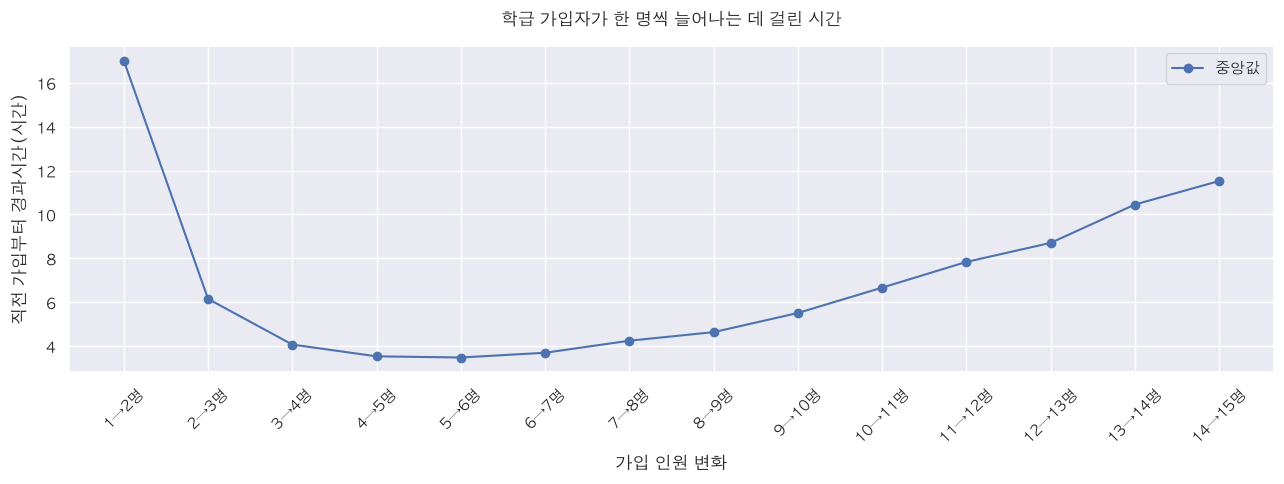

In [50]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    step_summary['가입 단계'],
    step_summary['중앙경과시간'],
    marker='o',
    label='중앙값',
)

ax.set_title('학급 가입자가 한 명씩 늘어나는 데 걸린 시간', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('직전 가입부터 경과시간(시간)')
ax.legend()
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

약 5명 전후로 추가 가입 속도가 빨라졌다가 둔화되는 양상이 관찰되었다. 이는 초기 이용에 필요한 인원이 확보된 후 추가 초대 동기가 낮아지는 현상일 가능성이 있다. 다만 이용에 필요한 최소 인원과 실제 초대 행동은 검증되지 않았으며, 친한 친구 집단의 초기 가입이나 분석 대상 학급의 구성 차이로도 설명될 수 있다.

In [51]:
MIN_FINAL_USERS = 15

fixed_steps = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .sort_values(['group_id', 'signup_date'], kind='stable')
    .drop_duplicates(['group_id', 'user_id'], keep='first')
    .copy()
)

group_sizes = fixed_steps.groupby('group_id')['user_id'].nunique()
fixed_group_ids = group_sizes[
    group_sizes >= MIN_FINAL_USERS
].index

fixed_steps = fixed_steps.loc[
    fixed_steps['group_id'].isin(fixed_group_ids)
].copy()

fixed_steps['가입 순번'] = (
    fixed_steps.groupby('group_id').cumcount() + 1
)

fixed_steps['경과시간(시간)'] = (
    fixed_steps.groupby('group_id')['signup_date']
    .diff()
    .dt.total_seconds()
    .div(3600)
)

fixed_steps = fixed_steps.loc[
    fixed_steps['가입 순번'].between(2, 15)
]

print(f'분석 대상: 가입자 15명 이상인 학급 {len(fixed_group_ids):,}개')

분석 대상: 가입자 15명 이상인 학급 14,152개


,도달 인원,관측학급수,평균경과시간,중앙경과시간,가입 단계
0,2,14152,33.66,5.44,1→2명
1,3,14152,15.26,1.58,2→3명
2,4,14152,10.16,1.13,3→4명
3,5,14152,8.76,1.11,4→5명
4,6,14152,7.76,1.13,5→6명
5,7,14152,7.10,1.14,6→7명
6,8,14152,6.98,1.25,7→8명
7,9,14152,7.47,1.37,8→9명
8,10,14152,7.87,1.62,9→10명
9,11,14152,9.25,2.04,10→11명


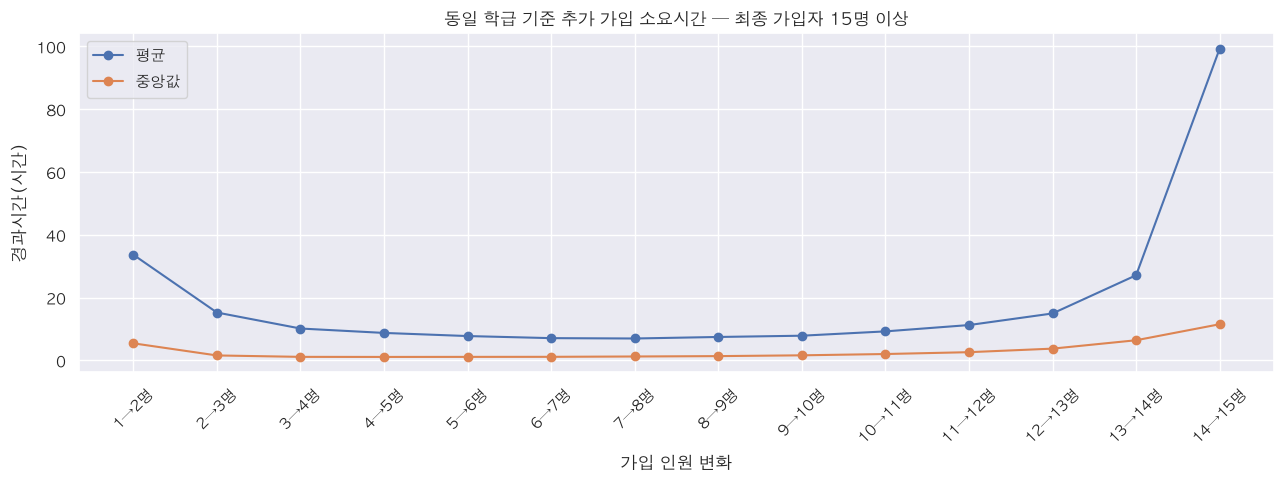

In [52]:
fixed_step_summary = (
    fixed_steps.groupby('가입 순번')
    .agg(
        관측학급수=('group_id', 'nunique'),
        평균경과시간=('경과시간(시간)', 'mean'),
        중앙경과시간=('경과시간(시간)', 'median'),
    )
    .reindex(range(2, 16))
    .rename_axis('도달 인원')
    .reset_index()
)

fixed_step_summary['가입 단계'] = (
    fixed_step_summary['도달 인원']
    .map(lambda n: f'{n - 1}→{n}명')
)

display(fixed_step_summary.round(2))

fig, ax = plt.subplots(figsize=(13, 5))

for column, label in [
    ('평균경과시간', '평균'),
    ('중앙경과시간', '중앙값'),
]:
    ax.plot(
        fixed_step_summary['가입 단계'],
        fixed_step_summary[column],
        marker='o',
        label=label,
    )

ax.set_title('동일 학급 기준 추가 가입 소요시간 — 최종 가입자 15명 이상')
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('경과시간(시간)')
ax.tick_params(axis='x', labelrotation=45)
ax.legend()

fig.tight_layout()
plt.show()

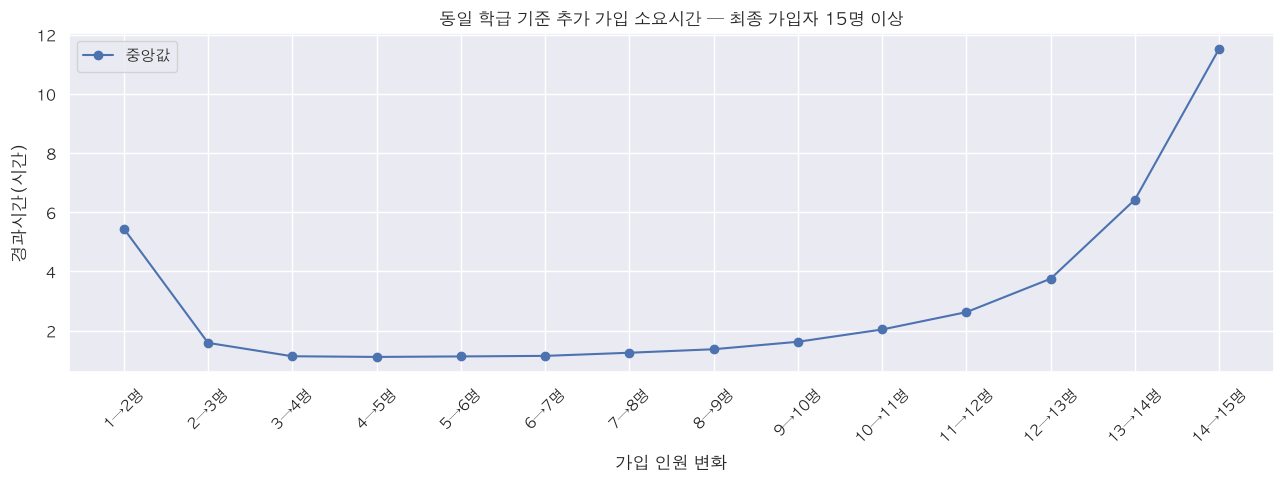

In [53]:
fig, ax = plt.subplots(figsize=(13, 5))

for column, label in [
    ('중앙경과시간', '중앙값'),
]:
    ax.plot(
        fixed_step_summary['가입 단계'],
        fixed_step_summary[column],
        marker='o',
        label=label,
    )

ax.set_title('동일 학급 기준 추가 가입 소요시간 — 최종 가입자 15명 이상')
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('경과시간(시간)')
ax.tick_params(axis='x', labelrotation=45)
ax.legend()

fig.tight_layout()
plt.show()

In [54]:
monthly_area = area_df.copy()

monthly_area['가입월'] = (
    pd.to_datetime(monthly_area['signup_date'])
    .dt.strftime('%Y-%m')
)


def monthly_region_top3(data, region_cols):
    # 월 전체 가입자 수
    monthly_total = (
        data.groupby('가입월')['user_id']
        .nunique()
        .reset_index(name='월전체가입자수')
    )

    # 지역별 전체 기간 가입자 수
    region_total = (
        data.groupby(region_cols)['user_id']
        .nunique()
        .reset_index(name='지역전체가입자수')
    )

    # 월 × 지역별 가입자 수
    summary = (
        data.groupby(['가입월'] + region_cols)['user_id']
        .nunique()
        .reset_index(name='월지역가입자수')
        .merge(
            monthly_total,
            on='가입월',
            validate='many_to_one',
        )
        .merge(
            region_total,
            on=region_cols,
            validate='many_to_one',
        )
    )

    summary['해당 월 내 비중(%)'] = (
        summary['월지역가입자수']
        / summary['월전체가입자수'] * 100
    ).round(2)

    summary['지역 전체 대비 비중(%)'] = (
        summary['월지역가입자수']
        / summary['지역전체가입자수'] * 100
    ).round(2)

    # 가입자 수 내림차순, 동률은 지역명 순으로 정확히 3개 선택
    top3 = (
        summary.sort_values(
            ['가입월', '월지역가입자수'] + region_cols,
            ascending=[True, False] + [True] * len(region_cols),
        )
        .groupby('가입월', sort=False)
        .head(3)
        .copy()
    )

    top3['순위'] = top3.groupby('가입월').cumcount() + 1

    return top3[
        ['가입월', '순위'] + region_cols
        + [
            '월지역가입자수',
            '월전체가입자수',
            '해당 월 내 비중(%)',
            '지역전체가입자수',
            '지역 전체 대비 비중(%)',
        ]
    ].reset_index(drop=True)

In [55]:
monthly_sido_top3 = monthly_region_top3(
    monthly_area,
    region_cols=['시도'],
)

display(monthly_sido_top3)

,가입월,순위,시도,월지역가입자수,월전체가입자수,해당 월 내 비중(%),지역전체가입자수,지역 전체 대비 비중(%)
0,2023-03,1,충청남도,21,22,95.45,42776,0.05
1,2023-03,2,경기도,1,22,4.55,191707,0.00
2,2023-04,1,서울특별시,10148,19030,53.33,74521,13.62
3,2023-04,2,경기도,4799,19030,25.22,191707,2.50
4,2023-04,3,충청남도,2138,19030,11.23,42776,5.00
5,2023-05,1,경기도,183067,635478,28.81,191707,95.49
6,2023-05,2,서울특별시,62803,635478,9.88,74521,84.28
7,2023-05,3,부산광역시,40028,635478,6.30,41087,97.42
8,2023-06,1,경상북도,4392,16732,26.25,30265,14.51
9,2023-06,2,경기도,2366,16732,14.14,191707,1.23


In [56]:
monthly_city_top3 = monthly_region_top3(
    monthly_area,
    region_cols=['시도', '시군구'],
)

display(monthly_city_top3)

,가입월,순위,시도,시군구,월지역가입자수,월전체가입자수,해당 월 내 비중(%),지역전체가입자수,지역 전체 대비 비중(%)
0,2023-03,1,충청남도,천안시,21,22,95.45,11465,0.18
1,2023-03,2,경기도,군포시,1,22,4.55,1226,0.08
2,2023-04,1,서울특별시,송파구,3927,19030,20.64,5931,66.21
3,2023-04,2,경기도,성남시,2919,19030,15.34,10657,27.39
4,2023-04,3,서울특별시,강동구,2072,19030,10.89,3354,61.78
5,2023-05,1,경기도,수원시,19346,635478,3.04,19764,97.89
6,2023-05,2,경기도,고양시,17298,635478,2.72,17530,98.68
7,2023-05,3,경기도,용인시,17180,635478,2.70,17524,98.04
8,2023-06,1,경상북도,포항시,1096,16732,6.55,2484,44.12
9,2023-06,2,경상북도,영주시,945,16732,5.65,1607,58.81


In [57]:
def plot_monthly_region_top3(data, region_cols, title):
    if data.empty:
        print('표시할 데이터가 없습니다.')
        return

    months = sorted(data['가입월'].unique())
    ncols = 3
    nrows = (len(months) + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(21, nrows * 3.5),
        squeeze=False,
        sharex=True,
    )

    # 모든 월에 같은 비중 축 적용
    xmax = max(1, data['해당 월 내 비중(%)'].max()) * 1.15

    for ax, month in zip(axes.flat, months):
        monthly = (
            data.loc[data['가입월'].eq(month)]
            .sort_values('순위')
            .copy()
        )

        region_names = (
            monthly[region_cols].astype(str).agg(' '.join, axis=1)
        )

        labels = [
            (
                f"{name} · {int(row['월지역가입자수']):,}명\n"
                f"월 내 {row['해당 월 내 비중(%)']:.1f}%"
                f" / 지역 전체 대비 {row['지역 전체 대비 비중(%)']:.1f}%"
            )
            for name, (_, row) in zip(region_names, monthly.iterrows())
        ]

        positions = list(range(len(monthly)))

        ax.barh(
            positions,
            monthly['해당 월 내 비중(%)'],
            color=['#2171b5', '#6baed6', '#bdd7e7'][:len(monthly)],
            height=0.55,
        )

        ax.set_yticks(positions)
        ax.set_yticklabels(labels, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlim(0, xmax)

        monthly_total = int(monthly['월전체가입자수'].iloc[0])
        ax.set_title(
            f'{month} | 전체 가입자 {monthly_total:,}명',
            fontsize=11,
            pad=12,
        )

        ax.set_xlabel('해당 월 내 비중(%)', fontsize=9)
        ax.grid(axis='y', visible=False)
        ax.set_axisbelow(True)

    for ax in axes.flat[len(months):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=16, y=1.01)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

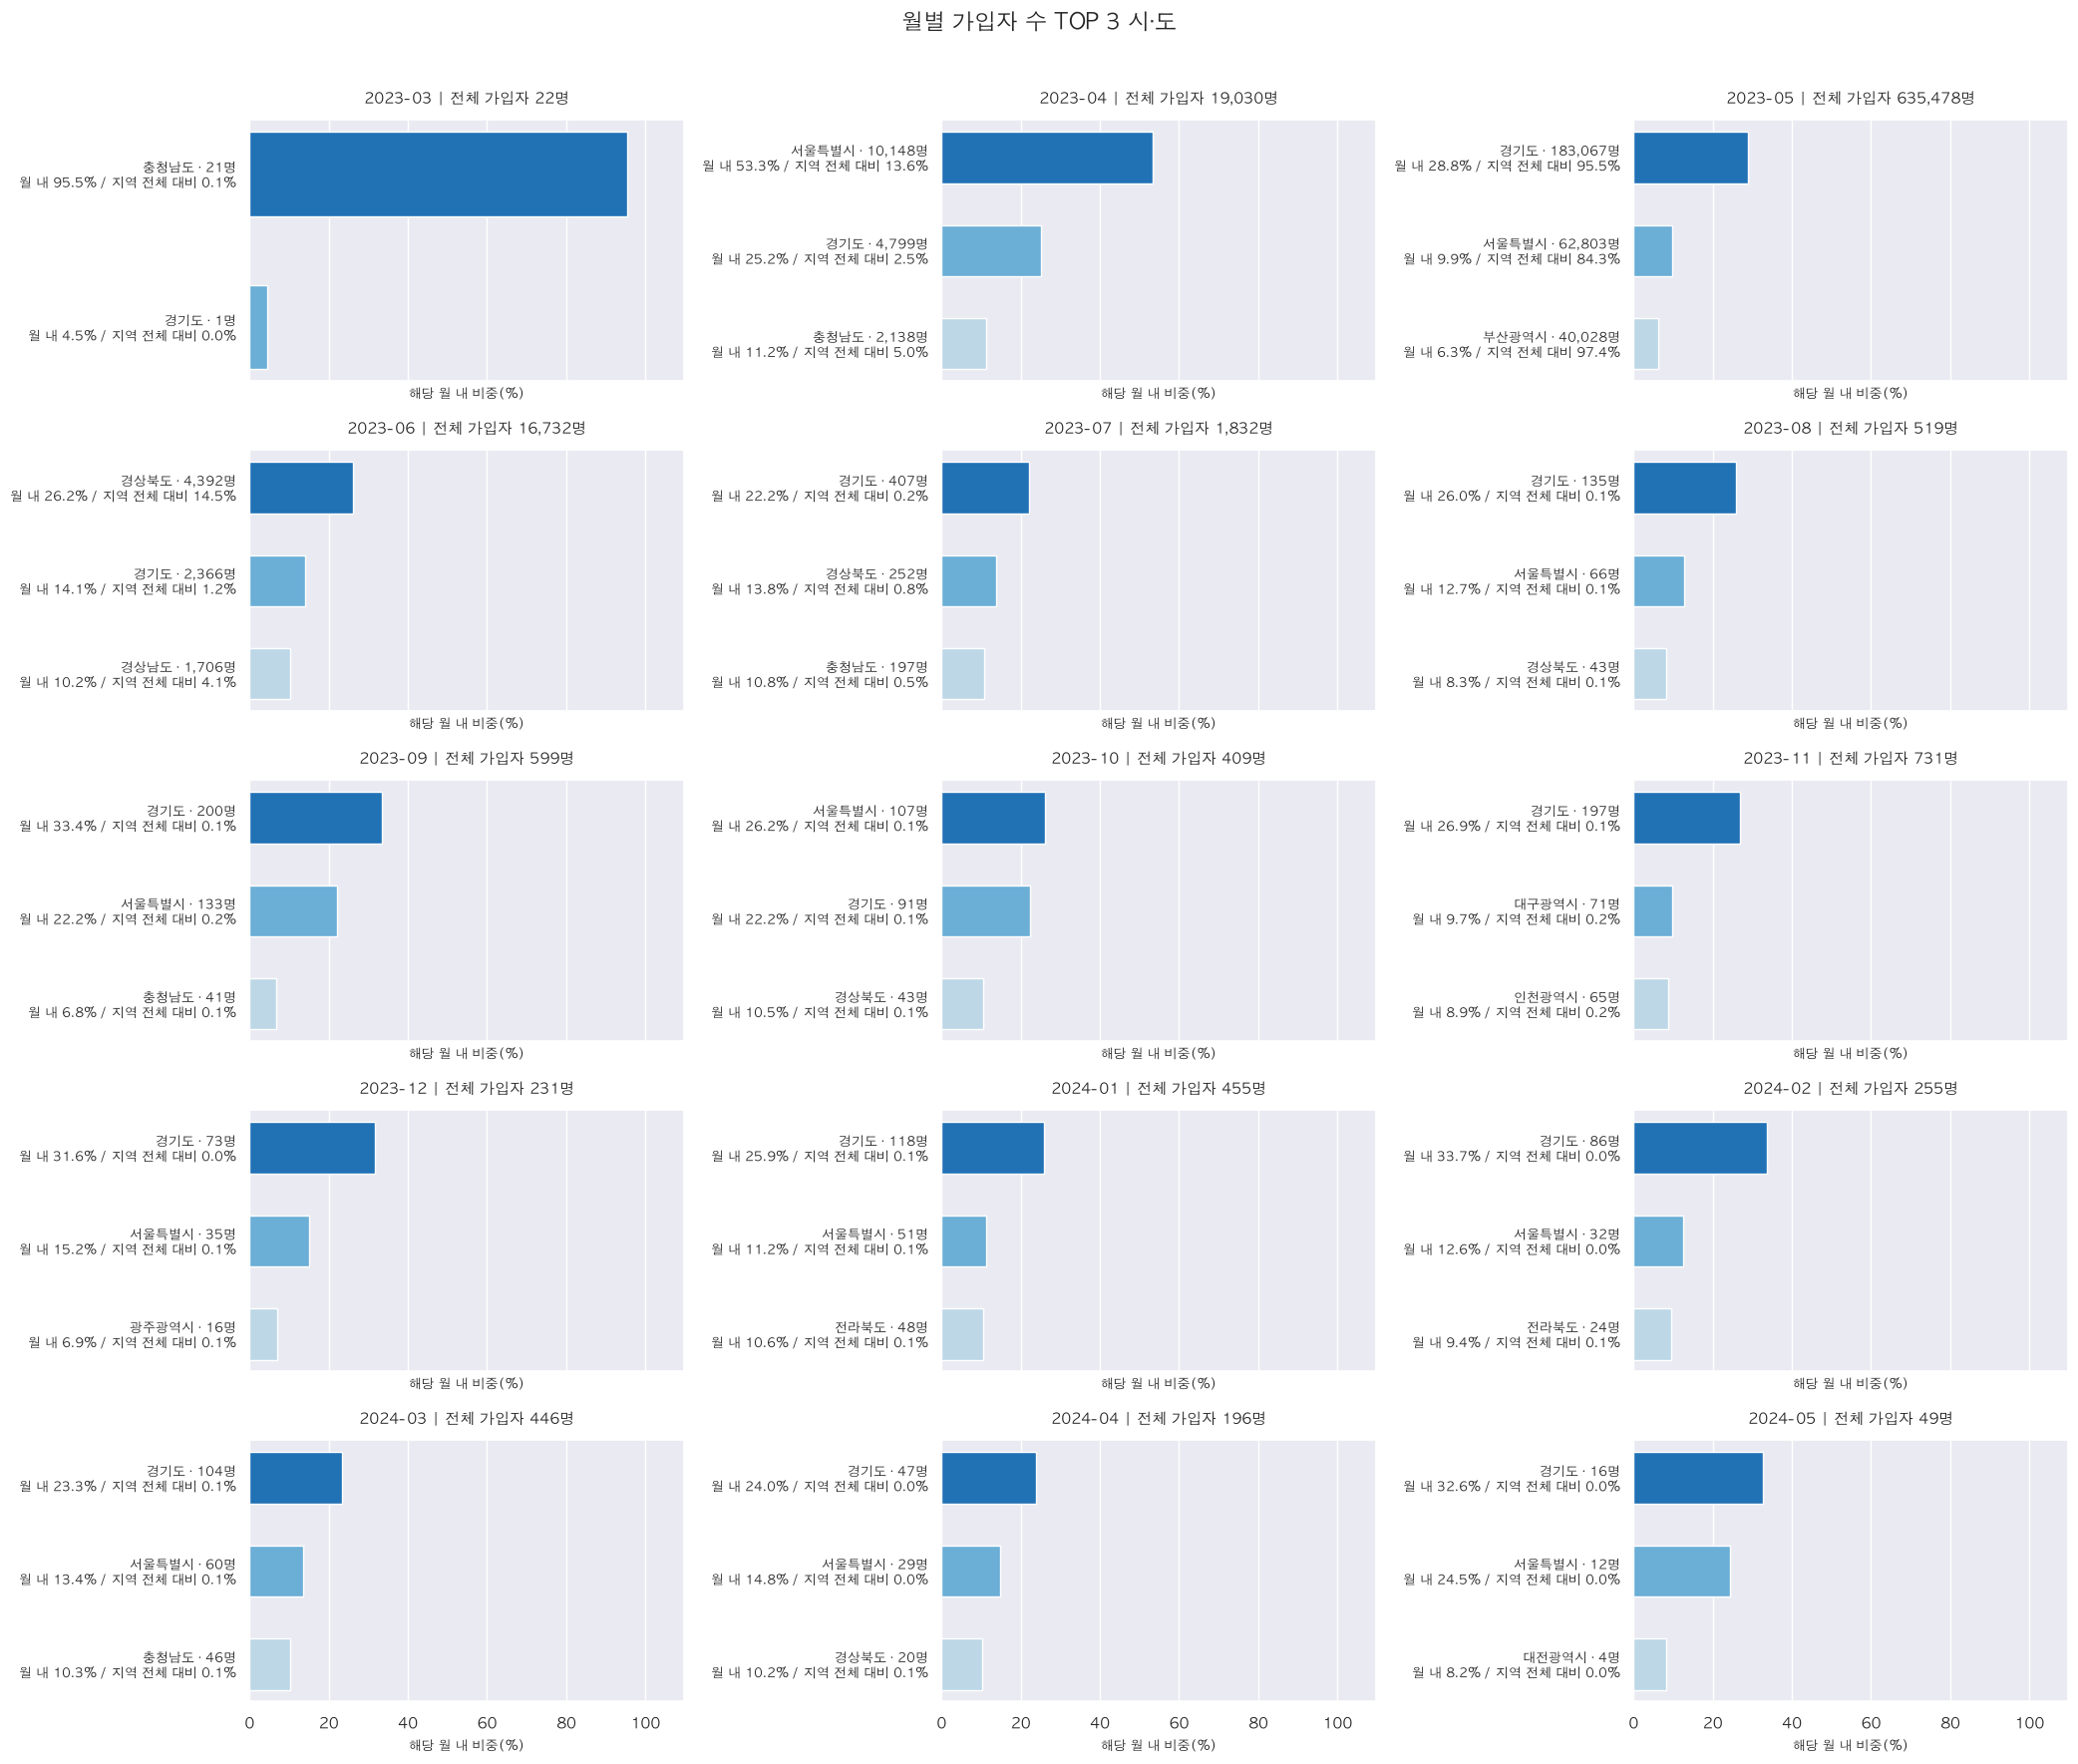

In [58]:
plot_monthly_region_top3(
    monthly_sido_top3,
    region_cols=['시도'],
    title='월별 가입자 수 TOP 3 시·도',
)

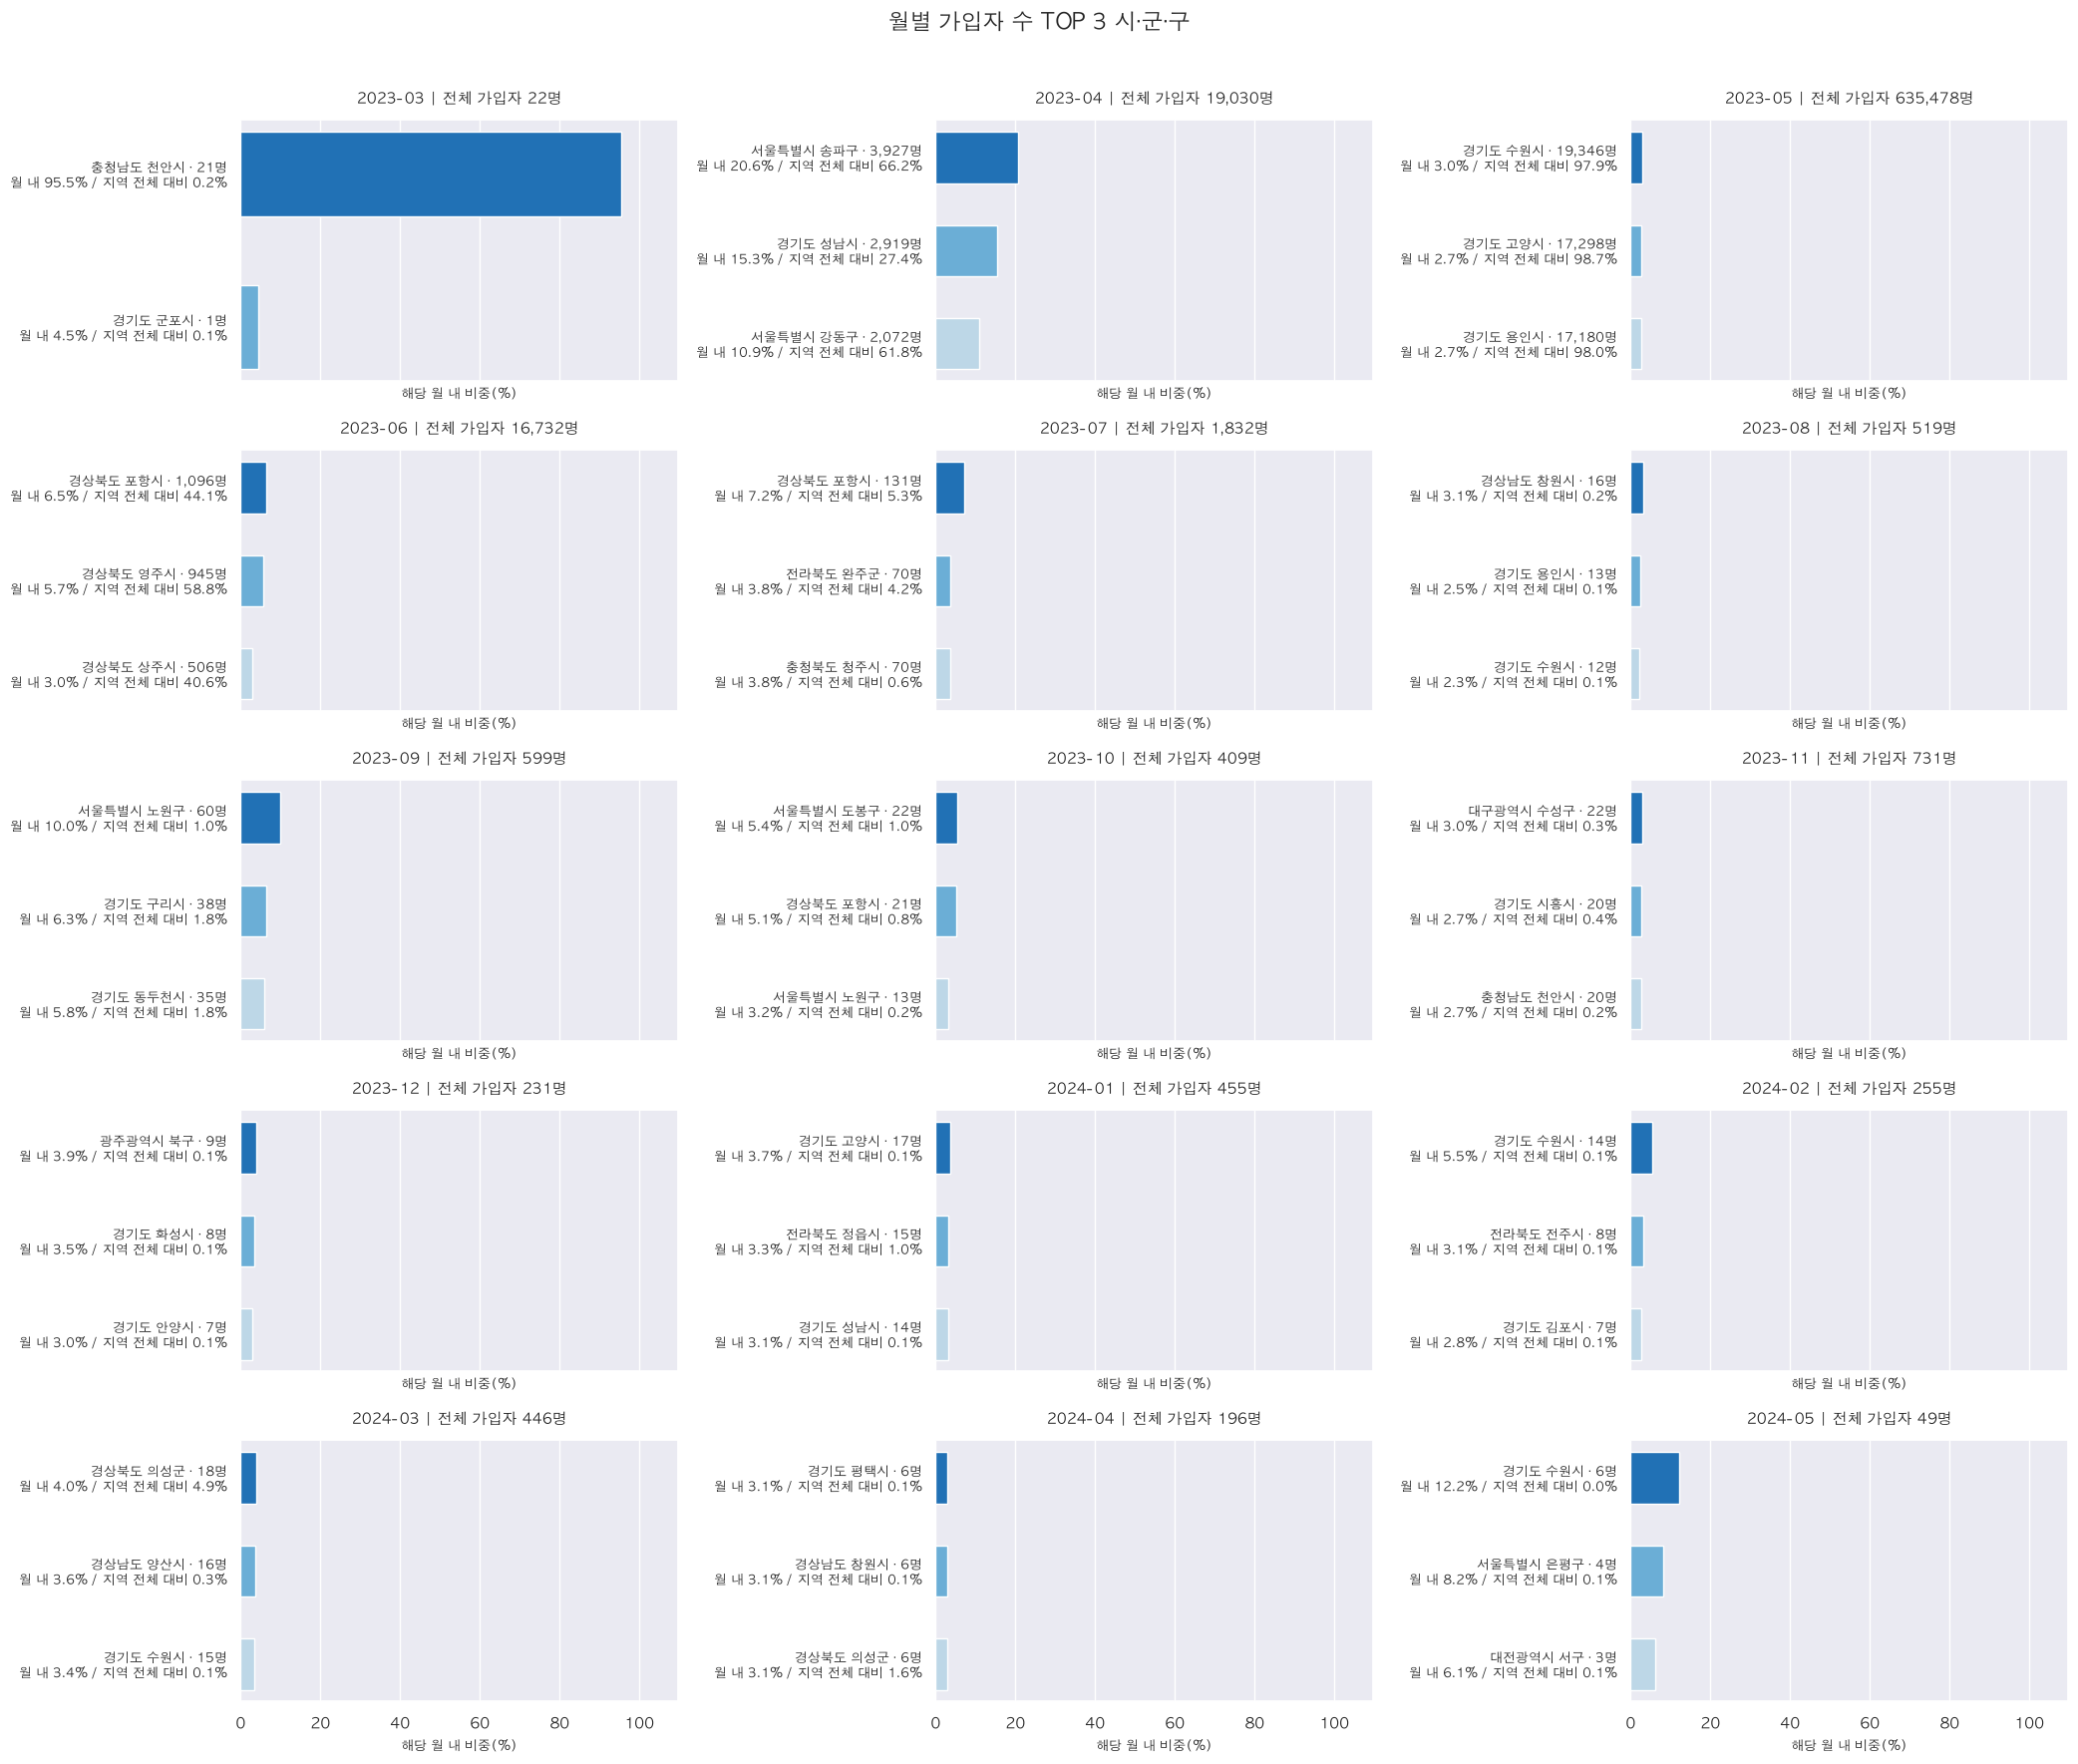

In [59]:
plot_monthly_region_top3(
    monthly_city_top3,
    region_cols=['시도', '시군구'],
    title='월별 가입자 수 TOP 3 시·군·구',
)

In [60]:
# 유저별 최초 가입 시각
signup_times = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id')['signup_date']
    .min()
)

# 집계용 시각만 한국 시간으로 변환
signup_hour = (
    pd.to_datetime(signup_times, utc=True)
    .dt.tz_convert('Asia/Seoul')
    .dt.hour
)

hourly_signup = (
    signup_hour.value_counts()
    .reindex(range(24), fill_value=0)
    .rename_axis('가입 시간대')
    .reset_index(name='가입자 수')
)

hourly_signup['비중(%)'] = (
    (hourly_signup['가입자 수'] / len(signup_times) * 100).round(2)
    if len(signup_times) else float('nan')
)

display(hourly_signup)

,가입 시간대,가입자 수,비중(%)
0,0,44756,6.61
1,1,19410,2.87
2,2,6236,0.92
3,3,2226,0.33
4,4,1076,0.16
5,5,1060,0.16
6,6,3481,0.51
7,7,13576,2.01
8,8,24506,3.62
9,9,14525,2.15


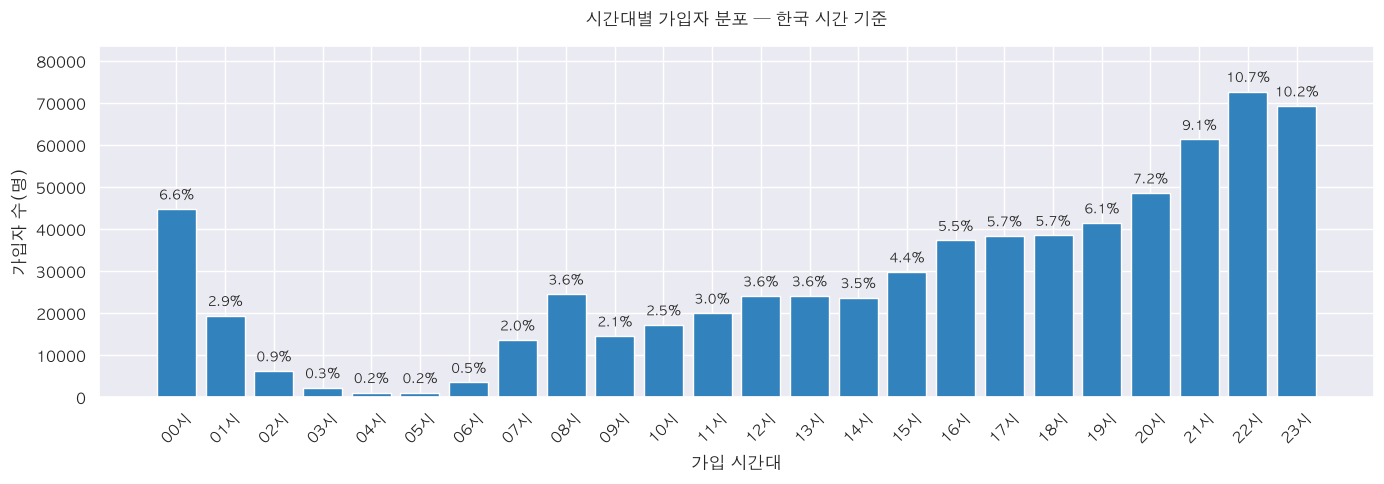

In [61]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    hourly_signup['가입 시간대'],
    hourly_signup['가입자 수'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{share:.1f}%' if pd.notna(share) else ''
        for share in hourly_signup['비중(%)']
    ],
    padding=4,
    fontsize=9,
)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{hour:02d}시' for hour in range(24)], rotation=45)
ax.set_title('시간대별 가입자 분포 — 한국 시간 기준', pad=15)
ax.set_xlabel('가입 시간대')
ax.set_ylabel('가입자 수(명)')
ax.margins(y=0.15)

fig.tight_layout()
plt.show()

In [62]:
signup_times_utc = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id')['signup_date']
    .min()
)

hourly_signup_utc = (
    pd.to_datetime(signup_times_utc, utc=True)
    .dt.hour
    .value_counts()
    .reindex(range(24), fill_value=0)
    .rename_axis('가입 시간대')
    .reset_index(name='가입자 수')
)

hourly_signup_utc['비중(%)'] = (
    (hourly_signup_utc['가입자 수'] / len(signup_times_utc) * 100).round(2)
    if len(signup_times_utc) else float('nan')
)

display(hourly_signup_utc)

,가입 시간대,가입자 수,비중(%)
0,0,14525,2.15
1,1,17175,2.54
2,2,19972,2.95
3,3,24069,3.56
4,4,24095,3.56
5,5,23675,3.50
6,6,29763,4.40
7,7,37283,5.51
8,8,38358,5.67
9,9,38488,5.69


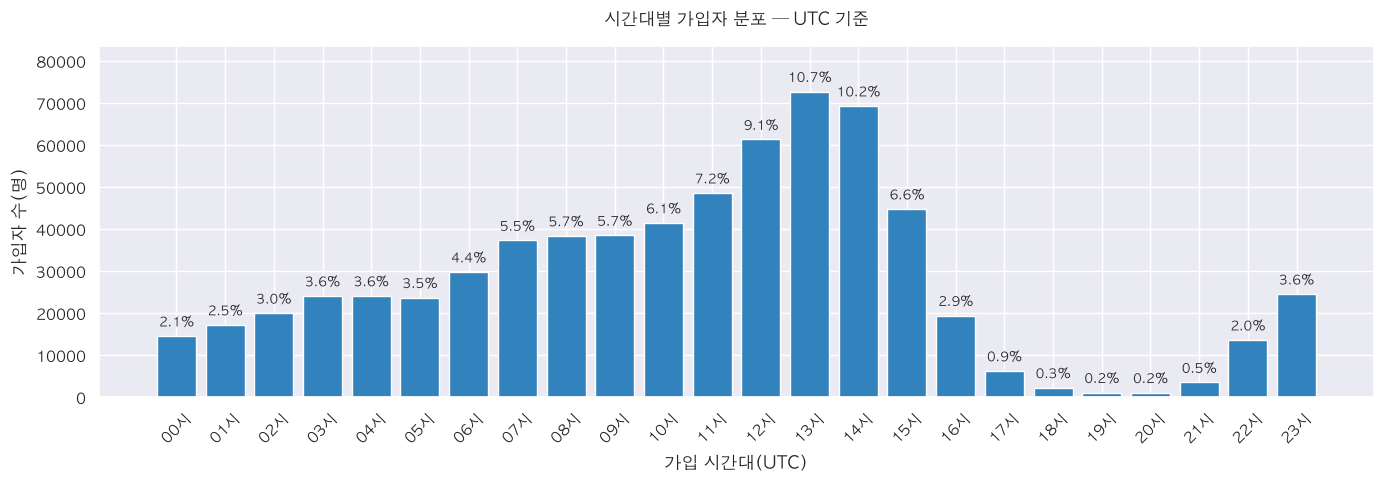

In [63]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    hourly_signup_utc['가입 시간대'],
    hourly_signup_utc['가입자 수'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{share:.1f}%' if pd.notna(share) else ''
        for share in hourly_signup_utc['비중(%)']
    ],
    padding=4,
    fontsize=9,
)

ax.set_xticks(range(24))
ax.set_xticklabels([f'{hour:02d}시' for hour in range(24)], rotation=45)
ax.set_title('시간대별 가입자 분포 — UTC 기준', pad=15)
ax.set_xlabel('가입 시간대(UTC)')
ax.set_ylabel('가입자 수(명)')
ax.margins(y=0.15)

fig.tight_layout()
plt.show()

In [64]:
# 유저별 최초 가입 시각
monthly_hour_data = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id', as_index=False)['signup_date']
    .min()
)

signup_datetime = (
    pd.to_datetime(monthly_hour_data['signup_date'], utc=True)
    .dt.tz_convert('Asia/Seoul')
)

monthly_hour_data['가입월'] = signup_datetime.dt.strftime('%Y-%m')
monthly_hour_data['가입시간'] = signup_datetime.dt.hour

monthly_hour_data['가입월'] = signup_datetime.dt.strftime('%Y-%m')
monthly_hour_data['가입시간'] = signup_datetime.dt.hour

# 월 × 시간별 가입자 수
monthly_hour_counts = (
    monthly_hour_data.groupby(['가입월', '가입시간'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
    .sort_index()
)

# 각 월의 합계가 100%가 되도록 계산
monthly_hour_share = (
    monthly_hour_counts
    .div(monthly_hour_counts.sum(axis=1), axis=0)
    * 100
)

display(monthly_hour_counts)

가입시간,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
가입월,,,,,,,,,,,,,,,,,,,,,
2023-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2023-04,1481,875,359,130,49,35,83,201,299,375,...,606,821,721,714,862,937,1131,1506,2055,2359
2023-05,41621,17664,5463,1922,949,960,3291,12999,23432,13735,...,22240,27850,35192,36249,36105,39074,45779,57878,68617,64917
2023-06,1266,652,299,124,45,38,76,294,638,288,...,610,804,1070,1075,1137,1075,1197,1422,1552,1494
2023-07,111,61,25,12,7,6,7,26,67,52,...,90,100,103,95,127,109,136,147,147,144
2023-08,35,22,20,10,3,4,6,8,10,11,...,13,21,29,29,37,34,55,30,36,34
2023-09,38,24,11,3,1,3,5,5,10,9,...,19,30,38,47,44,45,59,46,48,43
2023-10,34,16,11,5,3,2,1,6,9,7,...,17,27,17,20,29,25,21,42,35,33
2023-11,44,25,10,4,0,2,4,9,17,12,...,21,30,29,35,60,48,82,68,87,73


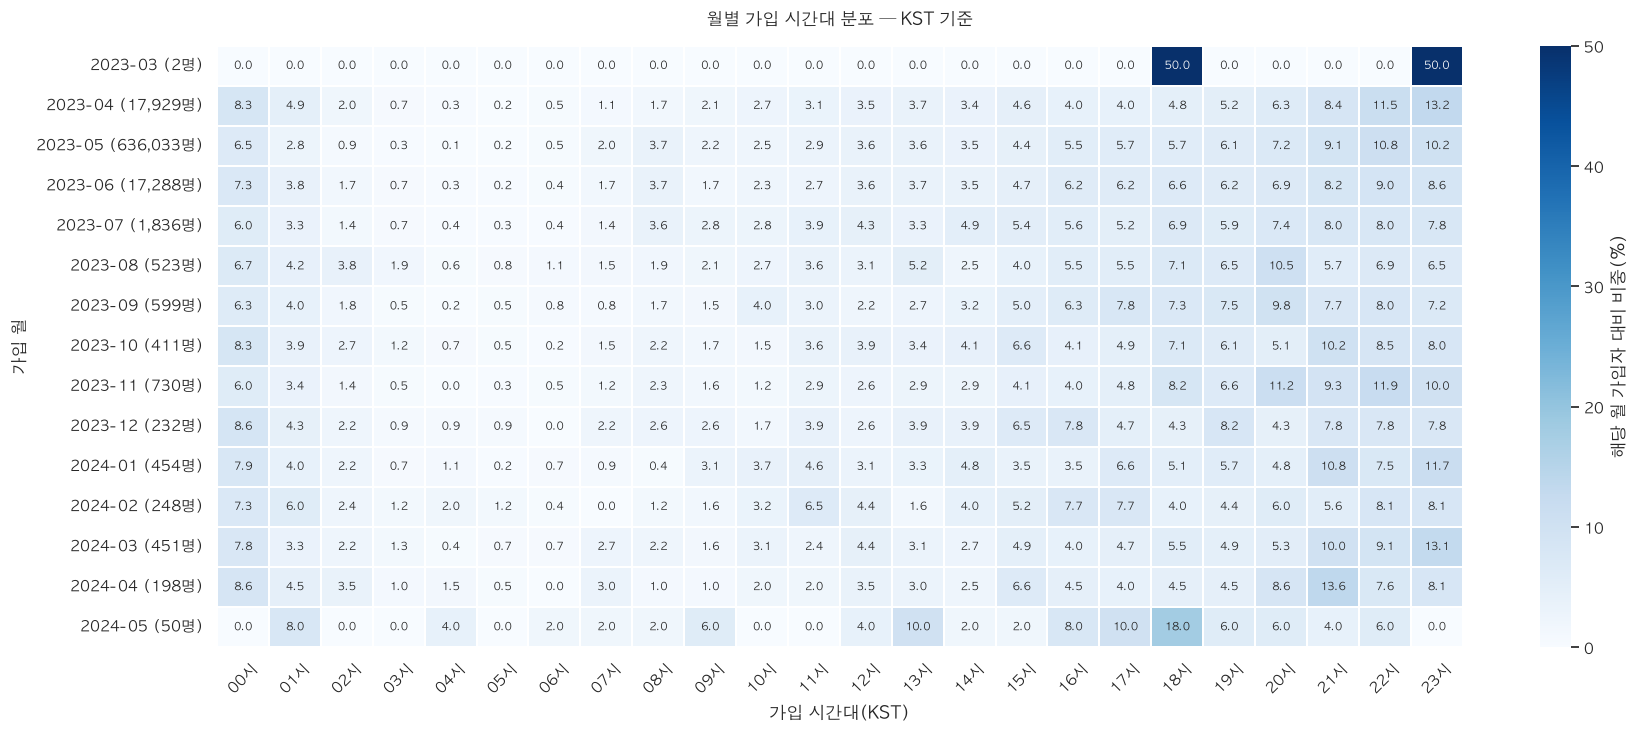

In [65]:
fig, ax = plt.subplots(
    figsize=(18, max(5, len(monthly_hour_share) * 0.5))
)

sns.heatmap(
    monthly_hour_share,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0,
    linewidths=0.3,
    annot_kws={'fontsize': 8},
    cbar_kws={'label': '해당 월 가입자 대비 비중(%)'},
    ax=ax,
)

# 월별 표본 규모도 함께 표시
ax.set_yticklabels(
    [
        f'{month} ({int(count):,}명)'
        for month, count in monthly_hour_counts.sum(axis=1).items()
    ],
    rotation=0,
)

ax.set_xticklabels([f'{hour:02d}시' for hour in range(24)], rotation=45)
ax.set_title('월별 가입 시간대 분포 — KST 기준', pad=15)
ax.set_xlabel('가입 시간대(KST)')
ax.set_ylabel('가입 월')

fig.tight_layout()
plt.show()

In [66]:
check = (
    df[['user_id', 'signup_date']]
    .dropna()
    .groupby('user_id', as_index=False)['signup_date']
    .min()
)

check['UTC'] = pd.to_datetime(check['signup_date'], utc=True)
check['KST'] = check['UTC'].dt.tz_convert('Asia/Seoul')

check['UTC월'] = check['UTC'].dt.strftime('%Y-%m')
check['KST월'] = check['KST'].dt.strftime('%Y-%m')

march_users = check.loc[check['UTC월'].eq('2023-03')]

display(
    march_users.groupby('KST월')['user_id']
    .nunique()
    .reset_index(name='가입자 수')
)

display(
    march_users[['user_id', 'UTC', 'KST']]
    .sort_values('UTC')
)

,KST월,가입자 수
0,2023-03,2
1,2023-04,20


,user_id,UTC,KST
0,833024,2023-03-31 09:05:51.903699+00:00,2023-03-31 18:05:51.903699+09:00
1,833041,2023-03-31 14:32:36.425315+00:00,2023-03-31 23:32:36.425315+09:00
2,833112,2023-03-31 15:55:48.870381+00:00,2023-04-01 00:55:48.870381+09:00
3,833113,2023-03-31 15:56:52.300066+00:00,2023-04-01 00:56:52.300066+09:00
4,833154,2023-03-31 15:57:39.008717+00:00,2023-04-01 00:57:39.008717+09:00
5,833201,2023-03-31 15:58:10.987943+00:00,2023-04-01 00:58:10.987943+09:00
6,833202,2023-03-31 15:58:12.136011+00:00,2023-04-01 00:58:12.136011+09:00
7,833203,2023-03-31 15:58:14.619962+00:00,2023-04-01 00:58:14.619962+09:00
8,833210,2023-03-31 15:59:19.383659+00:00,2023-04-01 00:59:19.383659+09:00
9,833294,2023-03-31 16:01:21.096662+00:00,2023-04-01 01:01:21.096662+09:00


In [67]:
# 학급별 고유 가입자 수
group_sizes = (
    df[['group_id', 'user_id']]
    .dropna()
    .groupby('group_id')['user_id']
    .nunique()
)

records = []

for n in range(1, 15):
    reached_n = group_sizes.ge(n).sum()
    reached_next = group_sizes.ge(n + 1).sum()

    records.append({
        '가입 단계': f'{n}→{n + 1}명',
        'N명 이상 학급 수': reached_n,
        'N+1명 이상 학급 수': reached_next,
        '다음 인원 도달률(%)': (
            reached_next / reached_n * 100
            if reached_n else float('nan')
        ),
    })

group_progression = pd.DataFrame(records)

display(group_progression.round(2))

,가입 단계,N명 이상 학급 수,N+1명 이상 학급 수,다음 인원 도달률(%)
0,1→2명,80891,68560,84.76
1,2→3명,68560,61881,90.26
2,3→4명,61881,56956,92.04
3,4→5명,56956,52810,92.72
4,5→6명,52810,48975,92.74
5,6→7명,48975,45279,92.45
6,7→8명,45279,41511,91.68
7,8→9명,41511,37555,90.47
8,9→10명,37555,33615,89.51
9,10→11명,33615,29476,87.69


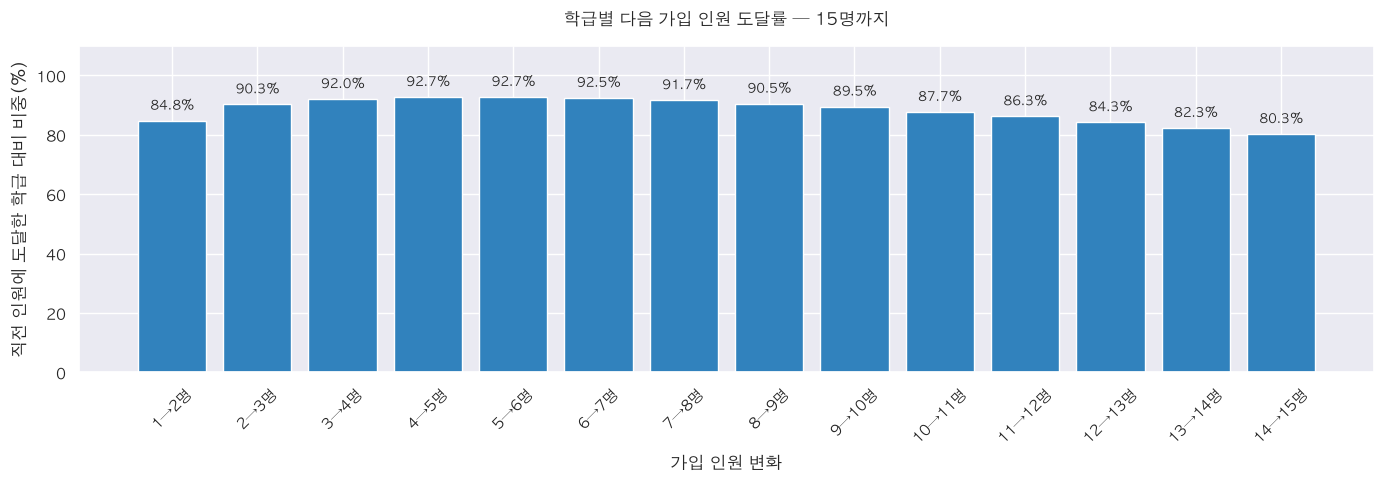

In [68]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    group_progression['가입 단계'],
    group_progression['다음 인원 도달률(%)'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{rate:.1f}%' if pd.notna(rate) else ''
        for rate in group_progression['다음 인원 도달률(%)']
    ],
    padding=5,
    fontsize=9,
)

ax.set_title('학급별 다음 가입 인원 도달률 — 15명까지', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('직전 인원에 도달한 학급 대비 비중(%)')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

In [69]:
# 학급별 고유 가입자 수
group_sizes = (
    df[['group_id', 'user_id']]
    .dropna()
    .groupby('group_id')['user_id']
    .nunique()
)

records = []

for n in range(1, 15):
    reached_n = group_sizes.ge(1).sum()
    reached_next = group_sizes.ge(n + 1).sum()

    records.append({
        '가입 단계': f'{n}→{n + 1}명',
        'N명 이상 학급 수': reached_n,
        'N+1명 이상 학급 수': reached_next,
        '다음 인원 도달률(%)': (
            reached_next / reached_n * 100
            if reached_n else float('nan')
        ),
    })

group_progression = pd.DataFrame(records)

display(group_progression.round(2))

,가입 단계,N명 이상 학급 수,N+1명 이상 학급 수,다음 인원 도달률(%)
0,1→2명,80891,68560,84.76
1,2→3명,80891,61881,76.50
2,3→4명,80891,56956,70.41
3,4→5명,80891,52810,65.29
4,5→6명,80891,48975,60.54
5,6→7명,80891,45279,55.98
6,7→8명,80891,41511,51.32
7,8→9명,80891,37555,46.43
8,9→10명,80891,33615,41.56
9,10→11명,80891,29476,36.44


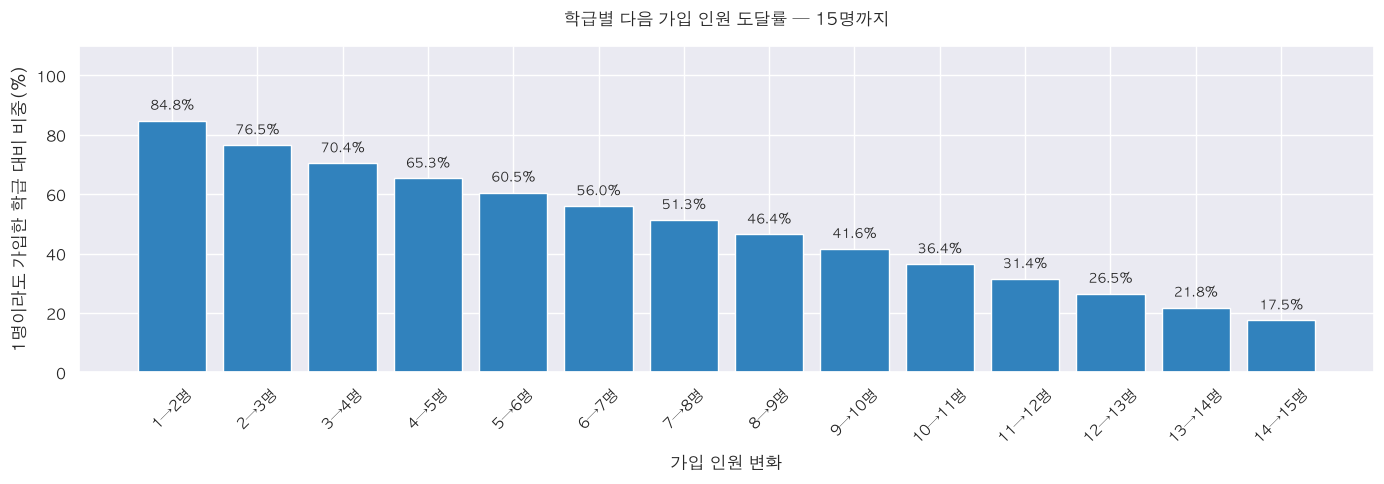

In [70]:
fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    group_progression['가입 단계'],
    group_progression['다음 인원 도달률(%)'],
    color='#3182bd',
)

ax.bar_label(
    bars,
    labels=[
        f'{rate:.1f}%' if pd.notna(rate) else ''
        for rate in group_progression['다음 인원 도달률(%)']
    ],
    padding=5,
    fontsize=9,
)

ax.set_title('학급별 다음 가입 인원 도달률 — 15명까지', pad=15)
ax.set_xlabel('가입 인원 변화')
ax.set_ylabel('1명이라도 가입한 학급 대비 비중(%)')
ax.set_ylim(0, 110)
ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.show()

In [71]:
# UTC datetime 변환 후 KST로 변경하고 YYYY-MM 포맷으로 추출
df['signup_month'] = (
    pd.to_datetime(
        df['signup_date'],
        utc=True,
        errors='coerce'
    )
    .dt.tz_convert('Asia/Seoul')
    .dt.strftime('%Y-%m')
)

# 연월별 유니크 가입자 수 집계
monthly_summary = (
    df.groupby('signup_month')['user_id']
    .nunique()
    .reset_index(name='unique_users')
)

# 실제 전월과 비교하도록 누락된 월도 포함하고 시간순으로 정렬
monthly_summary = (
    monthly_summary
    .set_index('signup_month')
    .reindex(
        pd.period_range(
            monthly_summary['signup_month'].min(),
            monthly_summary['signup_month'].max(),
            freq='M',
        ).astype(str),
        fill_value=0,
    )
    .rename_axis('signup_month')
    .reset_index()
)

print(monthly_summary.head())

  signup_month  unique_users
0      2023-03             2
1      2023-04         17929
2      2023-05        636033
3      2023-06         17288
4      2023-07          1836


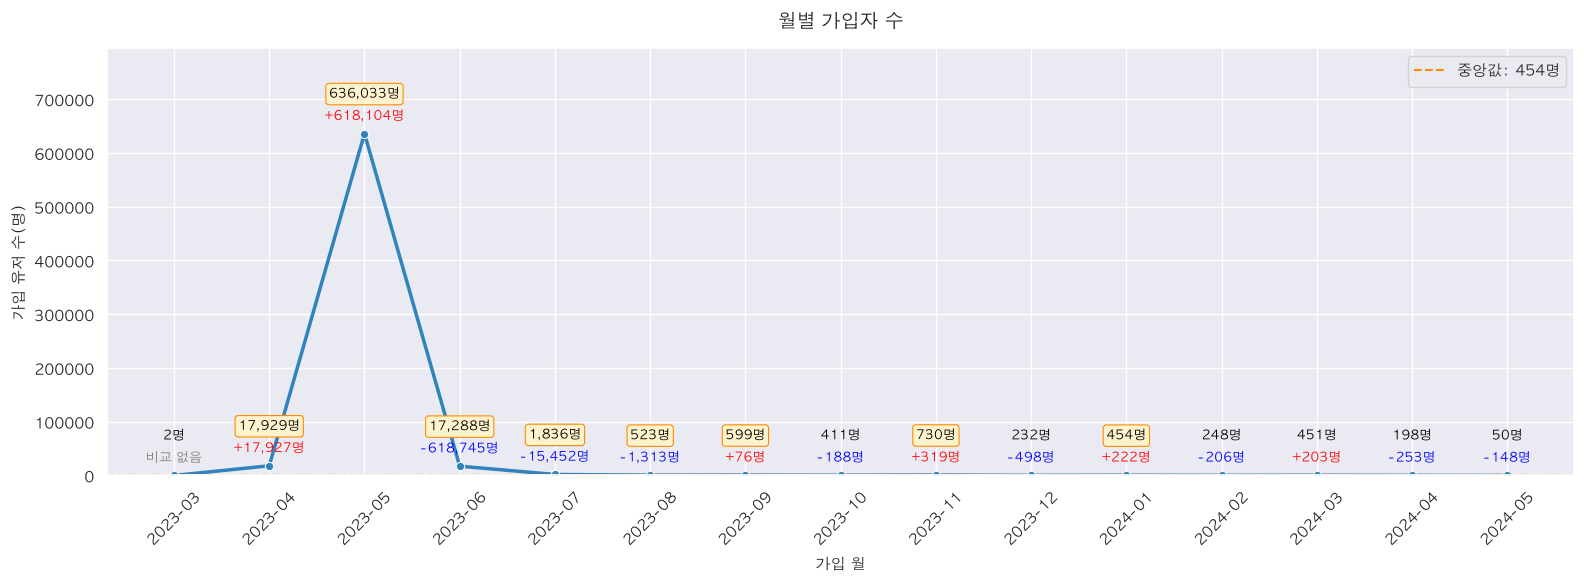

In [72]:
plot_monthly_signups(monthly_summary, '월별 가입자 수')

# 사용자 가입 분석 종합 정리

## 1. 주요 가입자 특성

전체 분석 대상은 **676,984명**이며, 중학생 44.4%, 고등학생 55.6%로 구성되어 있습니다. 학년별로는 **중학교 2학년부터 고등학교 2학년** 사이의 가입자가 대부분을 차지하며, 특히 고등학교 1학년의 가입자 수가 가장 많았습니다. 따라서 현재 관측된 서비스의 핵심 사용자층은 **중2~고2 학생**으로 볼 수 있습니다.

## 2. 가입 시점과 학사일정

월별 가입자 추이를 한국 시간(KST) 기준으로 확인한 결과, 2023년 4월·5월·9월·11월과 2024년 1월·3월에 직전 월 대비 가입자가 증가했습니다. 이 가운데 3~5월과 9월은 새 학년 및 학기 시작, 학급 관계 형성, 시험 종료 이후 교내 활동 시기와 일부 겹칩니다.

따라서 **새 학기와 시험 종료 전후에 가입이 증가할 가능성**은 확인되지만, 실제 학교별 일정이나 마케팅 집행 기록을 함께 비교하지 않았으므로 학사일정을 가입 증가의 직접적인 원인으로 판단할 수는 없습니다. 특히 겨울방학에 해당하는 2024년 1월에도 가입자가 증가했기 때문에 학사일정 외의 요인도 존재할 가능성이 있습니다.

## 3. 지역별 가입자 분포

경기도는 전체 가입자의 약 28%를 차지하며 가장 큰 가입자 기반을 확보했고, 서울은 약 11%로 두 번째로 많았습니다. 경기도에서는 수원·고양·용인·화성 등 일부 도시를 중심으로 큰 가입자 규모가 나타난 반면, 서울은 관측된 시·군·구별 가입자 수의 편차가 비교적 작아 여러 행정구에 고르게 분포하는 모습을 보였습니다.

다만 지역별 가입자 수는 해당 지역의 전체 학생 수, 서비스 적용 학교 수 등의 영향을 받을 수 있습니다. 따라서 현재 결과는 서비스의 절대적인 지역 침투율보다 **현재 데이터에서 관측된 가입자 규모와 분포**를 보여주는 결과로 해석해야 합니다.

## 4. 학급·학교·인접 학교의 집단 가입 패턴

가입자가 4명 이상인 학급을 대상으로 분석한 결과, 약 71.6%의 학급에서 관측 가입자의 40% 이상이 특정 24시간 안에 가입했으며, 약 52.4%에서는 절반 이상이 24시간 안에 가입했습니다.

가입자가 40명 이상인 학교에서는 약 65.6%가 관측 가입자의 절반 이상이 특정 72시간 안에 가입했고, 가입 집중도가 70% 이상인 학교도 약 25.8%로 나타났습니다. 인접 학교 사이에서도 가입 시점 또는 집중 가입 구간이 가까운 사례가 관측되었습니다.

이를 통해 학급과 학교, 인접 학교 수준에서 **가입 시점이 집단적으로 집중되는 현상**이 존재할 가능성을 확인했습니다. 다만 초대·추천 기록과 마케팅 노출 정보가 없으므로, 특정 사용자가 다른 사용자에게 서비스를 전파했다거나 인접 학교로 확산되었다고 확정할 수는 없습니다. 동일한 학사일정이나 외부 캠페인이 여러 학교에 동시에 영향을 주었을 가능성도 함께 고려해야 합니다.

## 5. 학급 내 추가 가입 속도

학급별로 직전 가입자 이후 다음 가입자가 발생하기까지 걸린 시간을 비교하면, 초기에는 가입자가 늘어날수록 추가 가입 시간이 짧아지다가 **약 5명 전후부터 다시 길어지는 경향**이 나타났습니다. 이는 초기 구성원이 모이는 과정에서 가입이 빠르게 진행된 뒤 추가 유입 속도가 둔화되는 패턴으로 볼 수 있습니다.

그러나 이 결과만으로 5명을 서비스 이용의 임계 인원이라고 판단할 수는 없습니다. 학급별 최종 가입자 규모와 관찰 가능 기간이 다르고, 실제 서비스 이용에 필요한 인원이나 초대 행동도 확인되지 않았기 때문입니다. 따라서 현재 단계에서는 **5명 전후를 추가 검증이 필요한 후보 구간**으로 해석하는 것이 적절합니다.

## 6. 지역별 결제 특성

경기도는 가장 큰 가입자 규모를 바탕으로 전체 결제금액도 가장 높았지만, 결제 전환율과 ARPU는 상대적으로 높지 않았습니다. 서울 역시 가입자 규모에 비해 결제 전환율과 ARPU가 낮게 나타났습니다.

반면 전라남도는 가입자 수가 상대적으로 적지만 결제 전환율, ARPU, ARPPU가 모두 높은 수준을 기록했습니다. 시·군·구 단위에서는 전주시가 가입자 규모 대비 높은 결제 성과를 보였습니다. 일부 소규모 지역도 매우 높은 결제 전환율을 기록했지만, 표본이 작아 소수 결제자의 영향을 크게 받을 수 있으므로 추가 관찰이 필요합니다.

또한 학교급별로 나누면 중학교에서는 가입 집중도가 높을수록 30일 결제 전환율과 ARPU가 낮아지는 관계가 나타났고, 고등학교에서는 40~60% 집중도 구간의 결제 성과가 가장 높았습니다. 따라서 가입 집중도와 결제 성과의 관계는 학교급에 따라 다르게 나타나며, 전체 학교를 합산한 결과만으로 판단하기 어렵습니다.

## 7. 종합 해석 및 활용 방향

현재 분석을 통해 다음과 같은 탐색적 가설을 세울 수 있습니다.

1. 서비스의 핵심 가입자층은 중학교 2학년부터 고등학교 2학년 사이에 형성되어 있습니다.
2. 새 학기와 시험 종료 전후는 사용자 획득 실험을 진행할 후보 시점입니다.
3. 학급·학교·인접 학교에서 가입 시점이 집중되는 현상이 존재하지만, 실제 전파 경로와 원인은 확인되지 않았습니다.
4. 경기와 서울은 대규모 사용자 확보에 유리한 후보 지역이며, 전남 등 일부 지역은 가입자당 결제 성과가 높은 후보 지역입니다.
5. 학급 내 약 5명 전후에서 추가 가입 속도가 달라지는 모습이 나타났지만, 이를 서비스 이용의 임계치로 확정하려면 추가 검증이 필요합니다.

따라서 향후에는 동일한 기간과 조건 아래에서 **지역별 사용자 획득 비용, 가입 후 리텐션, 결제 전환율, ARPU와 ARPPU**를 함께 비교하는 실험이 필요합니다. 특히 경기·서울과 관측 결제 성과가 높은 지역을 동시에 비교하면, 대규모 사용자 확보와 수익성 중 어느 전략이 더 효과적인지 평가할 수 있습니다.

> 본 분석은 관측 데이터에서 나타난 관계를 탐색한 결과입니다. 마케팅 노출, 초대·추천 기록, 정확한 학급 변동 이력과 지역별 전체 학생 모집단이 포함되지 않았으므로, 관측된 관계를 직접적인 인과관계로 해석하지 않습니다.

# 가입이 촉진되는 임계점 확인

In [73]:
# 1. 학급별·사용자별 최초 가입 시각 정리
group_user_signup = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .assign(
        signup_datetime=lambda x: pd.to_datetime(
            x['signup_date'],
            utc=True,
            errors='coerce',
        )
    )
    .dropna(subset=['signup_datetime'])
    .groupby(['group_id', 'user_id'], as_index=False)
    .agg(signup_datetime=('signup_datetime', 'min'))
)

# 데이터에서 관측 가능한 마지막 가입 시각
observation_end = group_user_signup['signup_datetime'].max()
followup_period = pd.Timedelta(days=30)

In [74]:
# 2. 학급별 가입 순서와 최초 가입 후 경과시간 계산
group_signup_steps = (
    group_user_signup
    .sort_values(['group_id', 'signup_datetime', 'user_id'])
    .copy()
)

group_signup_steps['가입순번'] = (
    group_signup_steps.groupby('group_id').cumcount() + 1
)

group_signup_steps['최초가입시각'] = (
    group_signup_steps
    .groupby('group_id')['signup_datetime']
    .transform('min')
)

group_signup_steps['최초가입후경과시간'] = (
    group_signup_steps['signup_datetime']
    - group_signup_steps['최초가입시각']
)

In [75]:
# 3. 최초 가입 후 30일을 온전히 관찰할 수 있는 학급만 선정
eligible_group_ids = (
    group_signup_steps.loc[
        group_signup_steps['최초가입시각'].le(
            observation_end - followup_period
        ),
        'group_id',
    ]
    .unique()
)

eligible_steps = (
    group_signup_steps[
        group_signup_steps['group_id'].isin(eligible_group_ids)
    ]
    .copy()
)

print(f'전체 학급 수: {group_signup_steps["group_id"].nunique():,}개')
print(f'30일 관찰 가능 학급 수: {len(eligible_group_ids):,}개')
print(f'관찰 종료 시각: {observation_end}')

전체 학급 수: 80,891개
30일 관찰 가능 학급 수: 80,868개
관찰 종료 시각: 2024-05-09 08:31:17.710824+00:00


In [76]:
# 4. 최초 가입부터 24시간 미만에 가입한 고유 사용자 수
initial_24h_users = (
    eligible_steps.loc[
        eligible_steps['최초가입후경과시간'].lt(
            pd.Timedelta(hours=24)
        )
    ]
    .groupby('group_id')['user_id']
    .nunique()
    .rename('초기24시간가입자수')
)

In [77]:
# 5. 학급별 15번째 가입 도달시간
reached_15 = (
    eligible_steps.loc[
        eligible_steps['가입순번'].eq(15),
        ['group_id', '최초가입후경과시간'],
    ]
    .set_index('group_id')
    .rename(columns={'최초가입후경과시간': '15명도달시간'})
)

# 30일 안에 15명에 도달한 경우만 인정
reached_15['30일내15명도달'] = (
    reached_15['15명도달시간'].le(followup_period)
)

reached_15.loc[
    ~reached_15['30일내15명도달'],
    '15명도달시간',
] = pd.NaT

In [78]:
# 6. 학급 단위 분석 데이터 생성
group_growth = (
    initial_24h_users
    .to_frame()
    .join(reached_15, how='left')
)

group_growth['30일내15명도달'] = (
    group_growth['30일내15명도달']
    .fillna(False)
    .astype(bool)
)

group_growth['15명도달시간(시간)'] = (
    group_growth['15명도달시간'].dt.total_seconds() / 3600
)

group_growth['초기 24시간 가입자'] = pd.cut(
    group_growth['초기24시간가입자수'],
    bins=[0, 1, 2, 3, 4, float('inf')],
    labels=['1명', '2명', '3명', '4명', '5명 이상'],
)

In [79]:
# 7. 초기 가입자 구간별 결과 집계
initial_growth_summary = (
    group_growth
    .groupby('초기 24시간 가입자', observed=False)
    .agg(
        학급수=('30일내15명도달', 'size'),
        도달학급수=('30일내15명도달', 'sum'),
        도달시간평균=('15명도달시간(시간)', 'mean'),
        도달시간중앙값=('15명도달시간(시간)', 'median'),
    )
    .reset_index()
)

initial_growth_summary['30일 내 15명 도달률(%)'] = (
    initial_growth_summary['도달학급수']
    / initial_growth_summary['학급수']
    * 100
)

initial_growth_summary[
    [
        '30일 내 15명 도달률(%)',
        '도달시간평균',
        '도달시간중앙값',
    ]
] = initial_growth_summary[
    [
        '30일 내 15명 도달률(%)',
        '도달시간평균',
        '도달시간중앙값',
    ]
].round(2)

display(
    initial_growth_summary[
        [
            '초기 24시간 가입자',
            '학급수',
            '도달학급수',
            '30일 내 15명 도달률(%)',
            '도달시간평균',
            '도달시간중앙값',
        ]
    ]
)

,초기 24시간 가입자,학급수,도달학급수,30일 내 15명 도달률(%),도달시간평균,도달시간중앙값
0,1명,41380,3970,9.59,254.43,222.00
1,2명,12147,1587,13.06,220.14,185.80
2,3명,6915,1112,16.08,194.35,160.82
3,4명,4777,865,18.11,189.51,148.27
4,5명 이상,15649,6105,39.01,124.02,84.28


초기 24시간 내 가입자 수와 이후 학급의 성장 관계를 확인한 결과,
5명 이상이 가입한 학급은 다른 구간보다 30일 내 15명 도달률이 높고,
15명까지 도달하는 데 걸린 평균 및 중앙 소요시간도 짧게 나타났다.

이는 초기 24시간 동안 형성된 가입자 규모가 이후 학급 단위의 성장 가능성을
판단하는 선행지표로 활용될 가능성을 보여준다.

다만 초기 가입자 수가 후속 가입을 직접 유발했다고 단정할 수는 없다.
원래 서비스 수요가 높거나 구성원 간 관계가 활발한 학급에서
초기 가입과 후속 가입이 모두 높게 나타났을 가능성도 함께 고려해야 한다.

In [80]:
# 초기 24시간 가입자가 정확히 1~15명인 학급만 비교
group_growth_exact = (
    group_growth[
        group_growth['초기24시간가입자수'].between(1, 15)
    ]
    .copy()
)

In [81]:
# 초기 24시간 가입자 수별 결과 집계
initial_growth_summary_exact = (
    group_growth_exact
    .groupby('초기24시간가입자수')
    .agg(
        학급수=('30일내15명도달', 'size'),
        도달학급수=('30일내15명도달', 'sum'),
        도달시간평균=('15명도달시간(시간)', 'mean'),
        도달시간중앙값=('15명도달시간(시간)', 'median'),
    )
    .reindex(range(1, 16))
    .rename_axis('초기 24시간 가입자 수')
    .reset_index()
)

initial_growth_summary_exact['학급수'] = (
    initial_growth_summary_exact['학급수']
    .fillna(0)
    .astype(int)
)

initial_growth_summary_exact['도달학급수'] = (
    initial_growth_summary_exact['도달학급수']
    .fillna(0)
    .astype(int)
)

initial_growth_summary_exact['30일 내 15명 도달률(%)'] = (
    initial_growth_summary_exact['도달학급수']
    / initial_growth_summary_exact['학급수'].replace(0, float('nan'))
    * 100
)

round_columns = [
    '30일 내 15명 도달률(%)',
    '도달시간평균',
    '도달시간중앙값',
]

initial_growth_summary_exact[round_columns] = (
    initial_growth_summary_exact[round_columns].round(2)
)

display(initial_growth_summary_exact)

,초기 24시간 가입자 수,학급수,도달학급수,도달시간평균,도달시간중앙값,30일 내 15명 도달률(%)
0,1,41380,3970,254.43,222.00,9.59
1,2,12147,1587,220.14,185.80,13.06
2,3,6915,1112,194.35,160.82,16.08
3,4,4777,865,189.51,148.27,18.11
4,5,3632,822,182.85,136.91,22.63
5,6,2926,773,172.80,130.90,26.42
6,7,2251,677,154.43,113.02,30.08
7,8,1731,616,150.46,110.21,35.59
8,9,1409,574,132.07,93.74,40.74
9,10,1030,530,117.67,85.99,51.46


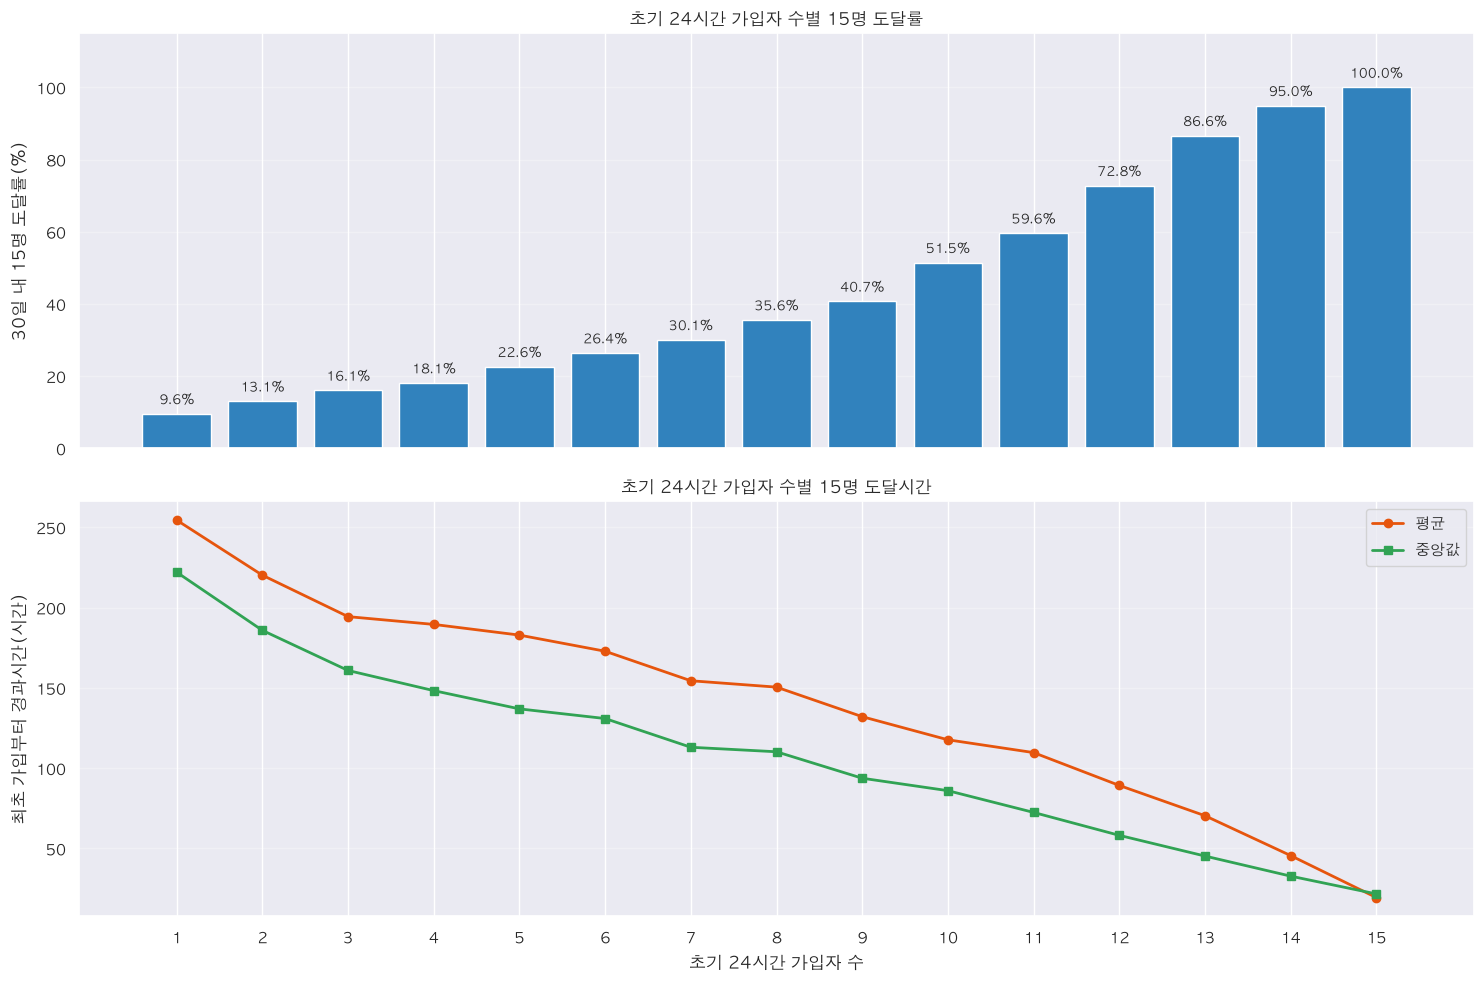

In [82]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

x = initial_growth_summary_exact['초기 24시간 가입자 수']

# 15명 도달률
bars = axes[0].bar(
    x,
    initial_growth_summary_exact['30일 내 15명 도달률(%)'],
    color='#3182bd',
)

axes[0].bar_label(
    bars,
    labels=[
        f'{value:.1f}%' if pd.notna(value) else ''
        for value in initial_growth_summary_exact[
            '30일 내 15명 도달률(%)'
        ]
    ],
    padding=4,
    fontsize=9,
)

axes[0].set_title('초기 24시간 가입자 수별 15명 도달률')
axes[0].set_ylabel('30일 내 15명 도달률(%)')
axes[0].margins(y=0.15)
axes[0].grid(axis='y', alpha=0.3)

# 15명 도달시간
axes[1].plot(
    x,
    initial_growth_summary_exact['도달시간평균'],
    marker='o',
    linewidth=2,
    label='평균',
    color='#e6550d',
)

axes[1].plot(
    x,
    initial_growth_summary_exact['도달시간중앙값'],
    marker='s',
    linewidth=2,
    label='중앙값',
    color='#31a354',
)

axes[1].set_title('초기 24시간 가입자 수별 15명 도달시간')
axes[1].set_xlabel('초기 24시간 가입자 수')
axes[1].set_ylabel('최초 가입부터 경과시간(시간)')
axes[1].set_xticks(range(1, 16))
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

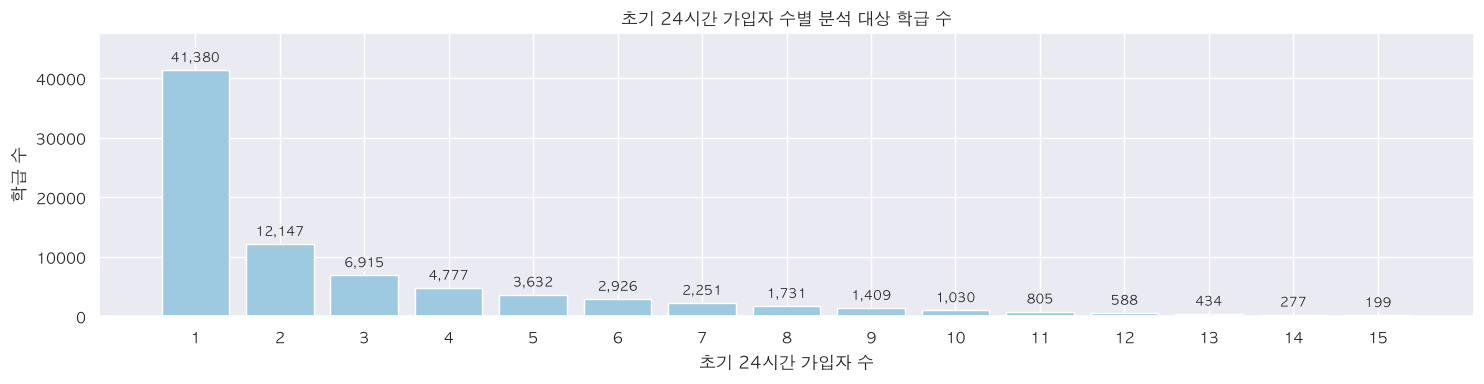

In [83]:
fig, ax = plt.subplots(figsize=(15, 4))

bars = ax.bar(
    x,
    initial_growth_summary_exact['학급수'],
    color='#9ecae1',
)

ax.bar_label(
    bars,
    labels=[
        f'{count:,}'
        for count in initial_growth_summary_exact['학급수']
    ],
    padding=3,
    fontsize=9,
)

ax.set_title('초기 24시간 가입자 수별 분석 대상 학급 수')
ax.set_xlabel('초기 24시간 가입자 수')
ax.set_ylabel('학급 수')
ax.set_xticks(range(1, 16))
ax.margins(y=0.15)

fig.tight_layout()
plt.show()

초기 24시간 가입자가 많을수록 30일 내 15명 도달 가능성이 높아졌으며, 특히 10명 전후에서 성과 차이가 두드러졌다. 다만 초기 인원이 많을수록 목표인 15명까지 필요한 추가 인원이 적어지는 구조적 영향이 있으므로, 10명을 확산 임계치로 해석하려면 초기 가입 이후의 추가 성장률을 별도로 확인할 필요가 있다.

In [84]:
# 분석 기준
initial_window = pd.Timedelta(hours=24)
additional_window = pd.Timedelta(days=7)
required_observation = initial_window + additional_window

observation_end = group_signup_steps['signup_datetime'].max()

In [85]:
# 최초 가입 후 8일을 온전히 관찰할 수 있는 학급만 선정
additional_eligible_groups = (
    group_signup_steps.loc[
        group_signup_steps['최초가입시각'].le(
            observation_end - required_observation
        ),
        'group_id',
    ]
    .unique()
)

additional_steps = (
    group_signup_steps[
        group_signup_steps['group_id'].isin(
            additional_eligible_groups
        )
    ]
    .copy()
)

print(
    f'분석 대상 학급 수: '
    f'{len(additional_eligible_groups):,}개'
)

분석 대상 학급 수: 80,885개


In [86]:
# 초기 24시간 가입자 수
initial_counts = (
    additional_steps.loc[
        additional_steps['최초가입후경과시간'].lt(initial_window)
    ]
    .groupby('group_id')['user_id']
    .nunique()
    .rename('초기24시간가입자수')
)

# 초기 24시간 이후부터 7일 동안 발생한 추가 가입
after_initial = (
    additional_steps.loc[
        additional_steps['최초가입후경과시간'].ge(initial_window)
        & additional_steps['최초가입후경과시간'].le(
            required_observation
        )
    ]
    .copy()
)

after_initial['추가가입순번'] = (
    after_initial.groupby('group_id').cumcount() + 1
)

In [87]:
# 7일 동안 추가로 가입한 사용자 수
additional_counts = (
    after_initial
    .groupby('group_id')['user_id']
    .nunique()
    .rename('7일추가가입자수')
)

# 초기 24시간 종료 후 다섯 번째 추가 가입자의 발생 시각
reached_additional_5 = (
    after_initial.loc[
        after_initial['추가가입순번'].eq(5),
        ['group_id', '최초가입후경과시간'],
    ]
    .set_index('group_id')
)

reached_additional_5['추가5명도달시간(시간)'] = (
    reached_additional_5['최초가입후경과시간']
    - initial_window
).dt.total_seconds() / 3600

reached_additional_5 = (
    reached_additional_5['추가5명도달시간(시간)']
)

In [88]:
additional_growth = (
    pd.DataFrame(index=additional_eligible_groups)
    .rename_axis('group_id')
    .join(initial_counts)
    .join(additional_counts)
    .join(reached_additional_5)
)

additional_growth['7일추가가입자수'] = (
    additional_growth['7일추가가입자수']
    .fillna(0)
    .astype(int)
)

additional_growth['7일내추가5명도달'] = (
    additional_growth['7일추가가입자수'].ge(5)
)

display(additional_growth.head())

,초기24시간가입자수,7일추가가입자수,추가5명도달시간(시간),7일내추가5명도달
group_id,,,,
20,2,2,NaN,False
21,7,4,NaN,False
23,1,0,NaN,False
26,2,4,NaN,False
27,6,4,NaN,False


In [89]:
additional_growth_summary = (
    additional_growth[
        additional_growth['초기24시간가입자수'].between(1, 15)
    ]
    .groupby('초기24시간가입자수')
    .agg(
        학급수=('7일내추가5명도달', 'size'),
        추가5명도달학급수=('7일내추가5명도달', 'sum'),
        평균추가가입자수=('7일추가가입자수', 'mean'),
        추가5명도달시간평균=('추가5명도달시간(시간)', 'mean'),
        추가5명도달시간중앙값=('추가5명도달시간(시간)', 'median'),
    )
    .reindex(range(1, 16))
    .rename_axis('초기 24시간 가입자 수')
    .reset_index()
)

additional_growth_summary['추가 5명 도달률(%)'] = (
    additional_growth_summary['추가5명도달학급수']
    / additional_growth_summary['학급수'].replace(
        0,
        float('nan'),
    )
    * 100
)

value_columns = [
    '평균추가가입자수',
    '추가 5명 도달률(%)',
    '추가5명도달시간평균',
    '추가5명도달시간중앙값',
]

additional_growth_summary[value_columns] = (
    additional_growth_summary[value_columns].round(2)
)

display(additional_growth_summary)

,초기 24시간 가입자 수,학급수,추가5명도달학급수,평균추가가입자수,추가5명도달시간평균,추가5명도달시간중앙값,추가 5명 도달률(%)
0,1,41397,10242,2.96,82.21,77.54,24.74
1,2,12147,5057,4.61,68.66,60.28,41.63
2,3,6915,3417,5.27,63.61,51.99,49.41
3,4,4777,2483,5.29,58.93,47.47,51.98
4,5,3632,1924,5.37,57.80,47.36,52.97
5,6,2926,1518,5.25,55.95,45.72,51.88
6,7,2251,1110,4.99,54.16,44.62,49.31
7,8,1731,830,4.91,56.47,46.96,47.95
8,9,1409,631,4.59,57.34,46.53,44.78
9,10,1030,455,4.47,59.24,50.07,44.17


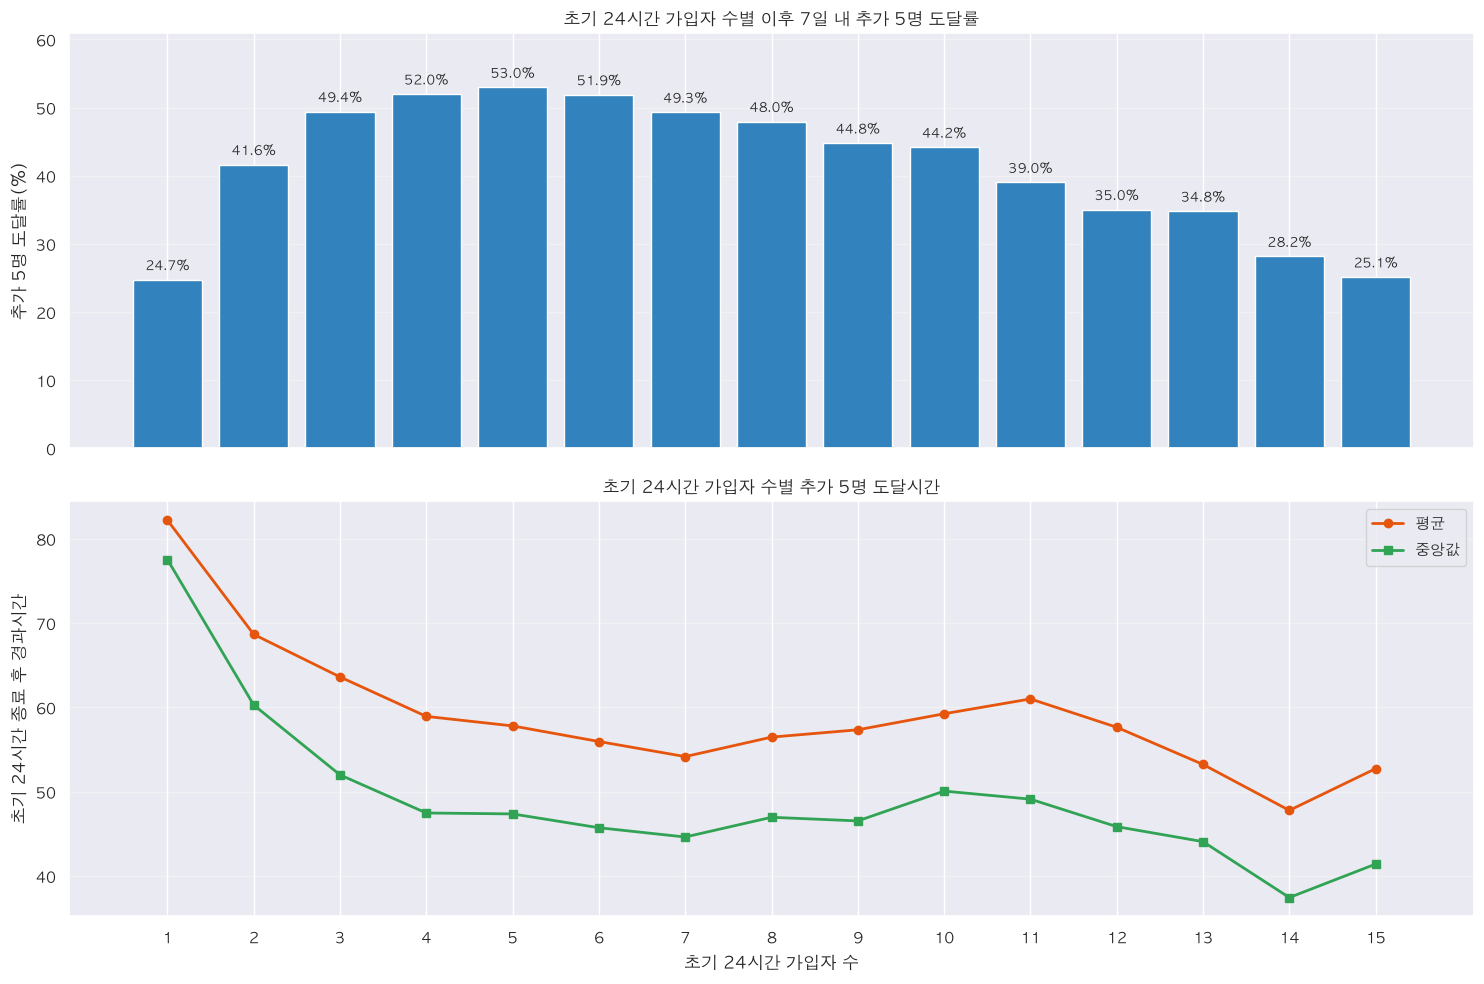

In [90]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

x = additional_growth_summary['초기 24시간 가입자 수']

# 추가 5명 도달률
bars = axes[0].bar(
    x,
    additional_growth_summary['추가 5명 도달률(%)'],
    color='#3182bd',
)

axes[0].bar_label(
    bars,
    labels=[
        f'{value:.1f}%' if pd.notna(value) else ''
        for value in additional_growth_summary[
            '추가 5명 도달률(%)'
        ]
    ],
    padding=4,
    fontsize=9,
)

axes[0].set_title(
    '초기 24시간 가입자 수별 이후 7일 내 추가 5명 도달률'
)
axes[0].set_ylabel('추가 5명 도달률(%)')
axes[0].margins(y=0.15)
axes[0].grid(axis='y', alpha=0.3)

# 추가 5명 도달시간
axes[1].plot(
    x,
    additional_growth_summary['추가5명도달시간평균'],
    marker='o',
    linewidth=2,
    label='평균',
    color='#e6550d',
)

axes[1].plot(
    x,
    additional_growth_summary['추가5명도달시간중앙값'],
    marker='s',
    linewidth=2,
    label='중앙값',
    color='#31a354',
)

axes[1].set_title(
    '초기 24시간 가입자 수별 추가 5명 도달시간'
)
axes[1].set_xlabel('초기 24시간 가입자 수')
axes[1].set_ylabel('초기 24시간 종료 후 경과시간')
axes[1].set_xticks(range(1, 16))
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

# 시간 경과에 따른 유저 인입

In [91]:
# 학급·사용자별 최초 가입 시각
group_user_signup = (
    df[['group_id', 'user_id', 'signup_date']]
    .dropna(subset=['group_id', 'user_id', 'signup_date'])
    .assign(
        signup_datetime=lambda x: pd.to_datetime(
            x['signup_date'],
            utc=True,
            errors='coerce',
        )
    )
    .dropna(subset=['signup_datetime'])
    .groupby(['group_id', 'user_id'], as_index=False)
    .agg(signup_datetime=('signup_datetime', 'min'))
)

In [92]:
# 데이터에서 확인 가능한 마지막 가입 시각
observation_end = group_user_signup['signup_datetime'].max()

# 분석 기간
followup_days = 30
followup_period = pd.Timedelta(days=followup_days)

# 학급별 최초 가입 시각
group_first_signup = (
    group_user_signup
    .groupby('group_id')['signup_datetime']
    .min()
    .rename('최초가입시각')
)

# 최초 가입 이후 30일을 온전히 관찰할 수 있는 학급
eligible_groups = (
    group_first_signup[
        group_first_signup.le(observation_end - followup_period)
    ]
    .index
)

print(f'전체 학급 수: {group_first_signup.size:,}개')
print(f'30일 관찰 가능 학급 수: {len(eligible_groups):,}개')
print(f'관찰 종료 시각: {observation_end}')

전체 학급 수: 80,891개
30일 관찰 가능 학급 수: 80,868개
관찰 종료 시각: 2024-05-09 08:31:17.710824+00:00


In [93]:
group_signup_timeline = (
    group_user_signup[
        group_user_signup['group_id'].isin(eligible_groups)
    ]
    .merge(
        group_first_signup.reset_index(),
        on='group_id',
        how='left',
    )
)

group_signup_timeline['경과시간'] = (
    group_signup_timeline['signup_datetime']
    - group_signup_timeline['최초가입시각']
)

group_signup_timeline['경과일'] = (
    group_signup_timeline['경과시간']
    .dt.total_seconds()
    .floordiv(24 * 60 * 60)
    .astype(int)
)

# 최초 가입 후 D0~D30만 사용
group_signup_timeline = group_signup_timeline[
    group_signup_timeline['경과일'].between(0, followup_days)
].copy()

In [94]:
# 학급별·경과일별 가입자 수
daily_signup_counts = (
    group_signup_timeline
    .groupby(['group_id', '경과일'])['user_id']
    .nunique()
    .rename('일별가입자수')
)

# 모든 학급 × D0~D30 조합
group_day_index = pd.MultiIndex.from_product(
    [
        eligible_groups,
        range(0, followup_days + 1),
    ],
    names=['group_id', '경과일'],
)

group_day_panel = (
    daily_signup_counts
    .reindex(group_day_index, fill_value=0)
    .reset_index()
)

group_day_panel['일별가입자수'] = (
    group_day_panel['일별가입자수'].astype(int)
)

In [95]:
group_day_panel['일별추가가입자수'] = (
    group_day_panel['일별가입자수']
)

d0_mask = group_day_panel['경과일'].eq(0)

group_day_panel.loc[
    d0_mask,
    '일별추가가입자수',
] = (
    group_day_panel.loc[d0_mask, '일별가입자수'] - 1
).clip(lower=0)

group_day_panel['추가가입발생'] = (
    group_day_panel['일별추가가입자수'].gt(0)
)

In [96]:
daily_acquisition_summary = (
    group_day_panel
    .groupby('경과일')
    .agg(
        관찰학급수=('group_id', 'nunique'),
        총추가가입자수=('일별추가가입자수', 'sum'),
        평균추가가입자수=('일별추가가입자수', 'mean'),
        중앙추가가입자수=('일별추가가입자수', 'median'),
        추가가입발생학급수=('추가가입발생', 'sum'),
    )
    .reset_index()
)

daily_acquisition_summary['추가 가입 발생 학급 비율(%)'] = (
    daily_acquisition_summary['추가가입발생학급수']
    / daily_acquisition_summary['관찰학급수']
    * 100
)

daily_acquisition_summary[
    [
        '평균추가가입자수',
        '중앙추가가입자수',
        '추가 가입 발생 학급 비율(%)',
    ]
] = daily_acquisition_summary[
    [
        '평균추가가입자수',
        '중앙추가가입자수',
        '추가 가입 발생 학급 비율(%)',
    ]
].round(2)

display(daily_acquisition_summary)

,경과일,관찰학급수,총추가가입자수,평균추가가입자수,중앙추가가입자수,추가가입발생학급수,추가 가입 발생 학급 비율(%)
0,0,80868,147886,1.83,0.0,39488,48.83
1,1,80868,82448,1.02,0.0,31567,39.04
2,2,80868,63361,0.78,0.0,28241,34.92
3,3,80868,49820,0.62,0.0,24909,30.80
4,4,80868,38696,0.48,0.0,20874,25.81
5,5,80868,32084,0.40,0.0,17866,22.09
6,6,80868,27391,0.34,0.0,15757,19.48
7,7,80868,22551,0.28,0.0,13388,16.56
8,8,80868,18375,0.23,0.0,11245,13.91
9,9,80868,15472,0.19,0.0,9694,11.99


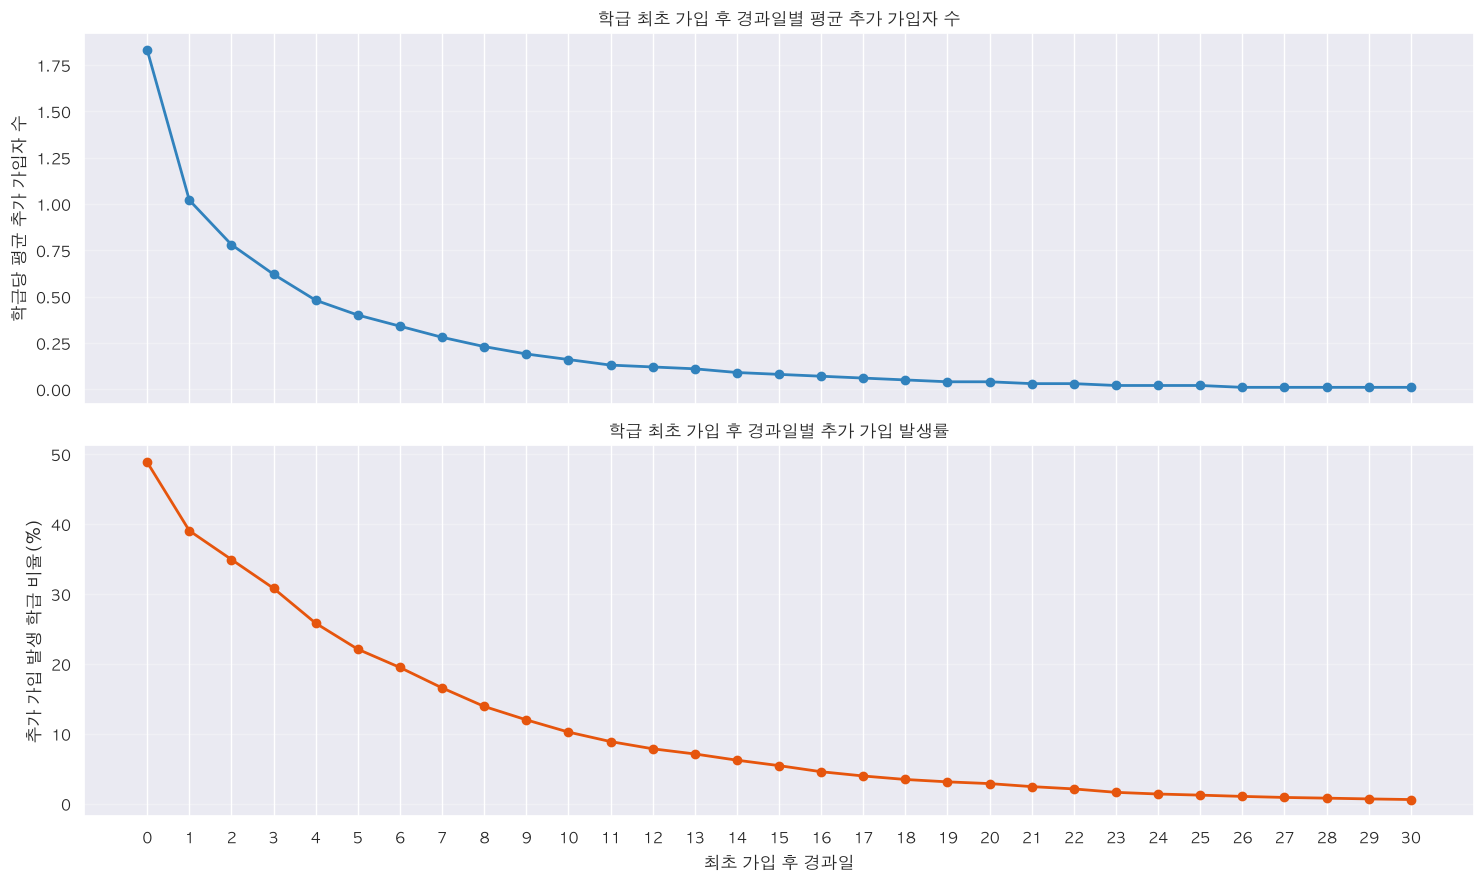

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# 학급당 평균 추가 가입자 수
axes[0].plot(
    daily_acquisition_summary['경과일'],
    daily_acquisition_summary['평균추가가입자수'],
    marker='o',
    linewidth=2,
    color='#3182bd',
)

axes[0].set_title('학급 최초 가입 후 경과일별 평균 추가 가입자 수')
axes[0].set_ylabel('학급당 평균 추가 가입자 수')
axes[0].grid(axis='y', alpha=0.3)

# 추가 가입 발생 학급 비율
axes[1].plot(
    daily_acquisition_summary['경과일'],
    daily_acquisition_summary['추가 가입 발생 학급 비율(%)'],
    marker='o',
    linewidth=2,
    color='#e6550d',
)

axes[1].set_title('학급 최초 가입 후 경과일별 추가 가입 발생률')
axes[1].set_xlabel('최초 가입 후 경과일')
axes[1].set_ylabel('추가 가입 발생 학급 비율(%)')
axes[1].set_xticks(range(0, followup_days + 1))
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()

In [98]:
group_day_panel = group_day_panel.sort_values(
    ['group_id', '경과일']
).copy()

# 해당 날짜가 시작되기 전까지 누적된 가입자 수
group_day_panel['이전일까지누적가입자수'] = (
    group_day_panel
    .groupby('group_id')['일별가입자수']
    .cumsum()
    - group_day_panel['일별가입자수']
)

# D1부터는 모든 학급에 최초 가입자가 존재함
comparison_panel = group_day_panel[
    group_day_panel['경과일'].ge(1)
].copy()

comparison_panel['기존 누적 가입자 구간'] = pd.cut(
    comparison_panel['이전일까지누적가입자수'],
    bins=[0, 4, 8, 14, float('inf')],
    labels=['1~4명', '5~8명', '9~14명', '15명 이상'],
)

In [99]:
signup_rate_by_size = (
    comparison_panel
    .groupby(
        ['경과일', '기존 누적 가입자 구간'],
        observed=False,
    )
    .agg(
        학급수=('group_id', 'size'),
        추가가입발생학급수=('추가가입발생', 'sum'),
        평균추가가입자수=('일별추가가입자수', 'mean'),
    )
    .reset_index()
)

signup_rate_by_size['추가 가입 발생률(%)'] = (
    signup_rate_by_size['추가가입발생학급수']
    / signup_rate_by_size['학급수'].replace(0, np.nan)
    * 100
)

signup_rate_by_size[
    ['추가 가입 발생률(%)', '평균추가가입자수']
] = signup_rate_by_size[
    ['추가 가입 발생률(%)', '평균추가가입자수']
].round(2)

display(signup_rate_by_size)

,경과일,기존 누적 가입자 구간,학급수,추가가입발생학급수,평균추가가입자수,추가 가입 발생률(%)
0,1,1~4명,65219,20260,0.79,31.06
1,1,5~8명,10540,7543,2.04,71.57
2,1,9~14명,4543,3380,1.92,74.4
3,1,15명 이상,566,384,1.61,67.84
4,2,1~4명,56546,13931,0.56,24.64
...,...,...,...,...,...,...
115,29,15명 이상,13606,102,0.01,0.75
116,30,1~4명,28503,91,0.00,0.32
117,30,5~8명,15319,97,0.01,0.63
118,30,9~14명,23407,183,0.01,0.78


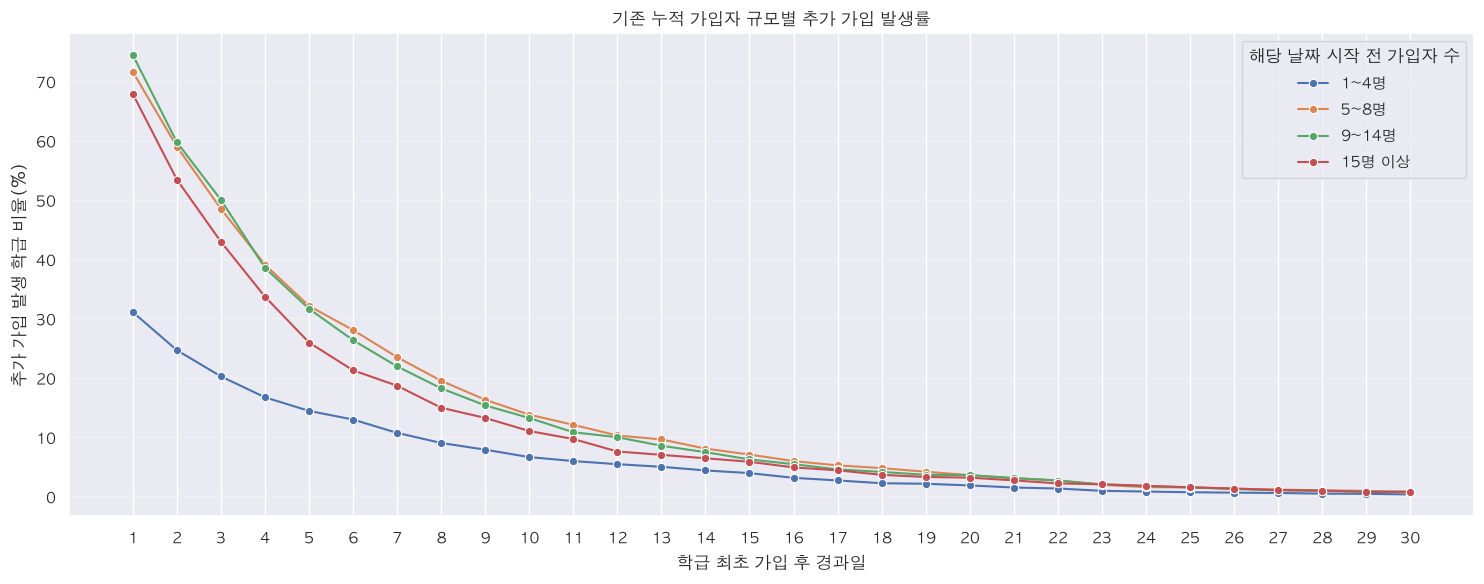

In [100]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    data=signup_rate_by_size,
    x='경과일',
    y='추가 가입 발생률(%)',
    hue='기존 누적 가입자 구간',
    marker='o',
    ax=ax,
)

ax.set_title('기존 누적 가입자 규모별 추가 가입 발생률')
ax.set_xlabel('학급 최초 가입 후 경과일')
ax.set_ylabel('추가 가입 발생 학급 비율(%)')
ax.set_xticks(range(1, followup_days + 1))
ax.grid(axis='y', alpha=0.3)
ax.legend(title='해당 날짜 시작 전 가입자 수')

fig.tight_layout()
plt.show()

학급 최초 가입 이후 경과일별 추가 가입 패턴을 확인한 결과, 학급당 평균 추가 가입자 수와 추가 가입이 발생한 학급의 비율이 모두 시간의 경과에 따라 감소했습니다.

최초 가입 후 24시간 이내에는 48.83%의 학급에서 추가 가입이 발생했으나, 7일차에는 16.56%, 14일차에는 6.22%로 감소했습니다. 이를 통해 학급의 후속 가입은 최초 사용자 유입과 가까운 시기에 집중되며, 시간이 경과할수록 추가 사용자를 확보할 가능성이 낮아지는 경향을 확인했습니다.

누적 가입자 규모별로 구분했을 때도 초기 가입자가 많은 학급에서 후속 가입 발생률이 높았으나, 모든 구간에서 시간이 흐르면서 가입 발생률이 감소하는 흐름이 나타났습니다. 이는 초기 가입 규모뿐만 아니라 최초 가입 이후의 경과시간도 후속 가입 가능성과 관련되어 있을 가능성을 보여줍니다.

다만 시간이 지나도 낮은 누적 인원 구간에 남아 있는 학급은 원래 성장 속도가 느린 학급일 수 있으므로, 이를 시간 경과가 추가 가입 감소를 직접 유발한 결과로 단정할 수는 없습니다.

# 정리

# 사용자 가입 분석 종합 결론

## 1. 주요 가입자 특성

전체 분석 대상은 **676,984명**이며, 중학생 44.4%, 고등학생 55.6%로 구성되어 있습니다. 학년별로는 중학교 2학년부터 고등학교 2학년 사이의 가입자가 대부분을 차지하며, 특히 고등학교 1학년의 가입자 수가 가장 많았습니다.

따라서 현재 관측된 서비스의 핵심 사용자층은 **중학교 2학년부터 고등학교 2학년 사이의 학생**으로 볼 수 있습니다.

## 2. 가입 시점과 학사일정

월별 가입자 추이를 한국 시간(KST)으로 확인한 결과, 2023년 4월·5월·9월·11월과 2024년 1월·3월에 직전 월 대비 가입자가 증가했습니다.

이 가운데 3~5월과 9월은 새 학년 및 학기 시작, 새로운 학급 관계 형성, 시험 종료 이후의 교내 활동 시기와 일부 겹칩니다. 이를 통해 학교생활이 활발해지는 시점과 사용자 가입 증가가 관련되어 있을 가능성을 생각해볼 수 있습니다.

다만 실제 학교별 학사일정과 마케팅 집행 기록을 함께 비교하지 않았고, 겨울방학인 2024년 1월에도 가입자가 증가했습니다. 따라서 학사일정을 가입자 증가의 직접적인 원인으로 판단하기보다, **새 학기와 시험 종료 전후를 사용자 획득 실험의 후보 시점**으로 보는 것이 적절합니다.

## 3. 지역별 가입자 및 결제 특성

경기도는 전체 가입자의 약 28%를 차지하며 가장 큰 가입자 기반을 확보했고, 서울은 약 11%로 두 번째로 많았습니다.

경기도에서는 수원·고양·용인·화성 등 일부 도시를 중심으로 큰 가입자 규모가 나타났습니다. 서울은 관측된 시·군·구별 가입자 수의 편차가 상대적으로 작아, 특정 행정구보다 여러 지역에 비교적 고르게 가입자가 분포하는 모습을 보였습니다.

결제 측면에서 경기도는 가장 큰 전체 결제금액을 기록했지만 결제 전환율과 ARPU는 상대적으로 높지 않았습니다. 서울도 가입자 규모에 비해 결제 전환율과 ARPU가 낮게 나타났습니다.

반면 전라남도는 가입자 규모가 상대적으로 작지만 결제 전환율, ARPU 및 ARPPU가 높은 수준을 기록했습니다. 시·군·구 단위에서는 전주시가 가입자 규모 대비 높은 결제 성과를 보였습니다.

따라서 지역별 성과는 가입자 수만으로 평가하기보다 다음 지표를 함께 고려해야 합니다.

- 가입자 규모
- 결제 전환율
- ARPU
- ARPPU
- 분석에 포함된 가입자 및 결제자 표본 수

특히 일부 소규모 지역의 높은 결제 전환율은 소수 결제자의 영향을 크게 받을 수 있으므로, 추가 기간의 데이터를 통해 성과가 유지되는지 확인할 필요가 있습니다.

## 4. 학급·학교·인접 학교의 집단 가입

가입자가 4명 이상인 학급을 대상으로 확인한 결과, 약 71.6%의 학급에서 관측 가입자의 40% 이상이 특정 24시간 안에 가입했습니다. 약 52.4%의 학급에서는 관측 가입자의 절반 이상이 24시간 안에 가입했습니다.

가입자가 40명 이상인 학교에서는 약 65.6%가 관측 가입자의 절반 이상이 특정 72시간 안에 가입했으며, 가입 집중도가 70% 이상인 학교도 약 25.8%로 나타났습니다.

인접 학교 사이에서도 최초 가입 시점이 가깝거나 집중 가입 구간이 겹치는 사례가 관측되었습니다.

이를 통해 서비스 가입이 개인별로 완전히 독립적으로 발생하기보다, **학급·학교 및 인접 학교 수준에서 특정 시점에 집중되는 경향**이 존재할 가능성을 확인했습니다.

다만 현재 데이터에는 초대·추천 기록, 마케팅 노출 정보와 정확한 학급 변경 이력이 없습니다. 따라서 친구 추천을 통한 전파가 발생했거나 특정 학교에서 인접 학교로 서비스가 확산되었다고 확정할 수는 없습니다. 동일한 학사일정이나 외부 캠페인이 여러 집단에 동시에 영향을 주었을 가능성도 함께 고려해야 합니다.

## 5. 초기 가입 규모와 학급 성장

학급 최초 가입 후 24시간 동안 가입한 사용자 수와 이후 학급의 성장을 비교한 결과, 초기 가입자가 많은 학급일수록 30일 내 15명에 도달하는 비율이 높고 도달시간도 짧게 나타났습니다.

그러나 초기 가입자가 많을수록 목표인 15명까지 필요한 추가 인원이 적기 때문에, 높은 도달률과 짧은 도달시간에는 분석 구조에 따른 영향도 포함되어 있습니다. 따라서 분석 과정에서 관찰된 5명 또는 9명 전후의 변화를 명확한 임계 인원으로 판단하기는 어렵습니다.

이를 보완하기 위해 모든 학급에 동일하게 `추가 5명 가입`이라는 목표를 적용한 결과, 초기 24시간 가입자가 1명에서 5명으로 증가할수록 이후 7일 내 추가 5명 도달률이 높아졌습니다.

| 초기 24시간 가입자 | 7일 내 추가 5명 도달률 |
|---:|---:|
| 1명 | 24.74% |
| 2명 | 41.63% |
| 3명 | 49.41% |
| 4명 | 51.98% |
| 5명 | 52.97% |

초기 가입자가 5명일 때 추가 5명 도달률이 가장 높았으며, 이후에는 초기 가입자 수가 증가할수록 도달률이 점차 낮아졌습니다. 추가 가입자 수도 초기 4~5명 구간에서 가장 높게 나타났습니다.

따라서 초기 가입자가 많을수록 후속 성장이 계속 강해진다고 보기는 어렵습니다. 현재 결과에서는 **초기 3~6명가량이 모인 학급에서 후속 가입이 가장 활발하게 이어지는 경향**이 나타났으며, 초기 24시간 가입 규모는 이후 성장 가능성을 파악하는 선행지표로 활용할 수 있습니다.

다만 초기 가입자가 후속 가입을 직접 유발한 것인지, 원래 가입 수요가 높은 학급에서 초기 가입과 후속 가입이 모두 활발했던 것인지는 구분할 수 없습니다.

## 6. 최초 가입 이후 시간 경과와 추가 가입

학급 최초 가입 이후 경과일별 가입 흐름을 확인한 결과, 학급당 평균 추가 가입자 수와 추가 가입이 발생한 학급의 비율이 모두 시간에 따라 지속적으로 감소했습니다.

| 경과일 | 평균 추가 가입자 수 | 추가 가입 발생 학급 비율 |
|---:|---:|---:|
| D0 | 1.83명 | 48.83% |
| D1 | 1.02명 | 39.04% |
| D3 | 0.62명 | 30.80% |
| D7 | 0.28명 | 16.56% |
| D14 | 0.09명 | 6.22% |
| D21 | 0.03명 | 2.44% |
| D29 | 0.01명 | 0.68% |

D0에서는 모든 학급에 존재하는 최초 가입자 1명을 제외하고 추가 가입자만 계산했습니다.

최초 가입 후 24시간 안에는 약 절반의 학급에서 추가 가입이 발생했지만, 7일차에는 약 16.6%, 14일차에는 약 6.2%까지 감소했습니다. 이를 통해 학급의 후속 가입은 최초 사용자 유입과 가까운 시기에 집중되며, **최초 가입 후 첫 일주일 동안 추가 사용자 확보 가능성이 빠르게 낮아지는 경향**을 확인했습니다.

누적 가입자 규모별로 나누어 확인했을 때도 최초 가입 직후에는 이미 여러 명이 가입한 학급에서 후속 가입 발생률이 높았지만, 시간이 흐르면서 모든 누적 인원 구간의 발생률이 감소했습니다.

다만 학급이 성장하면 누적 가입자 구간이 달라지고, 시간이 지나도 낮은 인원 구간에 남은 학급은 원래 성장 속도가 느린 학급일 수 있습니다. 따라서 시간의 경과가 추가 가입 감소를 직접 유발했다고 단정할 수는 없습니다.

## 7. 종합 결론

현재 분석을 통해 확인한 주요 내용은 다음과 같습니다.

1. 서비스의 핵심 가입자층은 중학교 2학년부터 고등학교 2학년 사이에 형성되어 있습니다.
2. 새 학기와 시험 종료 전후에는 가입자가 증가하는 사례가 있어 사용자 획득 실험 시점으로 검토할 수 있습니다.
3. 경기와 서울은 대규모 사용자 확보에 유리하며, 전남 등 일부 지역은 가입자당 결제 성과가 높은 후보 지역입니다.
4. 학급·학교·인접 학교에서 가입 시점이 집중되는 현상이 존재하지만, 실제 전파 경로와 원인은 확인되지 않았습니다.
5. 초기 24시간 가입 규모는 이후 학급 성장을 파악하는 선행지표로 활용할 가능성이 있습니다.
6. 후속 가입은 최초 가입 직후에 집중되며, 특히 첫 일주일 동안 추가 가입 가능성이 빠르게 감소합니다.

제품 관점에서는 최초 가입 후 **24~72시간을 학급 내 추가 확산을 유도할 주요 시점 후보**로 볼 수 있습니다. 이 시기에 초대·공유 기능이나 공동 활동 안내를 노출하고, 동일한 조건의 미노출 학급과 이후 추가 가입자 수를 비교하는 실험을 고려할 수 있습니다.

외부 사용자 획득 측면에서는 새 학기와 시험 종료 전후에 경기·서울과 관측 결제 성과가 높은 지역을 함께 비교하는 실험을 수행할 수 있습니다. 이때 가입자 수뿐만 아니라 사용자 획득 비용, 가입 후 리텐션, 결제 전환율과 ARPU를 동일한 관찰 기간으로 비교해야 합니다.

> 본 분석은 관측 데이터에서 나타난 관계를 탐색한 결과입니다. 초대·추천 기록, 마케팅 노출, 실제 학급 전체 인원, 정확한 학급 변경 이력 및 지역별 전체 학생 모집단이 포함되지 않았으므로 관측된 관계를 직접적인 인과관계로 해석하지 않습니다.

In [101]:
# 학급별 고유 가입자 수
group_user_counts = (
    df[['group_id', 'user_id']]
    .dropna(subset=['group_id', 'user_id'])
    .groupby('group_id')['user_id']
    .nunique()
    .rename('가입자 수')
)

# 학급 구분
group_size_type = np.where(
    group_user_counts.eq(1),
    '가입자 1명',
    '가입자 1명 초과',
)

# 학급 수와 비율 집계
group_size_summary = (
    pd.Series(group_size_type, name='학급 구분')
    .value_counts()
    .reindex(['가입자 1명', '가입자 1명 초과'], fill_value=0)
    .rename_axis('학급 구분')
    .reset_index(name='학급 수')
)

group_size_summary['학급 비율(%)'] = (
    group_size_summary['학급 수']
    / group_size_summary['학급 수'].sum()
    * 100
).round(2)

display(group_size_summary)

,학급 구분,학급 수,학급 비율(%)
0,가입자 1명,12331,15.24
1,가입자 1명 초과,68560,84.76


# 학급 관련 추가 확인

In [102]:
# 전처리 수행 대상 테이블 호출
sql3 = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATA_SET}.accounts_group`
"""

# 판다스 데이터프레임으로 변환
df3 = client.query(sql3).to_dataframe()

print(df3.head())

      id  grade  class_num  school_id
0   5758      1          1         24
1  16136      1          1         44
2  17274      1          1         94
3  22068      1          1        102
4   6071      1          1        120


In [103]:
df3.value_counts(['class_num']).head(61)

class_num
1            12125
2            11077
3            10276
4             9506
5             8578
6             7555
7             6389
8             5294
9             3799
10            3066
20            2454
11            1600
12             998
13             506
14             311
18             217
15             216
17             214
19             177
16             152
0                2
Name: count, dtype: int64

In [104]:
df

,user_id,signup_date,group_id,grade,school_id,address,school_type,signup_month
0,854579,2023-04-29 14:58:10.258013+00:00,5384,1,5635,경기도 가평군,H,2023-04
1,860264,2023-04-30 13:57:44.499021+00:00,6687,1,5257,경기도 성남시 분당구,H,2023-04
2,860491,2023-04-30 14:12:42.390512+00:00,2842,1,2588,서울특별시 강남구,H,2023-04
3,877440,2023-05-03 14:51:51.083512+00:00,2658,1,2599,서울특별시 강남구,H,2023-05
4,949655,2023-05-07 07:22:57.503677+00:00,18574,1,4496,경기도 화성시,H,2023-05
...,...,...,...,...,...,...,...,...
676979,1015265,2023-05-08 13:57:41.356284+00:00,22642,3,4499,경기도 화성시,M,2023-05
676980,1222215,2023-05-13 13:00:32.567058+00:00,55839,3,411,충청남도 서산시,H,2023-05
676981,1085365,2023-05-10 09:38:05.244684+00:00,41326,3,4576,경기도 평택시,H,2023-05
676982,1014502,2023-05-08 13:48:49.938852+00:00,33183,3,3223,대구광역시 동구,M,2023-05


In [105]:
# 유저별 최초 가입 시각
daily_signup_data = (
    df[['user_id', 'signup_date']]
    .dropna(subset=['user_id', 'signup_date'])
    .assign(
        signup_datetime_kst=lambda x: pd.to_datetime(
            x['signup_date'],
            utc=True,
            errors='coerce',
        ).dt.tz_convert('Asia/Seoul')
    )
    .dropna(subset=['signup_datetime_kst'])
    .sort_values('signup_datetime_kst')
    .drop_duplicates('user_id', keep='first')
)

daily_signup_data['가입일'] = (
    daily_signup_data['signup_datetime_kst']
    .dt.tz_localize(None)
    .dt.normalize()
)

In [106]:
start_date = pd.Timestamp('2023-04-01')
end_date = pd.Timestamp('2023-06-30')

daily_signup_summary = (
    daily_signup_data.loc[
        daily_signup_data['가입일'].between(
            start_date,
            end_date,
        )
    ]
    .groupby('가입일')['user_id']
    .nunique()
    .reindex(
        pd.date_range(start_date, end_date, freq='D'),
        fill_value=0,
    )
    .rename_axis('가입일')
    .reset_index(name='가입자 수')
)

daily_signup_summary['가입월'] = (
    daily_signup_summary['가입일'].dt.strftime('%Y-%m')
)

display(daily_signup_summary)

,가입일,가입자 수,가입월
0,2023-04-01,36,2023-04
1,2023-04-02,1,2023-04
2,2023-04-03,1,2023-04
3,2023-04-04,6,2023-04
4,2023-04-05,2,2023-04
...,...,...,...
86,2023-06-26,49,2023-06
87,2023-06-27,33,2023-06
88,2023-06-28,60,2023-06
89,2023-06-29,79,2023-06


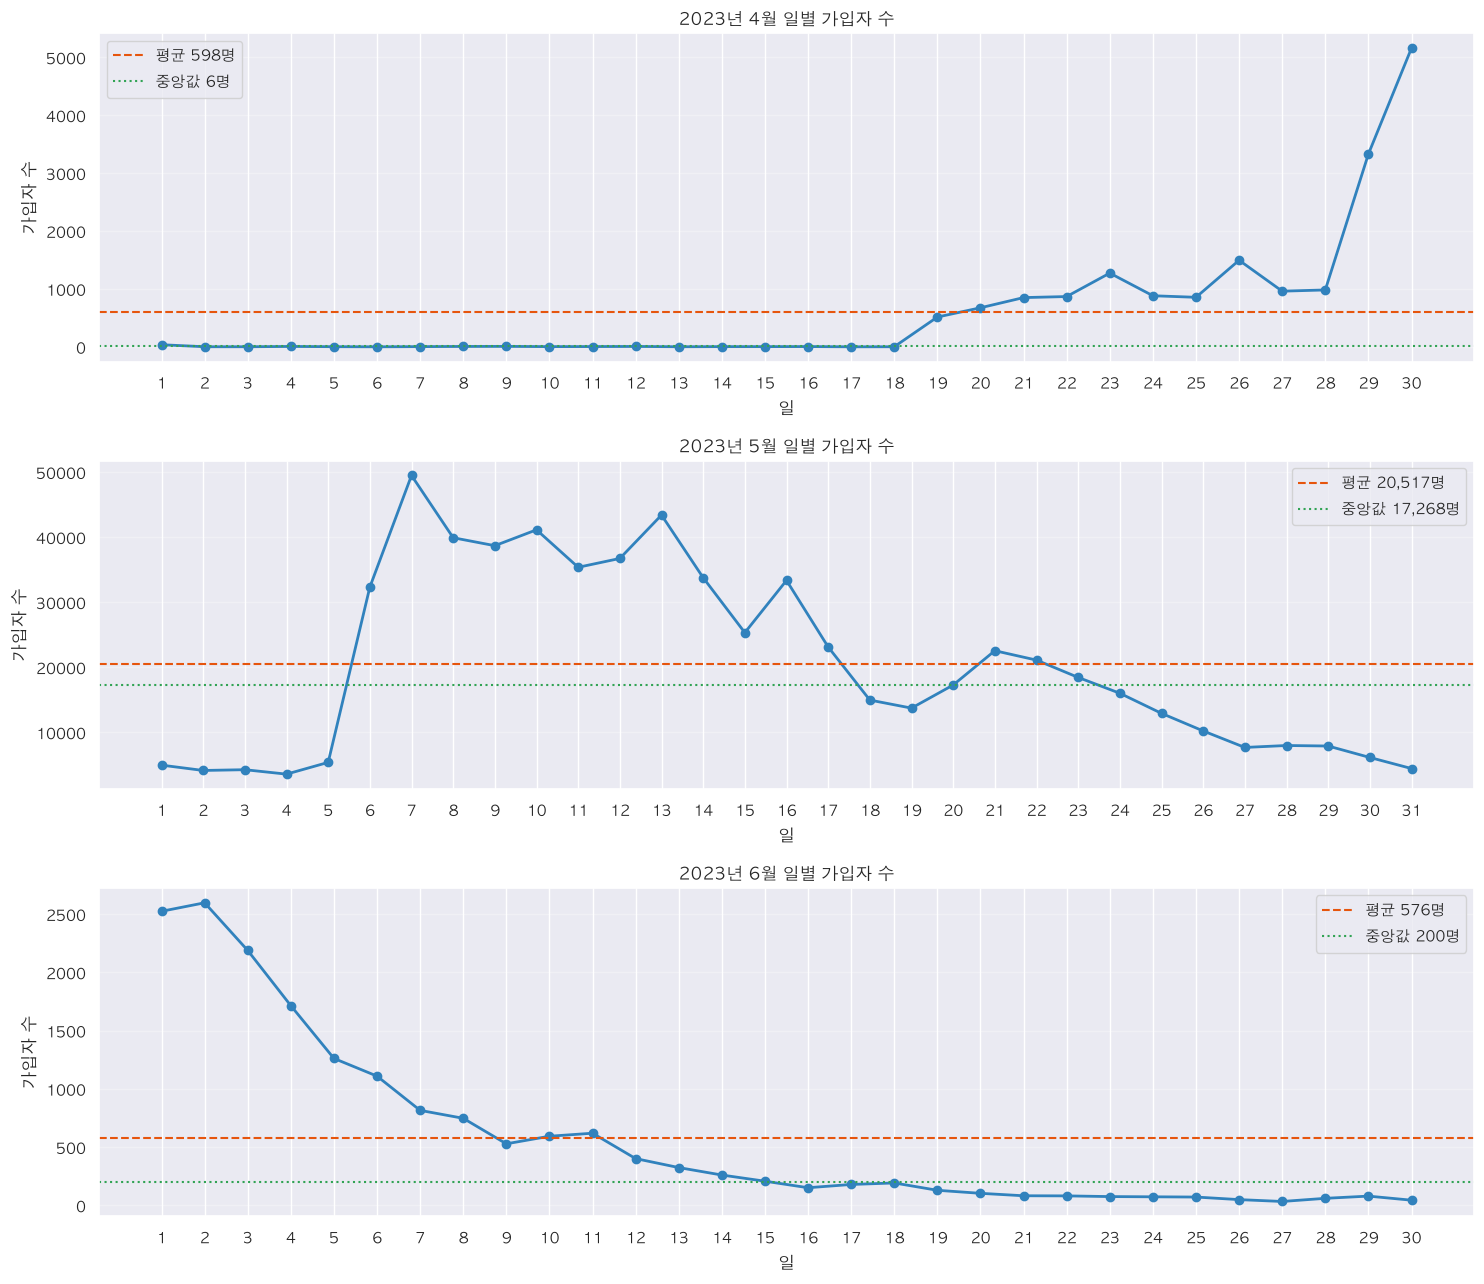

In [107]:
months = [
    ('2023-04', '2023년 4월'),
    ('2023-05', '2023년 5월'),
    ('2023-06', '2023년 6월'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 13))

for ax, (month, title) in zip(axes, months):
    monthly_data = daily_signup_summary[
        daily_signup_summary['가입월'].eq(month)
    ]

    ax.plot(
        monthly_data['가입일'].dt.day,
        monthly_data['가입자 수'],
        marker='o',
        linewidth=2,
        color='#3182bd',
    )

    ax.axhline(
        monthly_data['가입자 수'].mean(),
        color='#e6550d',
        linestyle='--',
        label=f'평균 {monthly_data["가입자 수"].mean():,.0f}명',
    )

    ax.axhline(
        monthly_data['가입자 수'].median(),
        color='#31a354',
        linestyle=':',
        label=f'중앙값 {monthly_data["가입자 수"].median():,.0f}명',
    )

    ax.set_title(f'{title} 일별 가입자 수')
    ax.set_xlabel('일')
    ax.set_ylabel('가입자 수')
    ax.set_xticks(monthly_data['가입일'].dt.day)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()

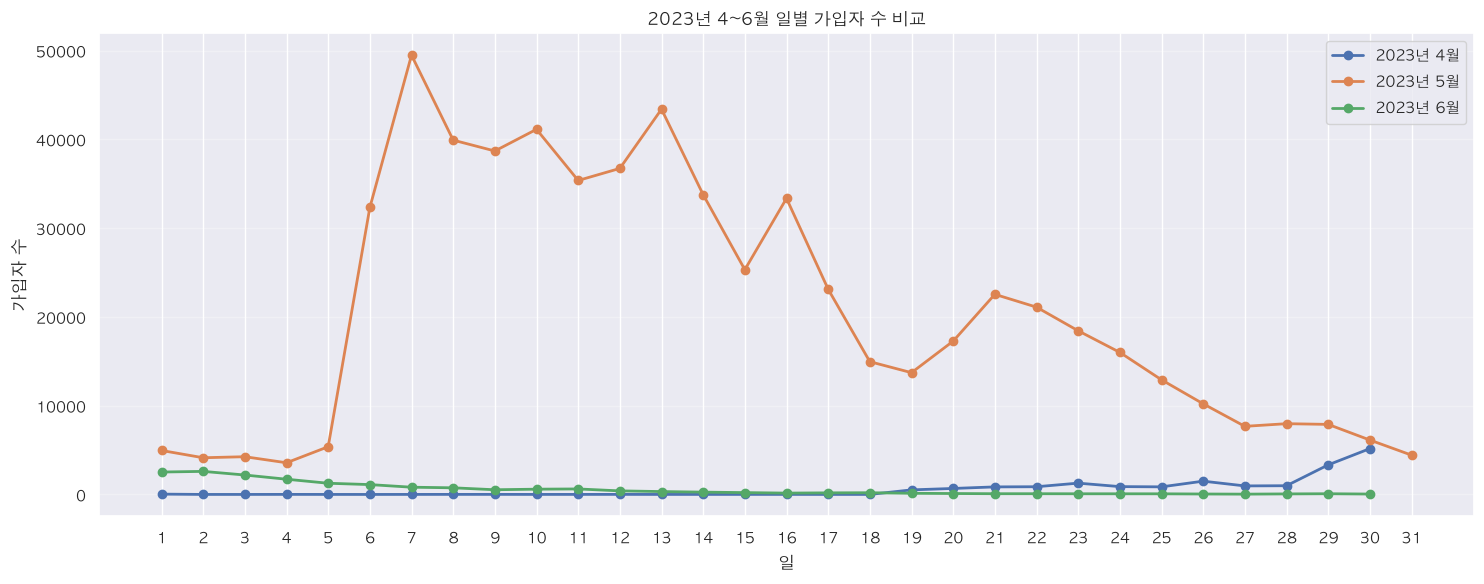

In [108]:
fig, ax = plt.subplots(figsize=(15, 6))

for month, title in months:
    monthly_data = daily_signup_summary[
        daily_signup_summary['가입월'].eq(month)
    ]

    ax.plot(
        monthly_data['가입일'].dt.day,
        monthly_data['가입자 수'],
        marker='o',
        linewidth=2,
        label=title,
    )

ax.set_title('2023년 4~6월 일별 가입자 수 비교')
ax.set_xlabel('일')
ax.set_ylabel('가입자 수')
ax.set_xticks(range(1, 32))
ax.grid(axis='y', alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

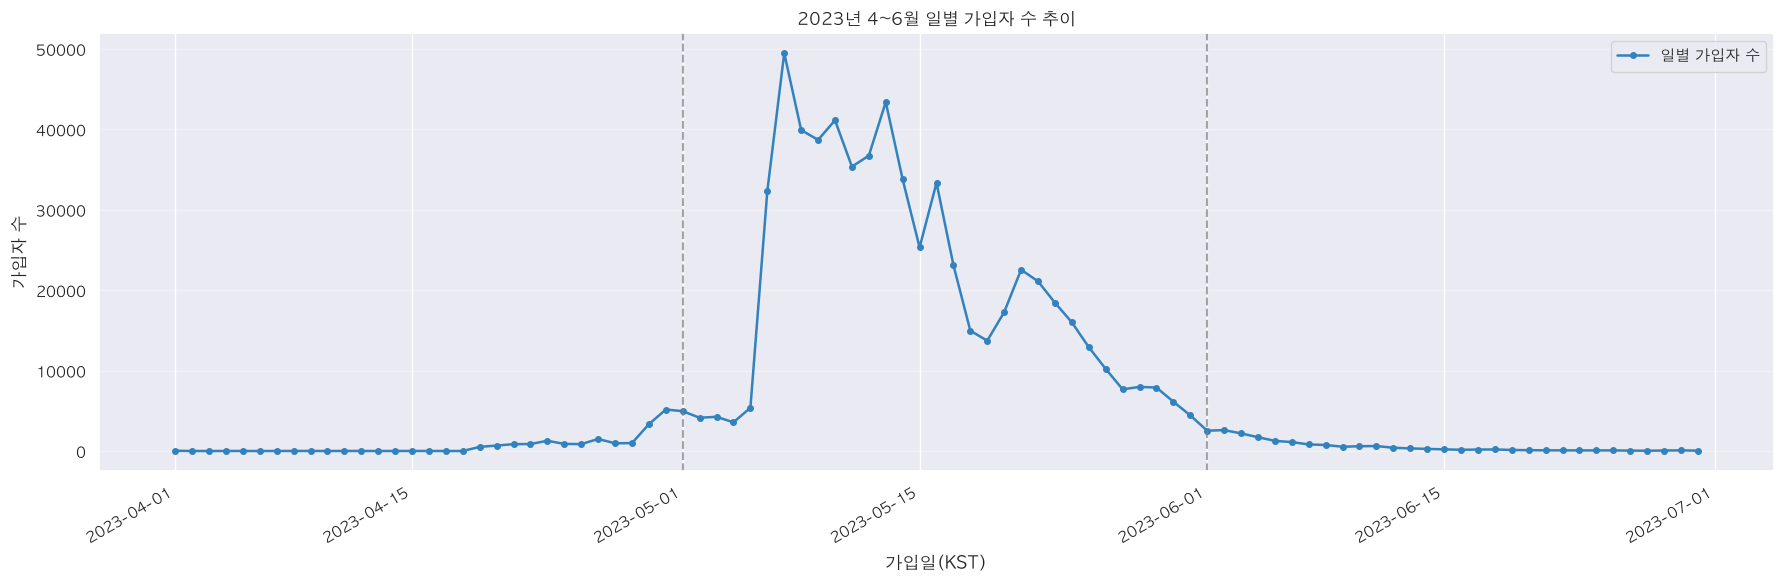

In [109]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    daily_signup_summary['가입일'],
    daily_signup_summary['가입자 수'],
    marker='o',
    markersize=4,
    linewidth=1.8,
    color='#3182bd',
    label='일별 가입자 수',
)

# 월 경계 표시
for month_start in [
    pd.Timestamp('2023-05-01'),
    pd.Timestamp('2023-06-01'),
]:
    ax.axvline(
        month_start,
        color='gray',
        linestyle='--',
        alpha=0.7,
    )

ax.set_title('2023년 4~6월 일별 가입자 수 추이')
ax.set_xlabel('가입일(KST)')
ax.set_ylabel('가입자 수')
ax.grid(axis='y', alpha=0.3)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [110]:
daily_signup_summary['7일 이동평균'] = (
    daily_signup_summary['가입자 수']
    .rolling(window=7, min_periods=1)
    .mean()
)

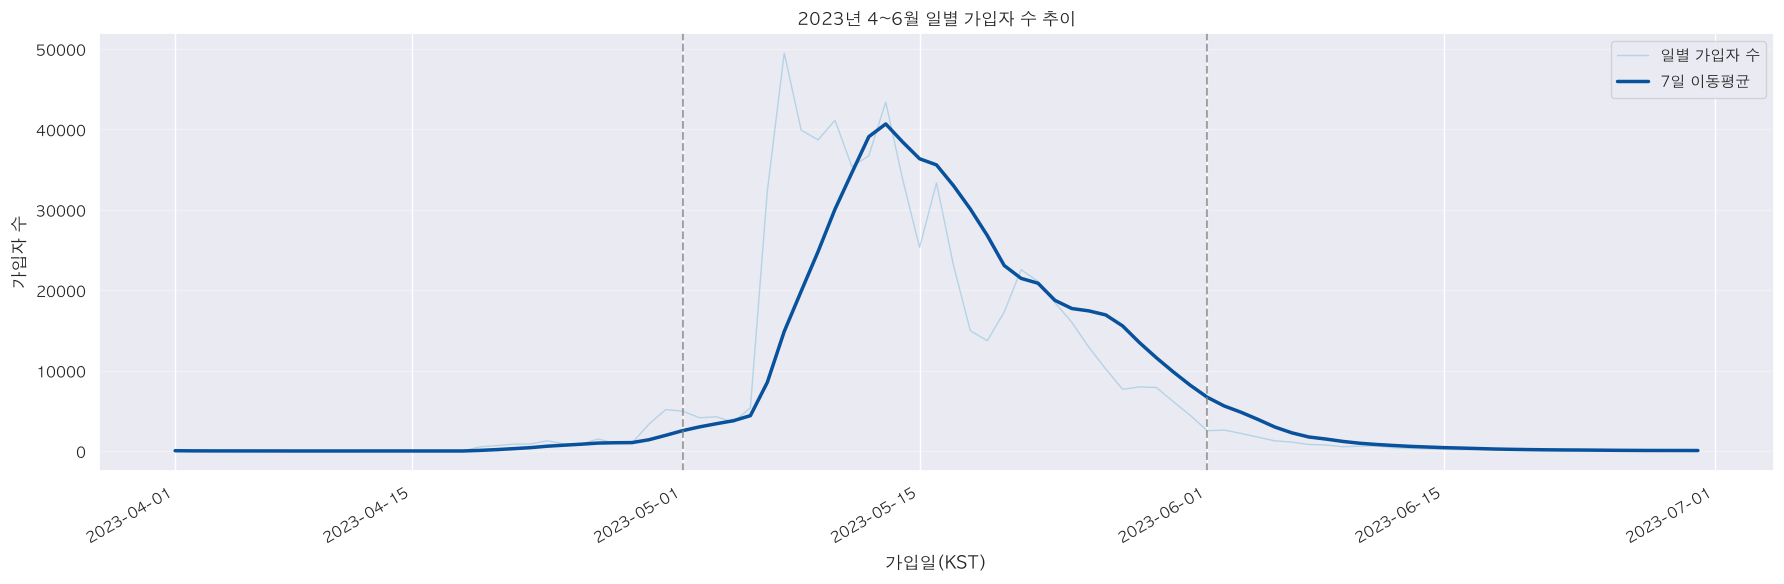

In [111]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    daily_signup_summary['가입일'],
    daily_signup_summary['가입자 수'],
    color='#9ecae1',
    linewidth=1,
    alpha=0.7,
    label='일별 가입자 수',
)

ax.plot(
    daily_signup_summary['가입일'],
    daily_signup_summary['7일 이동평균'],
    color='#08519c',
    linewidth=2.5,
    label='7일 이동평균',
)

for month_start in [
    pd.Timestamp('2023-05-01'),
    pd.Timestamp('2023-06-01'),
]:
    ax.axvline(
        month_start,
        color='gray',
        linestyle='--',
        alpha=0.7,
    )

ax.set_title('2023년 4~6월 일별 가입자 수 추이')
ax.set_xlabel('가입일(KST)')
ax.set_ylabel('가입자 수')
ax.grid(axis='y', alpha=0.3)
ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()